# Hypercall: what the headline numbers are made of

This notebook downloads its own inputs into `snapshots/nb-<UTC>/` and computes
every figure below from that directory. Nothing is carried in from an earlier
run, no API key is used anywhere, and no explorer index: every HyperEVM number
is read from a node. The write-up it backs: <link>

**Definitions.** For a trade with price `p`, size `q`, strike `K`:

- `premium = p * q`, the USDC transferred for the contract.
- `notional = K * q`, our definition, stated because the venue publishes none.
- open interest per instrument: positions are rebuilt from the tape
  (`taker Buy: +q` to the taker, `-q` to the maker), `OI = sum of positive
  positions`, `OI notional = K * OI`.

**Cut.** `CUTOFF` (env `HC_CUTOFF`), an ISO-8601 instant; trades with
`created_at >= CUTOFF` are dropped. It defaults to the published cut; an
empty `HC_CUTOFF` means the moment of the run.

**Sources.** `api.hypercall.xyz` (tape, portfolios, open interest, fee
schedule), `api.hyperliquid.xyz/info` (HyperCore ledger and state),
`rpc.purroofgroup.com` (HyperEVM archive node: `eth_getLogs`, `eth_getCode`,
`eth_call`, `eth_getTransactionCount`, with `rpc.hypurrscan.io` as fallback),
`rpc.hyperliquid.xyz/evm` (node state for the named addresses), `api.llama.fi`
(TVL), `earn.hypercall.xyz` (Ink Earn), `docs.hypercall.xyz` (rewards rules).

In [1]:
import os, sys, json, math, time, threading, collections, datetime as dt
from decimal import Decimal as D
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
CHARTS = HERE / "charts"; CHARTS.mkdir(exist_ok=True)

def tbl(df, fmt=None, index="auto"):
    """A table whose columns are formatted into strings.

    Stands in for the pandas Styler, which pulls in jinja2; the point of this
    notebook is that it runs on pandas and matplotlib and nothing else.
    index="auto" hides an unnamed numeric index and keeps a meaningful one.
    """
    d = df.copy()
    for c, f in (fmt or {}).items():
        if c in d.columns:
            d[c] = [f.format(v) if pd.notna(v) else "" for v in d[c]]
    if index == "auto":
        index = bool(d.index.name) or d.index.dtype == object
    if not index:
        d.index = [""] * len(d)
    return d


CUTOFF = os.environ.get("HC_CUTOFF", "2026-09-24T00:00:00Z")

PILOT_START, PILOT_END = "2026-09-16T18:00:00", "2026-09-23T18:00:00"
PILOT_DAILY_USD = D(1000)

DUST = D("0.01")

INK, HL, WARN = "#1b3a5c", "#3f8f7a", "#b4461f"
MUTE, RULE, TEXT = "#8a94a0", "#e3e6ea", "#3a3f45"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.facecolor": "white", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": MUTE, "axes.labelcolor": TEXT, "axes.labelsize": 8.5,
    "xtick.color": MUTE, "ytick.color": MUTE, "xtick.labelcolor": TEXT,
    "ytick.labelcolor": TEXT, "ytick.left": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": RULE, "grid.linewidth": .8,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 8,
})
def short_usd(x, p=None):
    a = abs(x)
    if a >= 1e9: return f"${x/1e9:.0f}B"
    if a >= 1e6: return f"${x/1e6:.0f}M"
    if a >= 1e3: return f"${x/1e3:.0f}k"
    return f"${x:,.0f}"
pd.set_option("display.width", 160, "display.max_columns", 40)
print("python", sys.version.split()[0], "| pandas", pd.__version__,
      "| matplotlib", matplotlib.__version__)
print("cut:", CUTOFF or "(the moment of this run)")

Matplotlib is building the font cache; this may take a moment.


python 3.14.7 | pandas 3.0.5 | matplotlib 3.11.1
cut: 2026-09-24T00:00:00Z


## 1. Download

The tape is paged by cursor:
`GET /trades?limit=1000&after_trade_id={max trade_id of the previous page}`,
from 0 until a page returns an empty `data` array; the response is wrapped as
`{success, data[], pagination{}}`. Every Hypercall endpoint answers 403
without a `User-Agent` header. Pages are written verbatim to
`tape-pages/page-NNNN.json`, deduplicated by `trade_id`, sorted, and written as
`trades.json`.

Also fetched: `/markets`, `/instruments`, the DefiLlama series, two Ink Earn
endpoints and the rewards rules page.

Every function that touches the network is defined in the cells below rather
than imported, so the notebook is the whole method.

In [2]:
import urllib.error, urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed

UA = "option-research/hypercall-watch (contact: repo owner)"
TAPE      = "https://api.hypercall.xyz/trades?limit=1000&after_trade_id={after}"
PORTFOLIO = "https://api.hypercall.xyz/portfolio?wallet={wallet}"

EXTRA = [
    ("markets.json",              "https://api.hypercall.xyz/markets"),
    ("instruments.json",          "https://api.hypercall.xyz/instruments"),
    ("defillama-hypercall.json",  "https://api.llama.fi/protocol/hypercall"),
    ("earn-bootstrap.json",       "https://earn.hypercall.xyz/api/bootstrap"),
    ("earn-reward-campaign.json", "https://earn.hypercall.xyz/api/reward-campaign"),
    ("docs-trading-rewards.html", "https://docs.hypercall.xyz/docs/trading-rewards/"),
]


def utcnow():
    return dt.datetime.now(dt.timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")


def get(url, tries=4):
    """(bytes, fetched_at, status). A failure is returned, not swallowed."""
    last = None
    for i in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": UA, "Accept": "*/*"})
            with urllib.request.urlopen(req, timeout=45) as r:
                return r.read(), utcnow(), r.status
        except urllib.error.HTTPError as e:
            last = f"HTTP {e.code}"
            if e.code in (400, 401, 403, 404):
                return None, utcnow(), e.code
        except Exception as e:
            last = f"{type(e).__name__}: {e}"
        if i < tries - 1:
            time.sleep(2 ** i)
    return None, utcnow(), last


def pmap(fn, items, workers=8, label=None, every=100):
    """[fn(x) for x in items] on `workers` threads, in the order of `items`.

    Every slow cell below is many independent requests, and waiting on them one
    at a time is most of the run. The first failure is raised with the item it
    failed on, so a broken run names the address rather than just stopping.
    """
    items = list(items)
    out = [None] * len(items)
    with ThreadPoolExecutor(workers) as ex:
        futs = {ex.submit(fn, x): i for i, x in enumerate(items)}
        for n, f in enumerate(as_completed(futs), 1):
            i = futs[f]
            try:
                out[i] = f.result()
            except Exception as e:
                for g in futs:
                    g.cancel()
                raise RuntimeError(f"{label or fn.__name__}: {items[i]!r}: {e}") from e
            if label and (n % every == 0 or n == len(items)):
                print(f"  {label}: {n}/{len(items)}")
    return out


def write(path, blob):
    """Write bytes as they arrived and return the length."""
    with open(path, "wb") as f:
        f.write(blob)
    return len(blob)


def collect_tape(out, pages_dir):
    """Walk the tape by cursor to an empty page. Pages are kept as they arrived.

    A page that fails to parse raises rather than ending the walk quietly: a
    truncated tape that looks complete is the one failure this notebook cannot
    afford, since every total below is taken over whatever this returns.
    """
    os.makedirs(pages_dir, exist_ok=True)
    trades, after, page, pages, seen = [], 0, 0, [], set()
    while True:
        url = TAPE.format(after=after)
        blob, at, status = get(url)
        if blob is None:
            raise RuntimeError(f"page {page} failed: {status}  {url}")
        n = write(os.path.join(pages_dir, f"page-{page:04d}.json"), blob)
        body = json.loads(blob)
        batch = body["data"] if isinstance(body, dict) else body
        pages.append({"page": page, "url": url, "fetched_at": at,
                      "bytes": n, "records": len(batch),
                      "pagination": body.get("pagination") if isinstance(body, dict) else None})
        if not batch:
            print(f"  page {page}: empty - end of the tape")
            break
        for t in batch:
            if t["trade_id"] not in seen:
                seen.add(t["trade_id"]); trades.append(t)
        after = max(t["trade_id"] for t in batch)
        print(f"  page {page}: {len(batch)} records, cursor -> {after}")
        page += 1
        if page > 500:
            raise RuntimeError("stopped at 500 pages: the cursor is not advancing")
        time.sleep(0.3)

    trades.sort(key=lambda t: t["trade_id"])
    blob = json.dumps(trades, indent=1).encode()
    n = write(os.path.join(out, "trades.json"), blob)
    return {"records": len(trades), "bytes": n,
            "first_trade_id": trades[0]["trade_id"] if trades else None,
            "last_trade_id": trades[-1]["trade_id"] if trades else None,
            "last_created_at": trades[-1]["created_at"] if trades else None,
            "pages": pages}

In [3]:
stamp = dt.datetime.now(dt.timezone.utc).strftime("%Y-%m-%dT%H%MZ")
SNAP = HERE / "snapshots" / f"nb-{stamp}"
SNAP.mkdir(parents=True, exist_ok=True)

REUSE = Path(os.environ["HC_REUSE"]) if os.environ.get("HC_REUSE") else None
if REUSE:
    assert REUSE.is_dir(), REUSE
    print(f"reusing Relay requests and block times from {REUSE.name}")

tape = collect_tape(str(SNAP), str(SNAP / "tape-pages"))
print(f"\ntape: {tape['records']} records, id {tape['first_trade_id']}..{tape['last_trade_id']}")
print(f"last trade: {tape['last_created_at']}")

reusing Relay requests and block times from nb-2026-09-23T2324Z


  page 0: 1000 records, cursor -> 3944


  page 1: 1000 records, cursor -> 6305


  page 2: 1000 records, cursor -> 7406


  page 3: 1000 records, cursor -> 8935


...

  page 11: 1000 records, cursor -> 38886


  page 12: 1000 records, cursor -> 39886


  page 13: 1000 records, cursor -> 40886


  page 14: 248 records, cursor -> 41134


  page 15: empty - end of the tape

tape: 14248 records, id 21..41134
last trade: 2026-09-24T10:21:03.459792Z


In [4]:
extras = {}
for name, url in EXTRA:
    blob, at, status = get(url)
    if blob is None:
        extras[name] = {"url": url, "fetched_at": at, "error": str(status)}
        print(f"{name:<28} FAILED {status}")
        continue
    n = write(str(SNAP / name), blob)
    extras[name] = {"url": url, "fetched_at": at, "bytes": n}
    print(f"{name:<28} {n:>8} bytes  {at}")

markets.json                  4625168 bytes  2026-09-24T12:01:21Z


instruments.json               511130 bytes  2026-09-24T12:01:22Z


defillama-hypercall.json        26113 bytes  2026-09-24T12:01:22Z


earn-bootstrap.json             85496 bytes  2026-09-24T12:01:28Z


earn-reward-campaign.json         698 bytes  2026-09-24T12:01:29Z


docs-trading-rewards.html       29708 bytes  2026-09-24T12:01:30Z


## 2. The tape as a table

Fields per record: `trade_id, symbol, price, size, maker_address,
taker_address, maker_fee, taker_fee, taker_side, timestamp, created_at`.

Symbols are parsed by `^([A-Z0-9]+)-(\d{8})-([\d.]+)-([CP])$` into underlying,
expiry, strike and right; a symbol that fails the regex raises rather than
being dropped silently. `price`, `size`, `strike` are carried as `Decimal`, so
`premium` and `notional` are exact and no float rounding enters the totals.

In [5]:
import re
SYMBOL_RE = re.compile(r"^([A-Z0-9]+)-(\d{8})-([\d.]+)-([CP])$")

raw = json.loads((SNAP / "trades.json").read_text())
rows, bad = [], []
for t in raw:
    if CUTOFF and t["created_at"] >= CUTOFF.rstrip("Z"):
        continue
    m = SYMBOL_RE.match(t["symbol"])
    if not m:
        bad.append(t["symbol"]); continue
    und, exp, strike, cp = m.groups()
    price, size = D(t["price"]), D(t["size"])
    rows.append({
        "trade_id": t["trade_id"], "symbol": t["symbol"],
        "underlying": und, "expiry": dt.date(int(exp[:4]), int(exp[4:6]), int(exp[6:])),
        "strike": strike, "cp": cp,
        "price": price, "size": size,
        "premium": price * size, "notional": D(strike) * size,
        "maker": t["maker_address"], "taker": t["taker_address"],
        "side": t["taker_side"],
        "maker_fee": D(t["maker_fee"]), "taker_fee": D(t["taker_fee"]),
        "ts": dt.datetime.fromisoformat(t["created_at"].replace("Z", "+00:00")),
        "tms": int(t["timestamp"]), "created_at": t["created_at"],
    })
df = pd.DataFrame(rows).sort_values("trade_id").reset_index(drop=True)
df["strike"] = df["strike"].map(D)
end = df.ts.max()
assert not bad, f"symbols that did not parse: {set(bad)}"
print(f"trades after the cut: {len(df)}   dropped by the cut: {len(raw) - len(df)}")

print(f"trade_id {df.trade_id.min()} to {df.trade_id.max()}, "
      f"{len(set(df.maker.str.lower()) | set(df.taker.str.lower()))} addresses, "
      f"{df.symbol.nunique()} instruments")
print(f"span: {df.ts.min()}  ..  {df.ts.max()}")
display(df.head(3)[["trade_id","symbol","price","size","side","maker","taker","ts"]])

trades after the cut: 14205   dropped by the cut: 43
trade_id 21 to 41091, 509 addresses, 1905 instruments
span: 2026-06-01 19:55:30.540837+00:00  ..  2026-09-23 23:53:52.115623+00:00


,trade_id,symbol,price,size,side,maker,taker,ts
0,21,SPCX-20260602-170-C,30.47,0.038120797182,Buy,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,0x3eda819ad86d39c9c12e76144f859d02adb7237e,2026-06-01 19:55:30.540837+00:00
1,22,SPCX-20260602-165-C,35.13,0.038120797182,Buy,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,0x3eda819ad86d39c9c12e76144f859d02adb7237e,2026-06-01 19:55:30.540837+00:00
2,23,SPCX-20260603-170-C,31.000500000000002,0.08058537214324855,Buy,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,0x3eda819ad86d39c9c12e76144f859d02adb7237e,2026-06-01 19:56:35.233608+00:00


## 3. The tape in total

`sum(premium)`, `sum(notional)`, their ratio, the distinct address and symbol
counts, and two controls: trades with `maker_fee != 0 or taker_fee != 0`, and
trades with `maker_address == taker_address`.

In [6]:
def usd(x): return f"${float(x):,.2f}"

addrs = set(df.maker) | set(df.taker)
prem, notl = df.premium.sum(), df.notional.sum()
fees = df[(df.maker_fee != 0) | (df.taker_fee != 0)]
self_trades = df[df.maker == df.taker]

TOTALS = {
    "trades": len(df),
    "instruments": df.symbol.nunique(),
    "addresses (maker + taker)": len(addrs),
    "premium": usd(prem),
    "notional (strike x size)": usd(notl),
    "notional / premium": f"{float(notl/prem):,.1f}x",
    "trades charged a non-zero fee": len(fees),
    "trades with the same address on both sides": len(self_trades),
}
display(pd.Series(TOTALS).to_frame("value"))

,value
trades,14205
instruments,1905
addresses (maker + taker),509
premium,"$853,321.60"
notional (strike x size),"$454,597,510.21"
notional / premium,532.7x
trades charged a non-zero fee,0
trades with the same address on both sides,0


## 4. The book the tape rebuilds

Positions are rebuilt from the tape: a taker Buy adds the size to the taker
and subtracts it from the maker. `OI` per instrument is the sum of positive positions; `OI notional = K * OI`.
Live means `expiry > date(cut)`. Per instrument, the number of distinct
addresses holding a positive position is counted separately.

In [7]:
pos = collections.defaultdict(lambda: collections.defaultdict(D))
for r in df.itertuples():
    q = r.size if r.side == "Buy" else -r.size
    pos[r.symbol][r.taker.lower()] += q
    pos[r.symbol][r.maker.lower()] -= q

meta = df.drop_duplicates("symbol").set_index("symbol")[["expiry", "strike"]]
oi, longs = collections.defaultdict(D), collections.defaultdict(list)
for s, d in pos.items():
    for a, v in d.items():
        if v > 0:
            oi[s] += v; longs[s].append(a)

today = end.date()
live = pd.DataFrame([{"symbol": s, "oi": float(v),
                      "expiry": meta.expiry[s], "strike": float(meta.strike[s]),
                      "oi_notional": float(v * meta.strike[s]),
                      "long addresses": len(longs[s])}
                     for s, v in oi.items() if meta.expiry[s] > today])
live = live.sort_values("oi_notional", ascending=False)
nearest = live.expiry.min()
print(f"live instruments: {len(live)}")
print(f"live OI (strike x OI): ${live.oi_notional.sum():,.0f} "
      f"= {live.oi_notional.sum()/float(notl)*100:.1f}% of all notional on the tape")
print(f"nearest expiry {nearest}: ${live[live.expiry==nearest].oi_notional.sum():,.0f} "
      f"= {live[live.expiry==nearest].oi_notional.sum()/live.oi_notional.sum()*100:.1f}% of live OI")
print(f"left standing after it: ${live[live.expiry>nearest].oi_notional.sum():,.0f}")
print(f"\ninstruments with exactly one address on the long side: "
      f"{(live['long addresses']==1).sum()} of {len(live)}")
display(live.head(12).pipe(tbl, {"oi": "{:,.4f}", "strike": "{:,.0f}",
                                    "oi_notional": "${:,.0f}"}))

live instruments: 184
live OI (strike x OI): $154,130,604 = 33.9% of all notional on the tape
nearest expiry 2026-09-24: $152,347,895 = 98.8% of live OI
left standing after it: $1,782,709

instruments with exactly one address on the long side: 171 of 184


,symbol,oi,expiry,strike,oi_notional,long addresses
,SP500-20260924-7630-P,"10,000.0000",2026-09-24,"7,630","$76,300,000",1
,SP500-20260924-7600-P,"10,000.0000",2026-09-24,"7,600","$76,000,000",1
,ETH-20261002-3050-C,106.6442,2026-10-02,"3,050","$325,265",1
,SP500-20261002-7750-C,26.1408,2026-10-02,"7,750","$202,591",1
,NVDA-20261030-310-C,565.8668,2026-10-30,310,"$175,419",1
,SP500-20261002-7690-C,13.6780,2026-10-02,"7,690","$105,184",1
,ETH-20261016-3350-C,22.9390,2026-10-16,"3,350","$76,846",1
,ETH-20261002-2550-C,28.0371,2026-10-02,"2,550","$71,495",1
,ETH-20261016-2750-C,22.9390,2026-10-16,"2,750","$63,082",1
,ETH-20261030-4200-C,11.0000,2026-10-30,"4,200","$46,200",2


### How much of it there is

A trade moves contracts; it does not by itself create a position. For one
instrument, the net position of an address is the contracts it bought minus the
contracts it sold, and open interest is the sum of the positive net positions.
It equals the sum of the negative ones because the book is zero-sum, so no
convention has to be chosen and no threshold has to be set.

Three quantities, and the distance between them is the finding: contracts that
changed hands, open interest the tape ever created, and open interest still
open at the cut.

In [8]:
sym_exp  = dict(zip(df.symbol, df.expiry))
cut_date = dt.date.fromisoformat(CUTOFF[:10]) if CUTOFF else end.date()
traded   = df["size"].sum()

oi_all    = sum(v for s in pos for v in pos[s].values() if v > 0)
oi_dust   = sum(v for s in pos for v in pos[s].values() if v > DUST)
small     = [v for s in pos for v in pos[s].values() if D(0) < v <= DUST]
open_syms = sorted(s for s in pos if sym_exp[s] > cut_date)
oi_open   = sum(v for s in open_syms for v in pos[s].values() if v > 0)

print(f"contracts that changed hands                     {float(traded):>14,.2f}")
print(f"open interest the tape implies, all {len(pos):,} instruments {float(oi_all):>12,.2f}")
print(f"open interest still open past {cut_date}            {float(oi_open):>14,.2f}")
print()
print(f"traded / ever created  {float(traded / oi_all):>6,.2f}x")
print(f"traded / still open    {float(traded / oi_open):>6,.2f}x")
print()
print(f"the same total under the {DUST}-contract dust floor used by the flow")
print(f"bound in chapter 6: {float(oi_dust):,.4f}, a difference of {float(oi_all - oi_dust):,.4f}")
print(f"contracts carried by {len(small)} positions in (0, {DUST}]. The flow bound")
print("drops them as rounding; this section does not, and says which is which.")

contracts that changed hands                         176,515.88
open interest the tape implies, all 1,905 instruments   124,844.22
open interest still open past 2026-09-24                  2,030.44

traded / ever created    1.41x
traded / still open     86.93x

the same total under the 0.01-contract dust floor used by the flow
bound in chapter 6: 124,843.8047, a difference of 0.4123
contracts carried by 170 positions in (0, 0.01]. The flow bound
drops them as rounding; this section does not, and says which is which.


### The venue's own number

`GET /markets` returns `open_interest` per instrument. The tape is a record of
trades and the field is a record of positions, so if the tape is complete the
one must reproduce the other. This is the check that can fail.

In [9]:
mkt = json.loads((SNAP / "markets.json").read_text())["data"]
venue_oi = {i["id"]: D(str(i["open_interest"]))
            for g in mkt for i in g.get("instruments", [])
            if i.get("open_interest") is not None}
shared = [s for s in open_syms if s in venue_oi]
tape_oi = {s: sum(v for v in pos[s].values() if v > 0) for s in shared}
t_tot, v_tot = sum(tape_oi.values()), sum(venue_oi[s] for s in shared)

print(f"instruments open past the cut on the tape   {len(open_syms):>6}")
print(f"  of them carried by /markets               {len(shared):>6}")
print(f"open interest over those, from the tape     {float(t_tot):>12,.2f} contracts")
print(f"open interest over those, from the venue    {float(v_tot):>12,.2f} contracts")
print(f"ratio venue / tape                          {float(v_tot / t_tot):>12,.4f}")

XC = pd.DataFrame([{"instrument": s, "tape": float(tape_oi[s]),
                    "venue": float(venue_oi[s]),
                    "difference": float(tape_oi[s] - venue_oi[s])}
                   for s in shared])
XC["abs"] = XC["difference"].abs()
print(f"instruments agreeing exactly: {int((XC['abs'] == 0).sum())} of {len(XC)}")
print(f"total absolute divergence: {XC['abs'].sum():,.2f} contracts "
      f"= {XC['abs'].sum() / float(t_tot) * 100:.2f}% of the tape's total")
display(XC.sort_values("abs", ascending=False).head(8)
          .drop(columns=["abs"])
          .pipe(tbl, {"tape": "{:,.2f}", "venue": "{:,.2f}",
                      "difference": "{:+,.2f}"}, index=False))

instruments open past the cut on the tape      256
  of them carried by /markets                  256
open interest over those, from the tape         2,030.44 contracts
open interest over those, from the venue        2,036.69 contracts
ratio venue / tape                                1.0031
instruments agreeing exactly: 249 of 256
total absolute divergence: 7.81 contracts = 0.38% of the tape's total


,instrument,tape,venue,difference
,MU-20260928-1000-P,10.00,15.00,-5.00
,NVDA-20261030-220-C,1.69,3.72,-2.03
,ETH-20261030-3600-C,6.78,6.00,+0.78
,ETH-20261030-4100-P,0.00,0.00,+0.00
,BTC-20261002-83000-C,0.00,0.00,+0.00
,NVDA-20260925-210-C,11.88,11.88,-0.00
,SP500-20261030-7680-C,3.00,3.00,+0.00
,NVDA-20261002-190-C,0.00,0.00,+0.00


## 5. Who is on the other side

### Do these addresses exist on either chain

The watched set: the seven addresses with the most premium traded, and the
venue's custody account. Per address, read-only:

- `rpc.hyperliquid.xyz/evm`: `eth_getBalance`, `eth_getTransactionCount`,
  `eth_getCode`.
- `api.hyperliquid.xyz/info`: `userNonFundingLedgerUpdates` (event count),
  `clearinghouseState` (`marginSummary.accountValue`),
  `spotClearinghouseState` (balances).

`no_chain_trace` is the conjunction: zero balance, nonce 0, no code, zero
ledger events, no spot balances.

Limit: `userNonFundingLedgerUpdates` returns at most 2000 events, so a count at
that ceiling is a floor, not a total.

In [10]:
EVM  = "https://rpc.hyperliquid.xyz/evm"
INFO = "https://api.hyperliquid.xyz/info"
JSON_UA = {"User-Agent": UA, "Content-Type": "application/json"}

prem_by_addr = collections.defaultdict(D)
for m_, t_, v_ in zip(df.maker.str.lower(), df.taker.str.lower(), df.premium):
    prem_by_addr[m_] += v_; prem_by_addr[t_] += v_
ADDR = {a[:10]: a for a in sorted(prem_by_addr, key=lambda a: -prem_by_addr[a])[:7]}
ADDR["venue custody"] = "0xe6b7faa216cabb2b38b392f577c9c826378b2240"


def post_json(url, body, timeout=45, tries=6):
    """One POST of JSON. A dropped connection or a 5xx is retried, a 4xx is not.

    Everything below sits on this: the nonce read, the HyperCore ledger walk,
    the node probes. Without the retry one timeout an hour into a run ends it.
    """
    data = json.dumps(body).encode()
    for i in range(tries):
        try:
            req = urllib.request.Request(url, data=data, headers=JSON_UA)
            with urllib.request.urlopen(req, timeout=timeout) as r:
                return json.loads(r.read())
        except urllib.error.HTTPError as e:
            if (e.code < 500 and e.code != 429) or i == tries - 1:
                raise RuntimeError(f"POST {url}: HTTP {e.code}") from e
            if e.code == 429:
                time.sleep(5 * (i + 1)); continue
        except (urllib.error.URLError, TimeoutError, json.JSONDecodeError) as e:
            if i == tries - 1:
                raise RuntimeError(f"POST {url} failed after {tries} tries: "
                                   f"{type(e).__name__}: {e}") from e
        time.sleep(2 ** i)


def hl_post(body):
    """One request to the HyperCore info endpoint."""
    return post_json(INFO, body)


def node_rpc(method, params):
    """One JSON-RPC call to the public HyperEVM node.

    An error from the node is raised rather than returned. `.get("result")` on
    an error response is None, and None reads downstream as a zero balance and
    a zero nonce, so a failed lookup would arrive as a published fact.
    """
    for i in range(6):
        r = post_json(EVM, {"jsonrpc": "2.0", "id": 1,
                            "method": method, "params": params})
        if r.get("error", {}).get("code") != -32005:
            break
        time.sleep(2 ** i)
    if "error" in r:
        raise RuntimeError(f"{method} on {EVM}: {json.dumps(r['error'])}")
    return r.get("result")


def chain_probe(addrs=None, verbose=True):
    """Node state and HyperCore state per address. The network is only read."""
    addrs = addrs or ADDR

    def one(a):
        rec = {"address": a}
        rec["balance_wei"] = int(node_rpc("eth_getBalance", [a, "latest"]) or "0x0", 16)
        rec["nonce"] = int(node_rpc("eth_getTransactionCount", [a, "latest"]) or "0x0", 16)
        rec["has_code"] = (node_rpc("eth_getCode", [a, "latest"]) or "0x") != "0x"
        led = hl_post({"type": "userNonFundingLedgerUpdates", "user": a, "startTime": 0})
        if not isinstance(led, list):
            raise RuntimeError(f"ledger for {a}: {led}")
        rec["core_ledger_events"] = len(led)
        rec["core_account_value"] = (hl_post({"type": "clearinghouseState", "user": a})
                                     .get("marginSummary", {}).get("accountValue"))
        rec["spot_balances"] = hl_post({"type": "spotClearinghouseState",
                                        "user": a}).get("balances", [])
        rec["no_chain_trace"] = (rec["balance_wei"] == 0 and rec["nonce"] == 0
                                 and not rec["has_code"]
                                 and rec["core_ledger_events"] == 0
                                 and not rec["spot_balances"])
        return rec

    return dict(zip(addrs, pmap(one, addrs.values(), workers=4)))


NONCE_NODE, NONCE_BATCH = "https://rpc.purroofgroup.com", 200


def block_at(ts, call=None):
    """The last block whose timestamp is at or before `ts`.

    Defined here rather than with the other chain helpers because the nonce
    sweep needs it: a nonce read at "latest" answers for the moment the
    notebook runs, and an address that signs its first transaction tomorrow
    would quietly leave the never-signed set. Read at the cut block instead,
    the set is a function of the cut alone and two runs agree.
    """
    call = call or (lambda m, pr: post_json(
        NONCE_NODE, {"jsonrpc": "2.0", "id": 1, "method": m, "params": pr}).get("result"))
    lo, hi = 0, int(call("eth_blockNumber", []), 16)
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if int(call("eth_getBlockByNumber", [hex(mid), False])["timestamp"], 16) <= ts:
            lo = mid
        else:
            hi = mid - 1
    return lo


def nonces(addrs, block="latest", verbose=True):
    """{address: nonce}, read in JSON-RPC batches.

    An id the batch does not answer is asked for again on its own rather than
    dropped, so a node that answers short cannot quietly turn a missing answer
    into a missing address.
    """
    url, size = NONCE_NODE, NONCE_BATCH
    addrs = [a.lower() for a in addrs]
    out = {}
    for i in range(0, len(addrs), size):
        chunk = addrs[i:i + size]
        body = [{"jsonrpc": "2.0", "id": j, "method": "eth_getTransactionCount",
                 "params": [a, block]} for j, a in enumerate(chunk)]
        try:
            res = post_json(url, body)
            got = {r.get("id"): r.get("result") for r in res} if isinstance(res, list) else {}
        except Exception:
            got = {}
        for j, a in enumerate(chunk):
            if got.get(j) is None:
                try:
                    got[j] = post_json(url, {"jsonrpc": "2.0", "id": 1,
                                             "method": "eth_getTransactionCount",
                                             "params": [a, block]}).get("result")
                except Exception:
                    got[j] = None
        for j, a in enumerate(chunk):
            v = got.get(j)
            out[a] = int(v, 16) if isinstance(v, str) else None
        if verbose:
            print(f"  {min(i + size, len(addrs))}/{len(addrs)} nonces")
    return out

In [11]:
chain = chain_probe()
CH = pd.DataFrame([{
    "role": r, "address": v["address"][:12],
    "HYPE on EVM": v.get("balance_wei", 0) / 1e18,
    "nonce": v.get("nonce"), "code": bool(v.get("has_code")),
    "Core events": v.get("core_ledger_events"),
    "Core USDC": float(v.get("core_account_value") or 0),
    "spot tokens": len(v.get("spot_balances") or []),
    "no trace": v["no_chain_trace"],
} for r, v in chain.items()])
display(CH.pipe(tbl, {"HYPE on EVM": "{:.6f}", "Core USDC": "${:,.2f}"}))

,role,address,HYPE on EVM,nonce,code,Core events,Core USDC,spot tokens,no trace
,0xe55b5e5e,0xe55b5e5e38,0.009991,2,False,42,"$12,212.26",5,False
,0x88c8df8d,0x88c8df8de7,0.000222,75,False,79,$0.00,80,False
,0x0c665730,0x0c6657303f,0.034714,13,False,0,$0.00,0,False
,0x00a90b91,0x00a90b9130,0.000000,0,False,0,$0.00,0,True
,0xccbbe107,0xccbbe10767,0.000000,0,False,0,$0.00,0,True
,0xcd4b4e91,0xcd4b4e9189,0.002775,4,False,0,$0.00,0,False
,0x74ec5528,0x74ec5528a0,0.000000,0,False,21,"$12,383.70",4,False
,venue custody,0xe6b7faa216,0.000000,2,True,1093,"$887,029.78",1,False


### Who has ever signed a transaction

The section above derives its address set from the tape and then goes to the
chain. This one reverses the order, which removes the last place a parameter
could hide: the set is defined by a single integer read from a node, before the
tape is looked at.

**The test.** `eth_getTransactionCount(address, CUT_BLOCK)` on HyperEVM. A
result of 0 means the address had never signed and broadcast a transaction on
that chain by the cut. The read is at the cut block, not at `latest`, so an
address that signs its first transaction after the cut does not change the
answer and two runs quoting one cut agree. The node is `rpc.purroofgroup.com`,
an archive node, read in JSON-RPC batches of two hundred.

**The limit, stated up front.** A HyperCore transfer is a signed action that
does not increment the HyperEVM nonce, so nonce 0 does not mean the key was
never used anywhere. It means the address never transacted on the chain the
venue takes deposits on. The cells above read the HyperCore side separately.

An address neither node answers for is counted as *signed*, which can only
weaken what follows.

In [12]:
CUT_TS = int((dt.datetime.fromisoformat(CUTOFF.replace("Z", "+00:00"))
              if CUTOFF else end.to_pydatetime()).timestamp())
CUT_BLOCK = block_at(CUT_TS)
print(f"cut {dt.datetime.fromtimestamp(CUT_TS, dt.timezone.utc):%Y-%m-%d %H:%M:%SZ}"
      f"  ->  block {CUT_BLOCK:,}")

traders_all = sorted({a.lower() for a in set(df.maker) | set(df.taker)})
NONCE = nonces(traders_all, hex(CUT_BLOCK))
(SNAP / "nonces.json").write_text(json.dumps(NONCE, indent=1))

unknown = sorted(a for a, v in NONCE.items() if v is None)
NONCE0  = {a for a, v in NONCE.items() if v == 0}
SIGNED  = {a for a, v in NONCE.items() if v is not None and v > 0}
print(f"tape addresses                         {len(traders_all):>6}")
print(f"  nonce 0 on HyperEVM (never signed)   {len(NONCE0):>6}")
print(f"  nonce > 0                            {len(SIGNED):>6}")
print(f"  unanswered                           {len(unknown):>6}")

assert not unknown, unknown

cut 2026-09-24 00:00:00Z  ->  block 46,717,417


  200/509 nonces


  400/509 nonces


  509/509 nonces
tape addresses                            509
  nonce 0 on HyperEVM (never signed)       82
  nonce > 0                               427
  unanswered                                0


The tape cut against that set. Each trade is placed by how many of its two
counterparties have never signed a HyperEVM transaction: both, one, or neither.

In [13]:
def n0(a): return a.lower() in NONCE0
ct = collections.Counter(); cp = collections.defaultdict(D); cn = collections.defaultdict(D)
for r in df.itertuples():
    k = int(n0(r.maker)) + int(n0(r.taker))
    ct[k] += 1; cp[k] += r.premium; cn[k] += r.notional

LBL = {2: "both sides nonce 0", 1: "one side nonce 0", 0: "neither side nonce 0"}
NC = pd.DataFrame([{"counterparties": LBL[k], "trades": ct[k],
                    "share of trades": ct[k] / len(df),
                    "premium": float(cp[k]), "share of premium": float(cp[k] / prem),
                    "notional": float(cn[k]), "share of notional": float(cn[k] / notl)}
                   for k in (2, 1, 0)])
display(NC.pipe(tbl, {"share of trades": "{:.2%}", "premium": "${:,.2f}",
                      "share of premium": "{:.2%}", "notional": "${:,.2f}",
                      "share of notional": "{:.2%}"}, index=False))
AT_LEAST_ONE = (cn[2] + cn[1]) / notl
print(f"at least one counterparty has never signed a HyperEVM transaction: "
      f"{float(AT_LEAST_ONE) * 100:.2f}% of the notional, "
      f"{float((cp[2] + cp[1]) / prem) * 100:.2f}% of the premium")
print(f"both sides have never signed: {float(cn[2] / notl) * 100:.2f}% of the notional")
print(f"nonce-0 addresses are {len(NONCE0)} of {len(traders_all)} "
      f"= {len(NONCE0) / len(traders_all) * 100:.1f}% of the addresses")

,counterparties,trades,share of trades,premium,share of premium,notional,share of notional
,both sides nonce 0,1637,11.52%,"$113,402.68",13.29%,"$389,986,267.02",85.79%
,one side nonce 0,11863,83.51%,"$717,930.26",84.13%,"$62,873,484.16",13.83%
,neither side nonce 0,705,4.96%,"$21,988.66",2.58%,"$1,737,759.02",0.38%


at least one counterparty has never signed a HyperEVM transaction: 99.62% of the notional, 97.42% of the premium
both sides have never signed: 85.79% of the notional
nonce-0 addresses are 82 of 509 = 16.1% of the addresses


A nonce of 0 says nothing about HyperCore, where an address can hold USDC,
receive transfers and trade perps without ever signing on HyperEVM. For each
nonce-0 address, its HyperCore ledger (transfers, deposits, withdrawals) and its
HyperCore fills, both to the cut. Either endpoint returns at most 2000 rows, so
the counts are floors; only whether they are zero is used below.

In [14]:
def core_history(a):
    led = hl_post({"type": "userNonFundingLedgerUpdates", "user": a,
                   "startTime": 0, "endTime": CUT_TS * 1000})
    fil = hl_post({"type": "userFillsByTime", "user": a,
                   "startTime": 0, "endTime": CUT_TS * 1000})
    for x, what in ((led, "ledger"), (fil, "fills")):
        if not isinstance(x, list):
            raise RuntimeError(f"{what} for {a}: {x}")
    return {"address": a, "ledger events": len(led), "fills": len(fil)}

CORE0 = pd.DataFrame(pmap(core_history, sorted(NONCE0), workers=2))
CORE0["none on HyperCore"] = (CORE0["ledger events"] == 0) & (CORE0["fills"] == 0)
BARE = set(CORE0.loc[CORE0["none on HyperCore"], "address"])
print(f"nonce-0 addresses: {len(CORE0)}; with HyperCore ledger events: "
      f"{(CORE0['ledger events'] > 0).sum()}; with HyperCore fills: {(CORE0['fills'] > 0).sum()}")
print(f"no record on either layer: {len(BARE)} of {len(traders_all)} addresses")
bare_n = sum((r.notional for r in df.itertuples()
          if r.maker.lower() in BARE or r.taker.lower() in BARE), D(0))
bare_p = sum((r.premium for r in df.itertuples()
          if r.maker.lower() in BARE or r.taker.lower() in BARE), D(0))
print(f"at least one side with no record on either layer: "
      f"{float(bare_n / notl) * 100:.2f}% of the notional, {float(bare_p / prem) * 100:.2f}% of the premium")
display(CORE0.sort_values(["none on HyperCore", "ledger events"]).pipe(tbl, index=False))

nonce-0 addresses: 82; with HyperCore ledger events: 39; with HyperCore fills: 22
no record on either layer: 43 of 509 addresses
at least one side with no record on either layer: 87.05% of the notional, 32.05% of the premium


,address,ledger events,fills,none on HyperCore
,0x1c43a6b2aed9290d2ca1f5795bc7fb32e7eadc7e,1,22,False
,0x37becc668db9d6ca11c8b07b2ac10ec3d70c7ad0,1,0,False
,0x57765d496f78ccb4c52876f9fdb3b17cc8877a81,1,0,False
,0x62a1468b3492b5284037f1c541354a5860920c33,1,0,False
,0xb8e0b2bcff567767ae3d7117e6137e838b4c49f3,1,0,False
...,...,...,...,...
,0xe7c6790add67a3e7c6586b1d74056a0f21f13a8d,0,0,True
,0xf98e4622974477ddad744c4b61a22ba16d1d3354,0,0,True
,0xfacfaf6da1b59fc25c363b9dfa0843337d7b02d3,0,0,True
,0xfb96e89790664ffc31bc42eb8932c00ea599e3e6,0,0,True


## 6. How much of this is traded against itself

Three measures, each narrower than the last, all from the tape alone.

**Round-tripped.** For every pair of addresses and every instrument, take the
contracts that went one way and the contracts that came back. `min(out, back)`
is the part that left no position. Counted as the tape counts it, both legs.

**Reciprocal cash.** For every pair, the premium that flowed each way. Where
the two are near equal, gross volume is large and the money barely moved.

**Matched at one price.** The narrowest test: the same two addresses, the same
instrument, the same price, in both directions. A contract sold and bought
back at the price it was sold at returns the seller's money exactly. The
position is flat, the profit and loss is zero by construction, and the only
thing produced is a line on the tape.

Round-tripping on its own is ordinary market making. A maker's book is flat
by design. The third measure is not: a maker that quotes both sides earns the
spread, and at one price there is no spread to earn.

In [15]:
PAIR = lambda a, b: tuple(sorted((a, b)))
def flow(r):
    return (r.maker, r.taker) if str(r.side).lower().startswith("b") else (r.taker, r.maker)

q  = collections.defaultdict(lambda: collections.defaultdict(D))
px_q = collections.defaultdict(lambda: collections.defaultdict(D))
strike = {}
for r in df.itertuples():
    a, b = PAIR(r.maker.lower(), r.taker.lower())
    frm, _ = flow(r)
    d = "ab" if frm.lower() == a else "ba"
    strike[r.symbol] = r.strike
    q[(a, b, r.symbol)][d] += r.size
    px_q[(a, b, r.symbol, str(r.price))][d] += r.size

tot_p, tot_n = df.premium.sum(), df.notional.sum()

rt_n = sum(2 * min(d["ab"], d["ba"]) * strike[s]
           for (a, b, s), d in q.items() if min(d["ab"], d["ba"]) > 0)
rt_pairs = {(a, b) for (a, b, s), d in q.items() if min(d["ab"], d["ba"]) > 0}

m_n = m_p = D(0); m_pairs, m_inst = set(), set()
for (a, b, s, price), d in px_q.items():
    o = min(d["ab"], d["ba"])
    if o > 0:
        m_n += 2 * o * strike[s]; m_p += 2 * o * D(price)
        m_pairs.add((a, b)); m_inst.add(s)

W = pd.DataFrame([
    {"measure": "round-tripped (any price)", "pairs": len(rt_pairs),
     "notional": float(rt_n), "share of notional": float(rt_n / tot_n)},
    {"measure": "matched at one price", "pairs": len(m_pairs),
     "notional": float(m_n), "share of notional": float(m_n / tot_n)},
])
display(W.pipe(tbl, {"notional": "${:,.2f}", "share of notional": "{:.2%}"}))
print(f"premium sitting on the matched-at-one-price legs: "
      f"${float(m_p):,.2f} = {float(m_p/tot_p)*100:.2f}% of the tape's premium")
print(f"instruments involved: {len(m_inst)}")

,measure,pairs,notional,share of notional
,round-tripped (any price),409,"$48,778,501.11",10.73%
,matched at one price,3,"$3,348,991.16",0.74%


premium sitting on the matched-at-one-price legs: $169,868.75 = 19.91% of the tape's premium
instruments involved: 4


Which pairs, and what they did. The check that matters is the last column: the
number of distinct prices the pair used in that instrument over every trade
between them.

In [16]:
rows = []
for (a, b, s, price), d in px_q.items():
    o = min(d["ab"], d["ba"])
    if o <= 0:
        continue
    sub = df[(df.symbol == s) &
             (df.maker.str.lower().isin([a, b])) & (df.taker.str.lower().isin([a, b]))]
    rows.append({"a": a[:12], "b": b[:12], "instrument": s,
                 "trades": len(sub), "contracts each way": float(o),
                 "net contracts": float(d["ab"] - d["ba"]),
                 "premium": float(sub.premium.sum()),
                 "notional": float(2 * o * strike[s]),
                 "distinct prices": sub.price.nunique(),
                 "fees": float(sub.maker_fee.sum() + sub.taker_fee.sum())})
WP = pd.DataFrame(rows).sort_values("notional", ascending=False)
display(WP.pipe(tbl, {"premium": "${:,.2f}", "notional": "${:,.2f}",
                      "contracts each way": "{:,.2f}", "net contracts": "{:,.2f}",
                      "fees": "${:,.2f}"}, index=False))

,a,b,instrument,trades,contracts each way,net contracts,premium,notional,distinct prices,fees
,0x00a90b9130,0x0c6657303f,SNDK-20261002-1640-C,484,511.00,0.00,"$82,714.55","$1,676,080.00",1,$0.00
,0x00a90b9130,0x0c6657303f,SNDK-20261002-1630-C,484,511.00,0.00,"$87,112.21","$1,665,860.00",1,$0.00
,0x88c8df8de7,0xe55b5e5e38,NVDA-20260722-200-P,2,17.50,0.00,$35.49,"$7,000.00",1,$0.00
,0x182e6f338e,0xa02205ad7b,NVDA-20261030-195-C,13,0.13,0.87,$208.80,$51.16,8,$0.00


### Volume that leaves no open interest

Take two addresses and one instrument. Count the contracts that went each way.
The smaller number is volume that came back to where it started.

When the two numbers are equal, the pair ends square: neither address holds any
of that instrument. All the premium they paid on it belongs to the round trip.
Nothing is estimated.

A pair test misses cycles. If A sells to C and C sells to B, no pair offsets,
but C still ends flat. So the count is run again without pairs. For one
instrument, `sum(positive net positions)` is the least number of contracts that
had to change hands to reach the end state. Anything above that moved after the
position it was creating already existed.

The last case is an instrument where that minimum is zero. Nobody is left
holding anything.

In [17]:
went = collections.defaultdict(D)
p_ct = collections.defaultdict(D); p_pr = collections.defaultdict(D)
p_tr = collections.Counter(); p_first = {}; p_last = {}
for r in df.itertuples():
    m, k = r.maker.lower(), r.taker.lower()
    buyer, seller = (k, m) if r.side == "Buy" else (m, k)
    went[(r.symbol, buyer, seller)] += r.size
    key = (r.symbol,) + tuple(sorted((m, k)))
    p_ct[key] += r.size; p_pr[key] += r.premium; p_tr[key] += 1
    if key not in p_first or r.ts < p_first[key]:
        p_first[key] = r.ts
    if key not in p_last or r.ts > p_last[key]:
        p_last[key] = r.ts

sq_ct = sq_pr = D(0); sq_tr = 0; sq_pair = set(); sq_sym = set(); SQUARE = []
rt_ct = rt_pr = D(0); rt_pair = set()
for (s, u, v), out in went.items():
    if u > v:
        continue
    back = went.get((s, v, u), D(0))
    both = min(out, back)
    if both <= 0:
        continue
    key = (s, u, v)
    rt_ct += 2 * both; rt_pair.add((u, v))
    rt_pr += p_pr[key] * (2 * both) / p_ct[key]
    if out == back:
        sq_ct += p_ct[key]; sq_pr += p_pr[key]; sq_tr += p_tr[key]
        sq_pair.add((u, v)); sq_sym.add(s)
        SQUARE.append((key, p_ct[key], p_pr[key],
                       (p_last[key] - p_first[key]).total_seconds()))

tot_ct, tot_pr = df["size"].sum(), df.premium.sum()
print("pairs that end square, nothing estimated")
print(f"  contracts {float(sq_ct):>12,.2f} = {float(sq_ct / tot_ct) * 100:5.2f}% of all traded")
print(f"  premium  ${float(sq_pr):>12,.2f} = {float(sq_pr / tot_pr) * 100:5.2f}% of all premium")
print(f"  trades    {sq_tr:>12,} = {sq_tr / len(df) * 100:5.2f}% of the tape")
print(f"  {len(sq_pair):,} pairs over {len(sq_sym):,} instruments")
print("including pairs that unwound only part of it")
print(f"  contracts {float(rt_ct):>12,.2f} = {float(rt_ct / tot_ct) * 100:5.2f}%")
print(f"  premium  ${float(rt_pr):>12,.2f} = {float(rt_pr / tot_pr) * 100:5.2f}%,"
      f" split inside the pair")
print(f"  {len(rt_pair):,} pairs")
print(f"  of which beyond the square ones: {float(rt_ct - sq_ct):,.2f} contracts"
      f" = {float((rt_ct - sq_ct) / tot_ct) * 100:.2f}% of all traded,"
      f" ${float(rt_pr - sq_pr):,.2f} = {float((rt_pr - sq_pr) / tot_pr) * 100:.2f}%")

pairs that end square, nothing estimated
  contracts    26,612.03 = 15.08% of all traded
  premium  $  402,189.77 = 47.13% of all premium
  trades           5,348 = 37.65% of the tape
  388 pairs over 493 instruments
including pairs that unwound only part of it
  contracts    42,539.06 = 24.10%
  premium  $  619,843.61 = 72.64%, split inside the pair
  409 pairs
  of which beyond the square ones: 15,927.03 contracts = 9.02% of all traded, $217,653.84 = 25.51%


A round trip has a length in time. The first and the last trade a square pair
makes on one instrument bracket it, and the contracts in between are volume
that was put on and taken off inside that bracket.

In [18]:
print(f"{len(SQUARE):,} pair-instruments end square, median life"
      f" {sorted(x[3] for x in SQUARE)[len(SQUARE) // 2]:,.1f} s")
for label, lim in [("one minute", 60), ("ten minutes", 600), ("one hour", 3600),
                   ("24 hours", 86400), ("seven days", 604800)]:
    c = sum((x[1] for x in SQUARE if x[3] <= lim), D(0))
    pr = sum((x[2] for x in SQUARE if x[3] <= lim), D(0))
    n = sum(1 for x in SQUARE if x[3] <= lim)
    print(f"  done inside {label:>12}: {float(c):>12,.2f} ct"
          f" = {float(c / sq_ct) * 100:5.2f}% of the square contracts,"
          f" ${float(pr):>11,.2f} = {float(pr / sq_pr) * 100:5.2f}%,"
          f" {n:>3} of {len(SQUARE)}")

print()
print(f"open interest the tape ever created {float(oi_all):>12,.2f} contracts")
print(f"still open at the cut               {float(oi_open):>12,.2f}")
print(f"opened and closed again             {float(oi_all - oi_open):>12,.2f}"
      f" = {float((oi_all - oi_open) / oi_all) * 100:.2f}%")

791 pair-instruments end square, median life 210.2 s
  done inside   one minute:     1,374.92 ct =  5.17% of the square contracts, $  21,504.45 =  5.35%, 321 of 791
  done inside  ten minutes:     4,500.93 ct = 16.91% of the square contracts, $  52,501.02 = 13.05%, 435 of 791
  done inside     one hour:     6,895.50 ct = 25.91% of the square contracts, $  85,284.99 = 21.21%, 511 of 791
  done inside     24 hours:    23,950.84 ct = 90.00% of the square contracts, $ 391,895.57 = 97.44%, 691 of 791
  done inside   seven days:    26,353.06 ct = 99.03% of the square contracts, $ 397,936.10 = 98.94%, 763 of 791

open interest the tape ever created   124,844.22 contracts
still open at the cut                   2,030.44
opened and closed again               122,813.78 = 98.37%


In [19]:
g_ct = collections.defaultdict(D); g_pr = collections.defaultdict(D)
g_nt = collections.defaultdict(D); g_fe = collections.defaultdict(D)
g_tr = collections.Counter();      g_wh = collections.defaultdict(set)
for r in df.itertuples():
    m, k = r.maker.lower(), r.taker.lower()
    g_ct[r.symbol] += r.size;   g_pr[r.symbol] += r.premium
    g_nt[r.symbol] += r.notional; g_fe[r.symbol] += r.maker_fee + r.taker_fee
    g_tr[r.symbol] += 1; g_wh[r.symbol] |= {m, k}

need = {s: sum(v for v in pos[s].values() if v > DUST) for s in g_ct}
moved, must = sum(g_ct.values()), sum(need.values())
r_nt = sum(g_nt[s] * (g_ct[s] - need[s]) / g_ct[s] for s in g_ct if g_ct[s])
r_pr = sum(g_pr[s] * (g_ct[s] - need[s]) / g_ct[s] for s in g_ct if g_ct[s])
print(f"instruments {len(g_ct):,}")
print(f"contracts that changed hands   {float(moved):>12,.0f}")
print(f"contracts that had to          {float(must):>12,.0f}")
print(f"came back                      {float(moved - must):>12,.0f}"
      f" = {float((moved - must) / moved) * 100:.2f}% of everything traded")
print(f"every contract changed hands {float(moved / must):.2f} times on average")
print(f"notional on the part that came back ${float(r_nt):,.2f}"
      f" = {float(r_nt / df.notional.sum()) * 100:.2f}%")
print(f"premium  on the part that came back ${float(r_pr):,.2f}"
      f" = {float(r_pr / df.premium.sum()) * 100:.2f}%")

instruments 1,905
contracts that changed hands        176,516
contracts that had to               124,844
came back                            51,672 = 29.27% of everything traded
every contract changed hands 1.41 times on average
notional on the part that came back $53,194,469.52 = 11.70%
premium  on the part that came back $645,154.95 = 75.61%


In [20]:
DUSTY = [s for s in g_ct if need[s] == 0 and g_tr[s] < 2]
FLAT = [s for s in g_ct if need[s] == 0 and g_tr[s] >= 2]
f_tr = sum(g_tr[s] for s in FLAT)
print(f"single-trade instruments that round to flat and are excluded: {len(DUSTY):,}"
      f", {float(sum(g_ct[s] for s in DUSTY)):,.3f} contracts between them")
print("instruments where every participant ends flat")
print(f"  instruments {len(FLAT):,} of {len(g_ct):,}")
print(f"  trades      {f_tr:,} = {f_tr / len(df) * 100:.2f}% of the tape")
print(f"  premium     ${float(sum(g_pr[s] for s in FLAT)):,.2f}"
      f" = {float(sum(g_pr[s] for s in FLAT) / df.premium.sum()) * 100:.2f}%")
print(f"  notional    ${float(sum(g_nt[s] for s in FLAT)):,.2f}"
      f" = {float(sum(g_nt[s] for s in FLAT) / df.notional.sum()) * 100:.2f}%")
print(f"  fees        ${float(sum(g_fe[s] for s in FLAT)):,.2f}")
two = [s for s in FLAT if len(g_wh[s]) == 2]
print(f"  of those, traded by exactly two addresses: {len(two):,},"
      f" ${float(sum(g_nt[s] for s in two)):,.2f} of notional")

FT = pd.DataFrame([{"instrument": s, "addresses": len(g_wh[s]), "trades": g_tr[s],
                    "contracts": float(g_ct[s]),
                    "hours": (df[df.symbol == s].ts.max()
                              - df[df.symbol == s].ts.min()).total_seconds() / 3600,
                    "modal gap s": (lambda x: collections.Counter(
                        round((x[i + 1] - x[i]).total_seconds())
                        for i in range(len(x) - 1)).most_common(1)[0][0]
                        if len(x) > 1 else None)(sorted(df[df.symbol == s].ts)),
                    "notional": float(g_nt[s])}
                   for s in FLAT]).sort_values("notional", ascending=False)
display(FT.head(12).pipe(tbl, {"notional": "${:,.2f}", "contracts": "{:,.0f}",
                               "hours": "{:,.1f}"}, index=False))

single-trade instruments that round to flat and are excluded: 75, 0.261 contracts between them
instruments where every participant ends flat
  instruments 479 of 1,905
  trades      6,152 = 43.31% of the tape
  premium     $566,574.30 = 66.40%
  notional    $38,527,152.25 = 8.48%
  fees        $0.00
  of those, traded by exactly two addresses: 412, $28,352,106.91 of notional


,instrument,addresses,trades,contracts,hours,modal gap s,notional
,SP500-20260731-7020-P,4,839,"1,162",241.9,1,"$8,158,089.42"
,SP500-20260708-7520-P,2,457,728,1.7,1,"$5,475,462.40"
,SP500-20260708-7510-C,2,218,348,1.0,1,"$2,612,879.20"
,SNDK-20261002-1640-C,2,484,"1,022",3.9,4,"$1,676,080.00"
,SNDK-20261002-1630-C,2,484,"1,022",3.9,4,"$1,665,860.00"
,SP500-20260708-7500-P,2,112,174,0.5,1,"$1,308,450.00"
,SP500-20260708-7460-P,2,84,131,0.1,1,"$977,260.00"
,SP500-20260708-7470-P,2,67,102,0.1,0,"$764,928.00"
,SP500-20260708-7440-P,2,66,99,1.0,1,"$736,560.00"
,SP500-20260707-7490-C,2,58,93,0.1,1,"$692,899.90"


## 7. Where the notional comes from

`sum(notional)` over five windows, all ending at the cut: all time; the reward
pilot (16 Sep 18:00 UTC to the cut); rolling 24 h; rolling 7 d; and the
calendar day of the cut. The venue's published claim is "almost $100M in
notional"; the dashed line marks $100M.

,window,trades,premium,notional
,all time,14205,"$853,322","$454,597,510"
,reward pilot to cut,3013,"$269,420","$243,173,911"
,rolling 24 hours,87,"$46,835","$199,894,185"
,24 hours to last midnight,90,"$1,944","$69,422"
,rolling 7 days,3009,"$292,825","$395,500,998"
,calendar day of cut,87,"$46,835","$199,894,185"


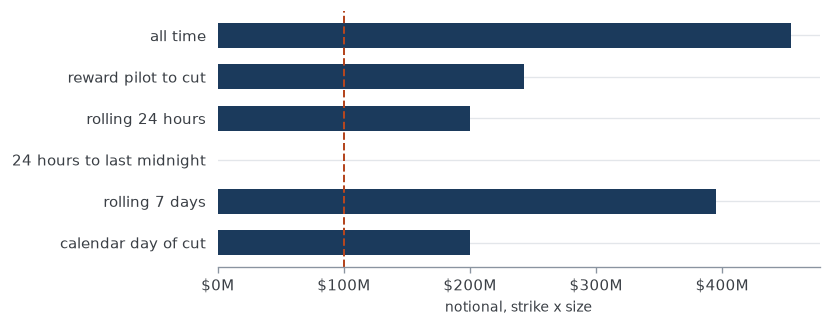

In [21]:
def win(a, b=None):
    s = df[df.ts >= a] if b is None else df[(df.ts >= a) & (df.ts < b)]
    return s
def iso(s): return dt.datetime.fromisoformat(s + "+00:00")

windows = {
    "all time":             df,
    "reward pilot to cut":  win(iso(PILOT_START), min(end + dt.timedelta(seconds=1), iso(PILOT_END))),
    "rolling 24 hours":     win(end - dt.timedelta(hours=24)),
    "24 hours to last midnight": win(iso(end.strftime("%Y-%m-%dT00:00:00")) - dt.timedelta(hours=24),
                                     iso(end.strftime("%Y-%m-%dT00:00:00"))),
    "rolling 7 days":       win(end - dt.timedelta(days=7)),
    "calendar day of cut":  df[df.ts.dt.date == end.date()],
}
WINT = pd.DataFrame([{"window": k, "trades": len(v),
                   "premium": float(v.premium.sum()),
                   "notional": float(v.notional.sum())} for k, v in windows.items()])
display(WINT.pipe(tbl, {"premium": "${:,.0f}", "notional": "${:,.0f}"}))

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(WINT["window"][::-1], WINT["notional"][::-1], color=INK, height=.6)
ax.axvline(100e6, color=WARN, lw=1.2, ls="--")
ax.xaxis.set_major_formatter(lambda x, p: f"${x/1e6:.0f}M")
ax.set_xlabel("notional, strike x size")
plt.tight_layout(); plt.savefig(CHARTS / "notional-windows.png", dpi=170, bbox_inches="tight"); plt.show()

### Which day, and which hour of it

The same notional split by calendar day, and then the biggest of those days
split by hour. Both are UTC and both are the tape's own `created_at`. For the
four days with the most notional, the spacing between consecutive trades comes
from the tape's millisecond timestamp: the smallest gap, the median gap, and how
far apart the trades of $1M and over land.

days with at least one trade: 111 of 115 in the span
biggest day by notional: 2026-09-23  $199,894,185 on 87 trades = 44.0% of all notional


,trades,premium,notional,share of notional
2026-09-23,87,"$46,835","$199,894,185",44.0%
2026-09-21,433,"$29,670","$93,090,331",20.5%
2026-09-20,53,"$19,426","$91,886,175",20.2%
2026-07-07,1367,"$51,667","$15,522,363",3.4%
2026-07-08,843,"$89,489","$8,745,969",1.9%
2026-09-19,827,"$6,339","$5,516,704",1.2%
2026-07-10,517,"$41,885","$5,507,407",1.2%
2026-09-18,1105,"$175,483","$4,259,001",0.9%


busiest hour of 2026-09-23: 23:00-23:59 UTC carries $152,306,496 on 3 trades = 76.2% of the day, 33.5% of the tape
hours of that day with any trade: 22 of 24
the four days with the most notional, and the spacing of trades inside each


,day,trades,notional,share,min gap s,median gap s,trades >= $1M,min gap between those s,first to last of those
,2026-07-07,1367,"$15,522,363",3.41%,0.085,0.85,0,,
,2026-09-20,53,"$91,886,175",20.21%,0.000,28.47,6,0.000,0 days 00:03:55.842007
,2026-09-21,433,"$93,090,331",20.48%,0.000,24.82,2,0.000,0 days 00:00:00
,2026-09-23,87,"$199,894,185",43.97%,0.000,163.77,4,0.000,0 days 21:18:20.847801


those four days: 88.08% of all notional


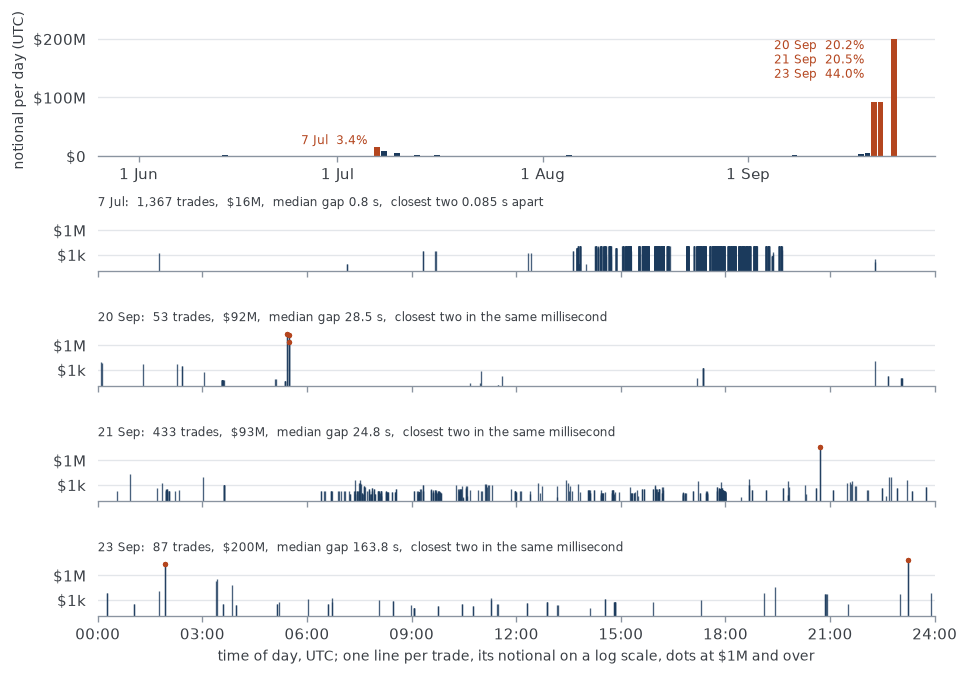

In [22]:
DAY = (df.assign(day=df.ts.dt.floor("D"))
         .groupby("day")
         .agg(trades=("trade_id", "size"), premium=("premium", "sum"),
              notional=("notional", "sum")))
peak = DAY.notional.idxmax()
print(f"days with at least one trade: {len(DAY)} of "
      f"{(DAY.index.max() - DAY.index.min()).days + 1} in the span")
print(f"biggest day by notional: {peak.date()}  ${float(DAY.notional.max()):,.0f} "
      f"on {int(DAY.loc[peak, 'trades'])} trades = "
      f"{float(DAY.notional.max() / df.notional.sum()) * 100:.1f}% of all notional")
top = DAY.sort_values("notional", ascending=False).head(8).copy()
top.index = [d.date() for d in top.index]
top["share of notional"] = [f"{float(v / df.notional.sum()) * 100:.1f}%" for v in top.notional]
display(top.pipe(tbl, {"premium": "${:,.0f}", "notional": "${:,.0f}"}))

HOUR = (df[df.ts.dt.floor("D") == peak]
          .assign(h=lambda x: x.ts.dt.hour)
          .groupby("h")
          .agg(trades=("trade_id", "size"), premium=("premium", "sum"),
               notional=("notional", "sum"))
          .reindex(range(24), fill_value=0))
th = int(HOUR.notional.idxmax())
print(f"busiest hour of {peak.date()}: {th:02d}:00-{th:02d}:59 UTC carries "
      f"${float(HOUR.notional.max()):,.0f} on {int(HOUR.loc[th, 'trades'])} trades = "
      f"{float(HOUR.notional.max() / DAY.notional.max()) * 100:.1f}% of the day, "
      f"{float(HOUR.notional.max() / df.notional.sum()) * 100:.1f}% of the tape")
print(f"hours of that day with any trade: {int((HOUR.trades > 0).sum())} of 24")

ch_x = df.sort_values("tms").assign(day=lambda x: x.ts.dt.floor("D"))
ch_tot = float(df.notional.sum())
ch_dn = DAY.notional.map(float)
ch_spikes = ch_dn.sort_values(ascending=False).head(4).index.sort_values()
ch_rows = []
for d in ch_spikes:
    s = ch_x[ch_x.day == d]
    gap = s.tms.diff().dropna() / 1000
    b = s[s.notional.map(float) >= 1e6]
    bgap = b.tms.diff().dropna() / 1000
    ch_rows.append({"day": d.date(), "trades": len(s), "notional": ch_dn[d],
                    "share": ch_dn[d] / ch_tot * 100,
                    "min gap s": gap.min(), "median gap s": gap.median(),
                    "trades >= $1M": len(b),
                    "min gap between those s": bgap.min() if len(bgap) else float("nan"),
                    "first to last of those": str(b.ts.max() - b.ts.min()) if len(b) else ""})
print("the four days with the most notional, and the spacing of trades inside each")
display(pd.DataFrame(ch_rows).pipe(tbl, {"notional": "${:,.0f}", "share": "{:.2f}%",
        "min gap s": "{:.3f}", "median gap s": "{:.2f}", "min gap between those s": "{:.3f}"}))
print(f"those four days: {sum(r['share'] for r in ch_rows):.2f}% of all notional")

fig = plt.figure(figsize=(9, 6.4))
gs = fig.add_gridspec(1 + len(ch_spikes), 1, height_ratios=[2.2] + [1] * len(ch_spikes), hspace=.75)
a0 = fig.add_subplot(gs[0])
ch_v = ch_dn.reindex(pd.date_range(ch_dn.index.min(), ch_dn.index.max(), freq="D"), fill_value=0)
a0.bar(ch_v.index, ch_v.values, width=.85, color=[WARN if d in ch_spikes else INK for d in ch_v.index])
a0.yaxis.set_major_formatter(short_usd); a0.set_ylabel("notional per day (UTC)")
a0.xaxis.set_major_locator(mdates.MonthLocator()); a0.xaxis.set_major_formatter(mdates.DateFormatter("%-d %b"))
ch_groups = []
for d in sorted(ch_spikes):
    if ch_groups and (d - ch_groups[-1][-1]).days <= 3:
        ch_groups[-1].append(d)
    else:
        ch_groups.append([d])
for g in ch_groups:
    a0.annotate("\n".join(f"{d:%-d %b}  {ch_dn[d] / ch_tot * 100:.1f}%" for d in g),
                (g[0], max(ch_dn[d] for d in g)), xytext=(-6, 0), textcoords="offset points",
                ha="right", va="top" if len(g) > 1 else "bottom", fontsize=7, color=WARN)
a0.set_ylim(0, ch_v.max() * 1.12)
for i, d in enumerate(ch_spikes):
    ax = fig.add_subplot(gs[i + 1])
    s = ch_x[ch_x.day == d]
    hh = (s.ts - d).dt.total_seconds() / 3600
    n = s.notional.map(float)
    ax.vlines(hh, 1, n, color=INK, lw=.8, alpha=.8)
    ax.scatter(hh[n >= 1e6], n[n >= 1e6], s=10, color=WARN, zorder=3, lw=0)
    ax.set_yscale("log"); ax.set_ylim(10, 2e8)
    ax.set_yticks([1e3, 1e6]); ax.yaxis.set_major_formatter(short_usd); ax.minorticks_off()
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
    ax.set_xticklabels([f"{t:02d}:00" for t in range(0, 25, 3)] if i == len(ch_spikes) - 1 else [])
    r = ch_rows[i]
    gap = "in the same millisecond" if r["min gap s"] == 0 else f"{r['min gap s']:.3f} s apart"
    ax.text(0, 1.04, f"{d:%-d %b}:  {r['trades']:,} trades,  {short_usd(r['notional'])},  "
            f"median gap {r['median gap s']:.1f} s,  closest two {gap}",
            transform=ax.transAxes, fontsize=7.2, va="bottom", color=TEXT)
ax.set_xlabel("time of day, UTC; one line per trade, its notional on a log scale, dots at $1M and over")
plt.savefig(CHARTS / "notional-by-day.png", bbox_inches="tight"); plt.show()

### The twelve trades that make the notional

The twelve largest trades by `notional`, each with its `premium` and its share of
`sum(notional)`, then the same two sums for the set of twelve.

In [23]:
top = df.sort_values("notional", ascending=False).head(12)[["trade_id","ts","symbol","price","size","side","taker","notional","premium"]].copy()
top["share of notional"] = (top.notional / notl).map(lambda x: f"{float(x)*100:.2f}%")
top["ts"] = top.ts.dt.strftime("%m-%d %H:%M:%S")
top["taker"] = top.taker.str[:10]
display(top.assign(notional=top.notional.map(float), premium=top.premium.map(float))
           .pipe(tbl, {"notional": "${:,.0f}", "premium": "${:,.2f}",
                          "price": "{:.4f}", "size": "{:,.4f}"}))
s10 = df.sort_values("notional", ascending=False).head(12)
print(f"twelve trades = {float(s10.notional.sum()/notl)*100:.1f}% of all notional "
      f"and {float(s10.premium.sum()/prem)*100:.2f}% of all premium")

,trade_id,ts,symbol,price,size,side,taker,notional,premium,share of notional
,41090,09-23 23:14:37,SP500-20260924-7630-P,1.9042,"10,000.0000",Sell,0xe55b5e5e,"$76,300,000","$19,041.79",16.78%
,41089,09-23 23:14:37,SP500-20260924-7600-P,0.2542,"10,000.0000",Buy,0xe55b5e5e,"$76,000,000","$2,541.79",16.72%
,40891,09-21 20:43:01,SP500-20260922-7700-P,2.8555,"6,048.0281",Buy,0xccbbe107,"$46,569,817","$17,270.14",10.24%
,40892,09-21 20:43:01,SP500-20260922-7660-P,0.6270,"6,048.0281",Sell,0xccbbe107,"$46,327,896","$3,792.11",10.19%
,40453,09-20 05:24:59,SP500-20260921-7560-P,1.6670,"3,404.2553",Buy,0xccbbe107,"$25,736,170","$5,674.89",5.66%
,40452,09-20 05:24:59,SP500-20260921-7520-P,0.4920,"3,404.2553",Sell,0xccbbe107,"$25,600,000","$1,674.89",5.63%
,41013,09-23 01:56:17,SP500-20260923-7730-P,3.6533,"3,032.9289",Buy,0xccbbe107,"$23,444,541","$11,080.26",5.16%
,41014,09-23 01:56:17,SP500-20260923-7710-P,1.3110,"3,032.9289",Sell,0xccbbe107,"$23,383,882","$3,976.17",5.14%
,40454,09-20 05:28:33,SP500-20260921-7580-P,3.0860,"2,326.6636",Buy,0xccbbe107,"$17,636,110","$7,180.08",3.88%
,40455,09-20 05:28:33,SP500-20260921-7550-P,0.9370,"2,326.6636",Sell,0xccbbe107,"$17,566,310","$2,180.08",3.86%


twelve trades = 84.4% of all notional and 8.95% of all premium


### How a size like that is arrived at

On a vertical spread, `size = net debit / width of the spread in price`. The
cell below pairs the legs of the largest trades, computes the net debit, the
strike width and the maximum payout, and tests each size against that
identity.

,time,taker,maker,net payer,net receiver,bought,sold,size,debit per contract,net debit $,strike width,max payout $,notional $,formula holds
,09-20 05:24:59,0xccbbe107,0xe55b5e5e,0xccbbe107,0xe55b5e5e,SP500-20260921-7560-P,SP500-20260921-7520-P,"3,404.25531914",1.1750,"$4,000.00",40,"$136,170","$51,336,170",True
,09-20 05:28:33,0xccbbe107,0xe55b5e5e,0xccbbe107,0xe55b5e5e,SP500-20260921-7580-P,SP500-20260921-7550-P,"2,326.66356444",2.1490,"$5,000.00",30,"$69,800","$35,202,420",True
,09-20 05:28:55,0xccbbe107,0xe55b5e5e,0xccbbe107,0xe55b5e5e,SP500-20260921-7590-P,SP500-20260921-7560-P,349.22297887,2.8635,"$1,000.00",30,"$10,477","$5,290,728",True
,09-21 20:43:01,0xccbbe107,0xe55b5e5e,0xccbbe107,0xe55b5e5e,SP500-20260922-7700-P,SP500-20260922-7660-P,"6,048.02814584",2.2285,"$13,478.03",40,"$241,921","$92,897,712",True
,09-23 01:56:17,0xccbbe107,0xe55b5e5e,0xccbbe107,0xe55b5e5e,SP500-20260923-7730-P,SP500-20260923-7710-P,"3,032.92894280",2.3423,"$7,104.09",20,"$60,659","$46,828,423",True
,09-23 23:14:37,0xe55b5e5e,0xccbbe107,0xccbbe107,0xe55b5e5e,SP500-20260924-7630-P,SP500-20260924-7600-P,"10,000.00000000",1.6500,"$16,500.00",30,"$300,000","$152,300,000",True



together: $383,855,453 of notional against $47,082.12 actually paid = 8,153x
the most those spreads can pay: $819,027
net payer on every one of them: ['0xccbbe107']
net receiver on every one:      ['0xe55b5e5e']
maker on them:                  ['0xccbbe107', '0xe55b5e5e']
each spread is two legs in the same second between the same two addresses;
'bought' and 'sold' are from the net payer's side


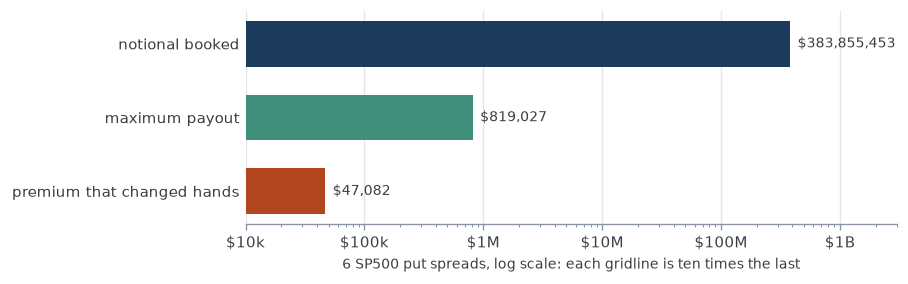

In [24]:
big = df.sort_values("notional", ascending=False).head(12)
pairs = []
for (t, tk), g in big.groupby([big.ts, big.taker]):
    if len(g) != 2 or set(g.side) != {"Buy", "Sell"}:
        continue
    b = g[g.side == "Buy"].iloc[0]; s = g[g.side == "Sell"].iloc[0]
    if b["size"] != s["size"]:
        continue
    dear, cheap = (b, s) if b.price > s.price else (s, b)
    payer = tk if dear is b else b.maker
    debit = dear.price - cheap.price
    pairs.append({"time": t.strftime("%m-%d %H:%M:%S"), "taker": tk[:10],
                  "maker": b.maker[:10], "net payer": payer[:10],
                  "net receiver": (b.maker if payer == tk else tk)[:10],
                  "bought": dear.symbol, "sold": cheap.symbol,
                  "size": float(b["size"]),
                  "debit per contract": float(debit),
                  "net debit $": float(debit * b["size"]),
                  "strike width": float(abs(b.strike - s.strike)),
                  "max payout $": float(abs(b.strike - s.strike) * b["size"]),
                  "notional $": float(b.notional + s.notional),
                  "debit / width": float(debit * b["size"] / debit)})
PR = pd.DataFrame(pairs)
if len(PR):
    PR["formula holds"] = (PR["size"] - PR["debit / width"]).abs() < 1e-6
    display(PR.drop(columns=["debit / width"]).pipe(tbl, {
        "size": "{:,.8f}", "debit per contract": "{:.4f}", "net debit $": "${:,.2f}",
        "strike width": "{:,.0f}", "max payout $": "${:,.0f}",
        "notional $": "${:,.0f}"}))
    print(f"\ntogether: ${PR['notional $'].sum():,.0f} of notional "
          f"against ${PR['net debit $'].sum():,.2f} actually paid "
          f"= {PR['notional $'].sum()/PR['net debit $'].sum():,.0f}x")
    print(f"the most those spreads can pay: ${PR['max payout $'].sum():,.0f}")
    print(f"net payer on every one of them: {sorted(set(PR['net payer']))}")
    print(f"net receiver on every one:      {sorted(set(PR['net receiver']))}")
    print(f"maker on them:                  {sorted(set(PR['maker']))}")
    print("each spread is two legs in the same second between the same two addresses;")
    print("'bought' and 'sold' are from the net payer's side")
    ch_vals = [("notional booked", PR["notional $"].sum(), INK),
               ("maximum payout", PR["max payout $"].sum(), HL),
               ("premium that changed hands", PR["net debit $"].sum(), WARN)]
    fig, ax = plt.subplots(figsize=(7, 2.3))
    for i, (lab, val, c) in enumerate(ch_vals):
        ax.barh(i, val, color=c, height=.62)
        ax.text(val * 1.15, i, f"${val:,.0f}", va="center", fontsize=8.5, color=TEXT)
    ax.set_xscale("log"); ax.set_xlim(1e4, 3e9); ax.invert_yaxis()
    ax.set_yticks(range(3), [v[0] for v in ch_vals]); ax.tick_params(axis="y", length=0)
    ax.xaxis.set_major_formatter(short_usd); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlabel(f"{len(PR)} {PR.bought.str.split('-').str[0].iloc[0]} put spreads, log scale: each gridline is ten times the last")
    plt.savefig(CHARTS / "notional-vs-paid.png", bbox_inches="tight"); plt.show()
else:
    print("no vertical spread pairs among the largest trades at this cut")

### The twelve largest trades

One bar pair per trade: the notional the venue books against the premium that
actually changed hands for it. The axis is logarithmic, so bars of equal length
would mean equal dollars.

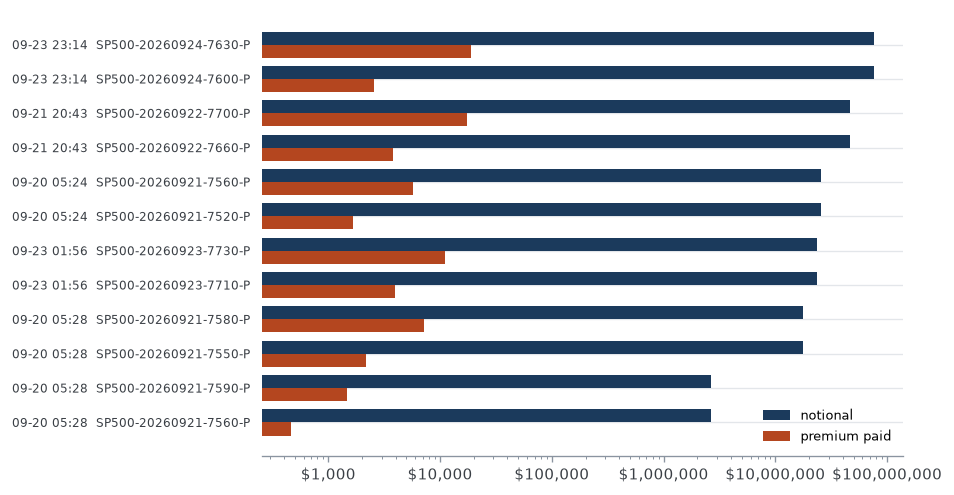

these twelve carry $383,855,453.27 of notional for $76,335.92 of premium = 5,029x
that is 84.44% of all notional and 8.95% of all premium


In [25]:
T10 = df.sort_values("notional", ascending=False).head(12).copy()
T10["label"] = [f"{r.ts:%m-%d %H:%M}  {r.symbol}" for r in T10.itertuples()]
t_not = T10.notional.map(float); t_pr = T10.premium.map(float)
fig, ax = plt.subplots(figsize=(8, 4.2))
y = list(range(len(T10)))[::-1]
ax.barh([i + .19 for i in y], t_not, height=.38, color=INK, label="notional")
ax.barh([i - .19 for i in y], t_pr, height=.38, color=WARN, label="premium paid")
ax.set_yticks(y); ax.set_yticklabels(T10.label, fontsize=7)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(lambda x, p: f"${x:,.0f}")
ax.legend(loc="lower right", frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(CHARTS / "top-trades.png", dpi=170, bbox_inches="tight"); plt.show()
all_not = float(df.notional.map(float).sum()); all_pr = float(df.premium.map(float).sum())
print(f"these twelve carry ${t_not.sum():,.2f} of notional "
      f"for ${t_pr.sum():,.2f} of premium = {t_not.sum()/t_pr.sum():,.0f}x")
print(f"that is {t_not.sum()/all_not*100:.2f}% of all notional "
      f"and {t_pr.sum()/all_pr*100:.2f}% of all premium")

## 8. The loops

### The mechanism

Settlement does not have to happen trade by trade. Two addresses can run
volume in one direction, square up between themselves, and go again. The test
that matters is not whether each trade offsets, but how much cash ever stands
between them while the volume is produced.

This cell takes the largest matched pair and walks its running balance: what
one side owes the other after every trade, in order.

In [26]:
a_, b_ = sorted(m_pairs, key=lambda pr: -sum(
    2 * min(d["ab"], d["ba"]) * strike[s]
    for (x, y, s, px), d in px_q.items() if (x, y) == pr))[0]
lp = df[(df.maker.str.lower().isin([a_, b_])) & (df.taker.str.lower().isin([a_, b_]))]
lp = lp.sort_values("trade_id")
print(f"pair {a_[:12]} <-> {b_[:12]}: {len(lp):,} trades, "
      f"premium ${float(lp.premium.sum()):,.2f}, fees "
      f"${float(lp.maker_fee.sum() + lp.taker_fee.sum()):,.2f}")

run, hist = D(0), []
for r in lp.itertuples():
    run += r.premium if r.taker.lower() == a_ else -r.premium
    hist.append(run)
print(f"running balance one owes the other: max ${float(max(hist)):,.2f}, "
      f"min ${float(min(hist)):,.2f}, final ${float(hist[-1]):,.2f}")
print(f"gross premium moved through that balance: ${float(lp.premium.sum()):,.2f}")
peak = max(max(hist), -min(hist))
if peak:
    print(f"premium produced per dollar ever at risk between them: "
          f"{float(lp.premium.sum() / peak):,.1f}x")

per = []
for sym, sub in lp.groupby("symbol"):
    seq = ["a" if t.lower() == a_ else "b" for t in sub.sort_values("trade_id").taker]
    per.append({"instrument": sym, "trades": len(sub),
                "distinct prices": sub.price.nunique(),
                "modal size": str(sub["size"].mode().iloc[0]),
                "taker changes": sum(1 for i in range(len(seq) - 1) if seq[i] != seq[i + 1]),
                "sides traded": sub.side.nunique(),
                "premium": float(sub.premium.sum())})
display(pd.DataFrame(per).sort_values("premium", ascending=False)
          .pipe(tbl, {"premium": "${:,.2f}"}, index=False))

pair 0x00a90b9130 <-> 0x0c6657303f: 1,167 trades, premium $173,221.73, fees $0.00
running balance one owes the other: max $3,394.81, min $-2,023.35, final $3,394.81
gross premium moved through that balance: $173,221.73
premium produced per dollar ever at risk between them: 51.0x


,instrument,trades,distinct prices,modal size,taker changes,sides traded,premium
,SNDK-20261002-1630-C,484,1,2,1,1,"$87,112.21"
,SNDK-20261002-1640-C,484,1,2,1,1,"$82,714.55"
,SP500-20260919-7640-C,196,153,1,0,1,"$3,394.89"
,SP500-20260919-7680-C,3,3,2,0,1,$0.08


A pair that alternated naturally would swap taker and maker constantly. One
change of taker across hundreds of trades means the volume ran one way to the
end, then ran back.

### One of them, trade by trade

The largest flat instrument by notional that two addresses ran between them.
The point of printing the ends is the shape: one address is the maker on every
trade, the other is the taker on every trade, and the taker's side flips part
way through. That is not a book being made. It is a position walked out and
walked back, and the prices it is walked at are free, because the same two
addresses are on both ends of every one of them.

SP500-20260708-7520-P: 457 trades, 2026-07-07 17:14:44 .. 18:54:03
  maker on every trade: ['0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e']  (1 address)
  taker on every trade: ['0x88c8df8de727854bff379745b22344957c7cc104']  (1 address)
  distinct prices 31   sizes ['0.005', '1.595', '1.6']
  sides ['Buy', 'Sell']   fees $0.00
  notional $5,475,462.40
  the maker's position: opens -1.59, peaks -66.99, ends 0.00
  changes of side: 28


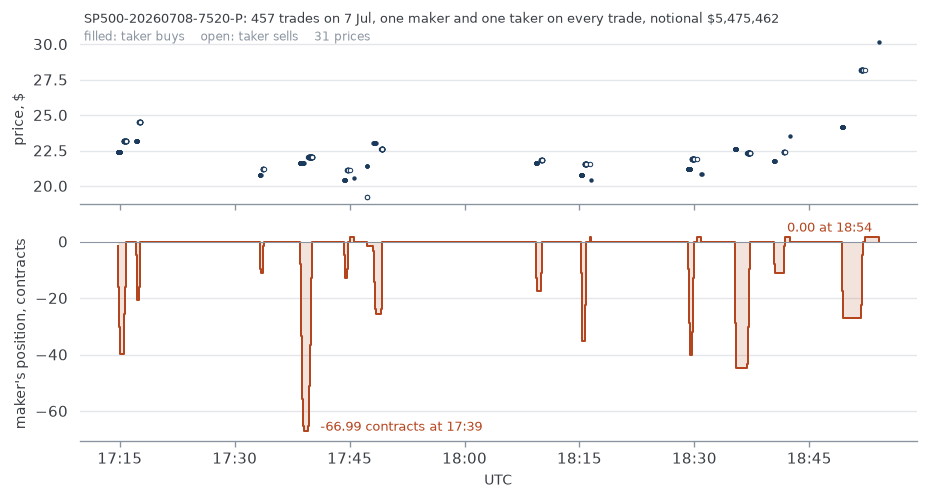

In [27]:
BIG = FT[FT.addresses == 2].iloc[0].instrument
bg = df[df.symbol == BIG].sort_values("trade_id")
mk = bg.maker.str.lower(); tk = bg.taker.str.lower()
print(f"{BIG}: {len(bg):,} trades, "
      f"{bg.ts.min():%Y-%m-%d %H:%M:%S} .. {bg.ts.max():%H:%M:%S}")
print(f"  maker on every trade: {sorted(set(mk))}  ({mk.nunique()} address)")
print(f"  taker on every trade: {sorted(set(tk))}  ({tk.nunique()} address)")
print(f"  distinct prices {bg.price.nunique()}   sizes {sorted({str(x) for x in bg['size']})}")
print(f"  sides {sorted(set(bg.side))}   fees ${float(bg.maker_fee.sum() + bg.taker_fee.sum()):,.2f}")
print(f"  notional ${float(bg.notional.sum()):,.2f}")
A = sorted(set(mk))[0]
run, seq = D(0), []
for r in bg.itertuples():
    run -= (r.size if str(r.side).lower().startswith("b") else -r.size)
    seq.append(run)
print(f"  the maker's position: opens {float(seq[0]):,.2f}, "
      f"peaks {float(min(seq)):,.2f}, ends {float(seq[-1]):,.2f}")
sides = list(bg.side)
print(f"  changes of side: {sum(1 for i in range(len(sides) - 1) if sides[i] != sides[i+1])}")

oi_t = bg.ts.reset_index(drop=True)
oi_pos = [float(v) for v in seq]
oi_buy = bg.side.str.lower().str.startswith("b").values
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1.25], "hspace": .12})
oi_px = bg.price.map(float).values
a1.scatter(oi_t[oi_buy], oi_px[oi_buy], s=7, color=INK, lw=0)
a1.scatter(oi_t[~oi_buy], oi_px[~oi_buy], s=7, facecolor="white", edgecolor=INK, lw=.6)
a1.set_ylabel("price, $")
a1.text(.005, 1.13, f"{BIG}: {len(bg):,} trades on {oi_t.iloc[0]:%-d %b}, one maker and one taker "
        f"on every trade, notional ${float(bg.notional.sum()):,.0f}",
        transform=a1.transAxes, fontsize=7.5, va="top", color=TEXT)
a1.text(.005, 1.02, f"filled: taker buys    open: taker sells    {bg.price.nunique()} prices",
        transform=a1.transAxes, fontsize=7, va="top", color=MUTE)
a2.fill_between(oi_t, 0, oi_pos, step="post", color=WARN, alpha=.15, lw=0)
a2.step(oi_t, oi_pos, where="post", color=WARN, lw=1.2)
a2.axhline(0, color=MUTE, lw=.6)
oi_lo = min(range(len(oi_pos)), key=oi_pos.__getitem__)
a2.annotate(f"{oi_pos[oi_lo]:,.2f} contracts at {oi_t.iloc[oi_lo]:%H:%M}", (oi_t.iloc[oi_lo], oi_pos[oi_lo]),
            xytext=(10, 2), textcoords="offset points", va="center", fontsize=7.5, color=WARN)
a2.annotate(f"{oi_pos[-1]:,.2f} at {oi_t.iloc[-1]:%H:%M}", (oi_t.iloc[-1], oi_pos[-1]),
            xytext=(-4, 6), textcoords="offset points", ha="right", fontsize=7.5, color=WARN)
a2.set_ylabel("maker's position, contracts")
a2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="UTC"))
a2.set_xlabel("UTC")
plt.savefig(CHARTS / "one-instrument.png", bbox_inches="tight"); plt.show()

### New addresses, and how much they carry

Every address's first appearance on the tape, against the premium it went on
to trade. The question is whether the premium comes from the venue's standing
users or from addresses that arrive, produce it, and stop.

In [28]:
fst = pd.concat([df[["ts"]].assign(a=df.maker.str.lower()),
                 df[["ts"]].assign(a=df.taker.str.lower())])
fst = fst.groupby("a").ts.agg(["min", "max", "count"])
prem_a = collections.defaultdict(D)
for r in df.itertuples():
    prem_a[r.maker.lower()] += r.premium; prem_a[r.taker.lower()] += r.premium
fst["premium"] = [float(prem_a[a]) for a in fst.index]
fst["day"] = fst["min"].dt.date
fst["hours alive"] = (fst["max"] - fst["min"]).dt.total_seconds() / 3600

NEWD = (fst.groupby("day")
           .agg(**{"addresses first seen": ("premium", "size"),
                   "premium they traded": ("premium", "sum")})
           .sort_values("premium they traded", ascending=False).head(6))
display(NEWD.pipe(tbl, {"premium they traded": "${:,.2f}"}))

BUSY = fst.sort_values("premium", ascending=False).head(8).copy()
BUSY["trades per hour"] = BUSY["count"] / BUSY["hours alive"].replace(0, float("nan"))
BUSY.index = [a[:12] for a in BUSY.index]
display(BUSY[["min", "max", "hours alive", "count", "trades per hour", "premium"]]
        .rename(columns={"min": "first trade", "max": "last trade", "count": "trades"})
        .pipe(tbl, {"premium": "${:,.2f}", "hours alive": "{:,.1f}",
                    "trades per hour": "{:,.1f}"}))

,addresses first seen,premium they traded
day,,
2026-06-01,3,"$640,674.18"
2026-07-02,2,"$457,556.51"
2026-07-29,4,"$187,480.98"
2026-09-18,11,"$178,547.30"
2026-09-19,2,"$80,018.11"
2026-06-27,3,"$31,284.59"


,first trade,last trade,hours alive,trades,trades per hour,premium
,2026-06-01 19:55:30.540837+00:00,2026-09-23 23:53:52.115623+00:00,"2,740.0",11188,4.1,"$639,902.60"
,2026-07-02 01:14:01.285083+00:00,2026-09-18 05:09:35.075717+00:00,"1,875.9",5395,2.9,"$457,555.07"
,2026-07-29 16:23:23.957185+00:00,2026-09-23 23:53:52.115623+00:00,"1,351.5",1454,1.1,"$184,492.44"
,2026-09-18 02:35:49.091248+00:00,2026-09-19 19:44:54.856112+00:00,41.2,1369,33.3,"$176,057.36"
,2026-09-19 04:10:15.528094+00:00,2026-09-23 23:14:37.878150+00:00,115.1,118,1.0,"$79,423.21"
,2026-06-27 03:30:03.188382+00:00,2026-09-23 14:50:35.498464+00:00,"2,123.3",1665,0.8,"$28,714.59"
,2026-07-22 16:29:35.271801+00:00,2026-09-23 14:50:35.498464+00:00,"1,510.4",474,0.3,"$12,364.83"
,2026-07-09 17:30:49.854575+00:00,2026-09-08 12:45:07.831393+00:00,"1,459.2",131,0.1,"$10,936.30"


### Turnover against money kept

Premium traded is what the venue reports. Net cash is what an address actually
finished up or down, summing every trade it was on: the buyer pays, the seller
receives. The ratio is how many times the same money went around.

,address,trades,premium traded,net cash,turns
,0xe55b5e5e38,11188,"$639,902.60","$-34,864.76",18.4x
,0x88c8df8de7,5395,"$457,555.07","$+133,961.38",3.4x
,0x0c6657303f,1454,"$184,492.44","$-3,545.14",52.0x
,0x00a90b9130,1369,"$176,057.36","$-3,267.96",53.9x
,0xccbbe10767,118,"$79,423.21","$-50,169.41",1.6x
,0xcd4b4e9189,1665,"$28,714.59",$+268.84,106.8x
,0x74ec5528a0,474,"$12,364.83","$-6,905.55",1.8x
,0x9b21bb72db,131,"$10,936.30","$-7,509.78",1.5x


all 509 addresses: premium traded $1,706,643.19 against $303,635.05 of net cash = 5.62x


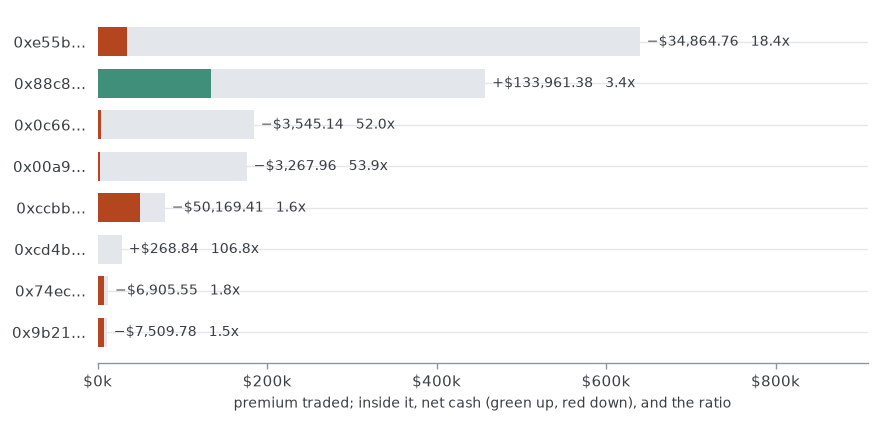

In [29]:
cash = collections.defaultdict(D)
for r in df.itertuples():
    buyer, seller = ((r.taker.lower(), r.maker.lower())
                     if str(r.side).lower().startswith("b")
                     else (r.maker.lower(), r.taker.lower()))
    cash[buyer] -= r.premium; cash[seller] += r.premium

TURN = pd.DataFrame([{"address": a[:12], "trades": int(fst.loc[a, "count"]),
                      "premium traded": float(prem_a[a]),
                      "net cash": float(cash[a]),
                      "turns": (float(prem_a[a] / abs(cash[a])) if cash[a] else None)}
                     for a in sorted(prem_a, key=lambda x: -prem_a[x])[:8]])
display(TURN.pipe(tbl, {"premium traded": "${:,.2f}", "net cash": "${:+,.2f}",
                        "turns": "{:,.1f}x"}, index=False))
gp = sum(prem_a.values()); gc = sum(abs(v) for v in cash.values())
print(f"all {len(prem_a)} addresses: premium traded ${float(gp):,.2f} "
      f"against ${float(gc):,.2f} of net cash = {float(gp/gc):,.2f}x")

fig, ax = plt.subplots(figsize=(7.4, 3.6))
tv = TURN[::-1]
ylab = [f"{a[:6]}…" for a in tv["address"]]
ax.barh(ylab, tv["premium traded"], color=RULE, height=.7, label="premium traded")
ax.barh(ylab, tv["net cash"].abs(), height=.7,
        color=[HL if v > 0 else WARN for v in tv["net cash"]])
for y, (p, c, t) in enumerate(zip(tv["premium traded"], tv["net cash"], tv["turns"])):
    ax.text(p + 8000, y, f"{'+' if c > 0 else '−'}${abs(c):,.2f}   {t:,.1f}x",
            va="center", fontsize=8.5, color=TEXT)
ax.set_xlim(0, tv["premium traded"].max() * 1.42)
ax.xaxis.set_major_formatter(lambda x, p: f"${x/1000:,.0f}k")
ax.set_xlabel("premium traded; inside it, net cash (green up, red down), and the ratio")
plt.tight_layout(); plt.savefig(CHARTS / "turnover.png", dpi=170, bbox_inches="tight"); plt.show()

### When the trading happens

Underlyings are split into `{BTC, ETH}` and the rest; the rest are equities and
indices whose own markets trade Mon-Fri 13:30-20:00 UTC. For that subset:
trades, premium and notional by UTC weekday; the weekend share of each; and
the share falling inside `weekday < 5 and 810 <= minute-of-day < 1200`.

In [30]:
CRYPTO = {"BTC", "ETH"}
eq = df[~df.underlying.isin(CRYPTO)]
print(f"equity and index instruments: {len(eq)} trades = {len(eq)/len(df)*100:.1f}% of the tape")
print(f"underlyings: {sorted(df.underlying.unique())}")

names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
wd = eq.assign(d=eq.ts.dt.weekday).groupby("d").agg(
    trades=("price","size"), premium=("premium","sum"), notional=("notional","sum"))
wd = wd.reindex(range(7)).fillna(0)
wd.index = names
wd["% of notional"] = wd.notional.map(float) / float(eq.notional.sum()) * 100
display(wd.assign(premium=wd.premium.map(float), notional=wd.notional.map(float))
        .pipe(tbl, {"premium":"${:,.0f}","notional":"${:,.0f}","% of notional":"{:.1f}%"}))

we = eq[eq.ts.dt.weekday >= 5]
print(f"\nweekends: {len(we)} trades = {len(we)/len(eq)*100:.1f}%, "
      f"premium {float(we.premium.sum()/eq.premium.sum())*100:.1f}%, "
      f"NOTIONAL {float(we.notional.sum()/eq.notional.sum())*100:.1f}%")

mins = eq.ts.dt.hour*60 + eq.ts.dt.minute
rth = eq[(eq.ts.dt.weekday < 5) & (mins >= 810) & (mins < 1200)]
print(f"in the US regular session (Mon-Fri 13:30-20:00 UTC): {len(rth)/len(eq)*100:.1f}% of trades, "
      f"{float(rth.premium.sum()/eq.premium.sum())*100:.1f}% of premium, "
      f"{float(rth.notional.sum()/eq.notional.sum())*100:.1f}% of notional")

equity and index instruments: 13711 trades = 96.5% of the tape
underlyings: ['AAPL', 'BABA', 'BOT', 'BTC', 'ETH', 'META', 'MSFT', 'MU', 'NVDA', 'SNDK', 'SP500', 'SPCX']


,trades,premium,notional,% of notional
,2089,"$107,228","$99,094,420",21.9%
,2806,"$85,273","$19,647,070",4.3%
,2337,"$185,264","$213,176,420",47.1%
,1836,"$138,352","$5,452,935",1.2%
,2497,"$254,467","$13,321,390",2.9%
,1317,"$16,981","$7,239,866",1.6%
,829,"$47,308","$94,998,361",21.0%



weekends: 2146 trades = 15.7%, premium 7.7%, NOTIONAL 22.6%
in the US regular session (Mon-Fri 13:30-20:00 UTC): 43.4% of trades, 45.3% of premium, 8.2% of notional


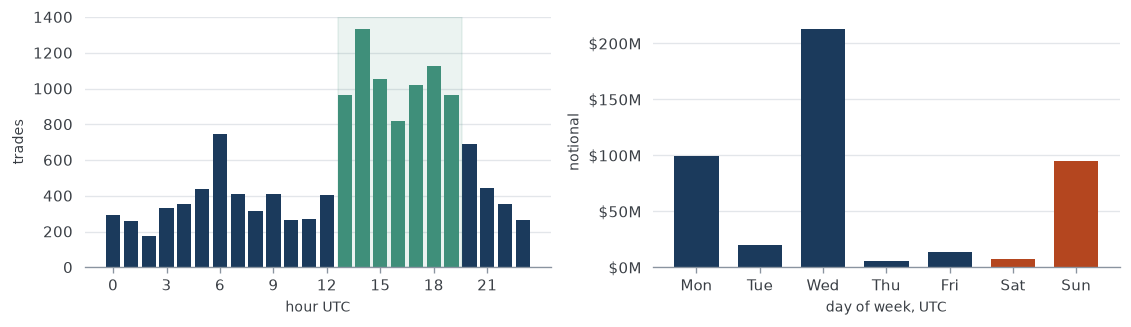

In [31]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 2.8))
h = eq.groupby(eq.ts.dt.hour).size().reindex(range(24), fill_value=0)
a1.bar(h.index, h.values, color=[HL if 13 <= i < 20 else INK for i in h.index], width=.8)
a1.axvspan(12.6, 19.6, color=HL, alpha=.10)
a1.set_xlabel("hour UTC"); a1.set_ylabel("trades"); a1.set_xticks(range(0, 24, 3))
a2.bar(names, wd.notional.map(float), color=[INK]*5 + [WARN]*2, width=.7)
a2.yaxis.set_major_formatter(lambda x, p: f"${x/1e6:.0f}M")
a2.set_ylabel("notional"); a2.set_xlabel("day of week, UTC")
plt.tight_layout(); plt.savefig(CHARTS / "hours-weekday.png", dpi=170, bbox_inches="tight"); plt.show()

### At what price

Trades bucketed by `price` at `[0, 0.01, 1, 10, 100, inf)`, with the premium
and notional in each bucket.

In [32]:
bins = [D(0), D("0.01"), D(1), D(10), D(100), D("1e12")]
lbl = ["< $0.01", "$0.01-1", "$1-10", "$10-100", "> $100"]
T = []
for (lo, hi), l in zip(zip(bins, bins[1:]), lbl):
    s = df[(df.price >= lo) & (df.price < hi)]
    T.append({"price per contract": l, "trades": len(s), "% of trades": len(s)/len(df)*100,
              "premium": float(s.premium.sum()), "notional": float(s.notional.sum())})
TT = pd.DataFrame(T)
display(TT.pipe(tbl, {"% of trades":"{:.1f}%","premium":"${:,.0f}",
                      "notional":"${:,.0f}"}))
sub = TT[TT["price per contract"].isin(["< $0.01", "$0.01-1"])]
print(f"under a dollar a contract: {sub['% of trades'].sum():.1f}% of trades, "
      f"${sub.notional.sum():,.0f} of notional = "
      f"{sub.notional.sum()/float(df.notional.sum())*100:.1f}% of it")

,price per contract,trades,% of trades,premium,notional
,< $0.01,486,3.4%,$18,"$3,394,621"
,$0.01-1,2509,17.7%,"$28,994","$176,303,199"
,$1-10,3958,27.9%,"$251,867","$232,089,957"
,$10-100,6696,47.1%,"$434,842","$39,696,869"
,> $100,556,3.9%,"$137,600","$3,112,864"


under a dollar a contract: 21.1% of trades, $179,697,820 of notional = 39.5% of it


### Concentration and round trips

Premium by unordered address pair `{maker, taker}`, and the share held by the
two largest.

Round trip, as defined here: two trades with the same taker, the same symbol,
equal `size`, opposite `taker_side`, and `0 < dt <= 60 s`. Reported: how many
distinct addresses have at least one, and the median `dt`. The definition is a
filter over the tape and carries no claim about intent.

,premium,share
,"$435,516",51.04%
,"$173,222",20.30%
,"$79,406",9.31%
,"$13,806",1.62%
,"$10,615",1.24%


the two busiest pairs: 71.34% of all premium


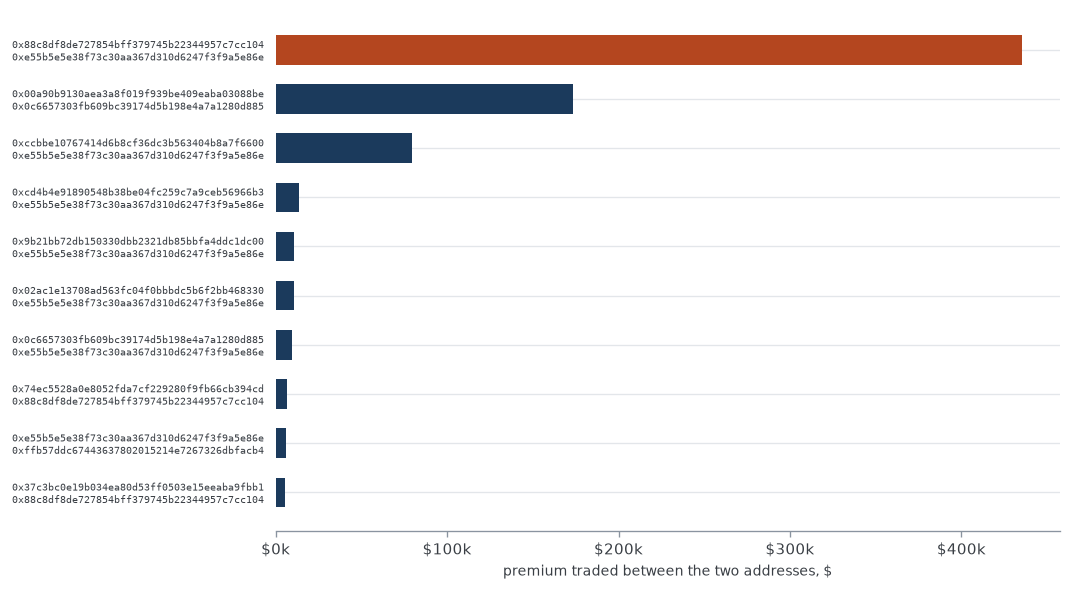

the ten busiest pairs together: $750,625.07 = 87.97% of all premium


addresses with a round trip: 288 of 509 = 56.58%
median gap between the legs: 13.512 s


addresses whose whole history is one round trip: 242 of 509 = 47.54%
  median gap 7.418 s; premium $12,242.18 = 1.43% of all premium; their net cash $-385.76


,addresses,premium,% of addresses,% of premium
trades per address,,,,
1,31,$804,6.1%,0.09%
2,295,"$7,239",58.0%,0.85%
3-5,63,"$4,619",12.4%,0.54%
6-10,37,"$6,586",7.3%,0.77%
11-100,63,"$19,485",12.4%,2.28%
"101-1,000",15,"$71,228",2.9%,8.35%
"over 1,000",5,"$743,361",1.0%,87.11%


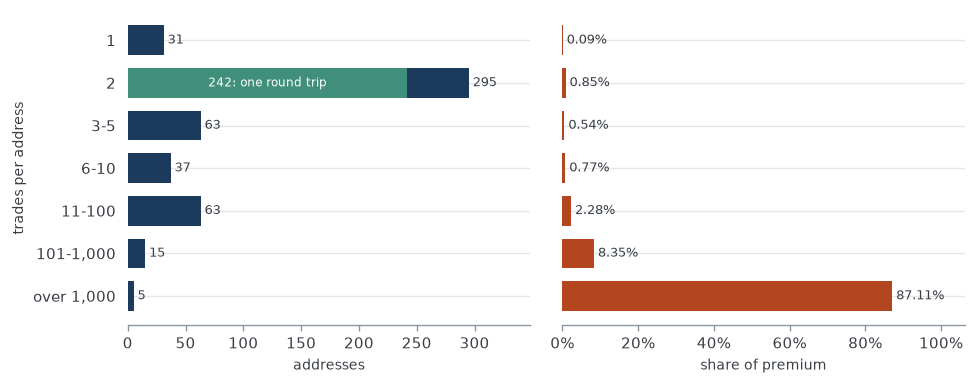

,addresses appearing that day
ts,
2026-09-16,19
2026-09-17,87
2026-09-18,12
2026-09-19,1
2026-09-20,2
2026-09-21,65
2026-09-22,23
2026-09-23,13


In [33]:
by_pair = df.assign(pair=df.apply(lambda r: tuple(sorted((r.maker, r.taker))), axis=1)) \
            .groupby("pair").premium.sum().sort_values(ascending=False)
TOPP = by_pair.head(5).to_frame("premium")
TOPP["share"] = (TOPP.premium / prem).map(lambda x: float(x)*100)
TOPP.index = [f"{a[:10]} / {b[:10]}" for a, b in TOPP.index]
display(TOPP.assign(premium=TOPP.premium.map(float)).pipe(tbl, {"premium":"${:,.0f}","share":"{:.2f}%"}))
print(f"the two busiest pairs: {float(by_pair.head(2).sum()/prem)*100:.2f}% of all premium")

P10 = by_pair.head(10)[::-1]
lab = [f"{a}\n{b}" for a, b in P10.index]
fig, ax = plt.subplots(figsize=(9, 5.0))
ax.barh(range(len(P10)), P10.map(float), height=.6,
        color=[WARN if i == len(P10) - 1 else INK for i in range(len(P10))])
ax.set_yticks(range(len(P10))); ax.set_yticklabels(lab, fontsize=6, family="monospace")
ax.xaxis.set_major_formatter(lambda x, p: f"${x/1000:,.0f}k")
ax.set_xlabel("premium traded between the two addresses, $")
plt.tight_layout(); plt.savefig(CHARTS / "top-pairs.png", dpi=170, bbox_inches="tight"); plt.show()
print(f"the ten busiest pairs together: ${float(P10.sum()):,.2f}"
      f" = {float(P10.sum()/prem)*100:.2f}% of all premium")

taken = df.sort_values("ts")
rt, rt_gaps = set(), []
for tk, g in taken.groupby("taker"):
    g = g.sort_values("ts")
    for sym, h in g.groupby("symbol"):
        h = h.sort_values("ts").itertuples()
        h = list(h)
        for i, a in enumerate(h):
            for b in h[i+1:]:
                dtt = (b.ts - a.ts).total_seconds()
                if dtt > 60: break
                if a.side != b.side and a.size == b.size:
                    rt.add(tk); rt_gaps.append(dtt); break
print(f"addresses with a round trip: {len(rt)} of {len(addrs)} = {len(rt)/len(addrs)*100:.2f}%")
if rt_gaps:
    rt_gaps.sort(); print(f"median gap between the legs: {rt_gaps[len(rt_gaps)//2]:.3f} s")

lo, hi = df.maker.str.lower(), df.taker.str.lower()
n_all = pd.concat([lo, hi]).value_counts()
one_rt, one_gap, one_prem, one_cash = [], [], D(0), D(0)
for a_, n_ in n_all.items():
    if n_ != 2:
        continue
    g = df[(hi == a_)].sort_values("ts")
    if len(g) != 2 or (lo == a_).any():
        continue
    x, y = g.iloc[0], g.iloc[1]
    gap = (y.ts - x.ts).total_seconds()
    if x.symbol == y.symbol and x["size"] == y["size"] and x.side != y.side and 0 < gap <= 60:
        one_rt.append(a_); one_gap.append(gap)
        one_prem += x.premium + y.premium
        one_cash += sum(-r.premium if r.side == "Buy" else r.premium for r in (x, y))
one_gap.sort()
print(f"addresses whose whole history is one round trip: {len(one_rt)} of {len(addrs)}"
      f" = {len(one_rt)/len(addrs)*100:.2f}%")
if one_rt:
    print(f"  median gap {one_gap[len(one_gap)//2]:.3f} s; premium ${float(one_prem):,.2f}"
          f" = {float(one_prem/prem)*100:.2f}% of all premium; their net cash ${float(one_cash):+,.2f}")

tp_half = pd.concat([pd.Series([float(p) / 2 for p in df.premium], index=lo.index).groupby(lo).sum(),
                  pd.Series([float(p) / 2 for p in df.premium], index=hi.index).groupby(hi).sum()]
                 ).groupby(level=0).sum()
TP_EDGES = [0, 1, 2, 5, 10, 100, 1000, float("inf")]
TP_NAMES = ["1", "2", "3-5", "6-10", "11-100", "101-1,000", "over 1,000"]
tp_per = pd.DataFrame({"trades": n_all, "premium": tp_half.reindex(n_all.index).fillna(0)})
tp_per["bucket"] = pd.cut(tp_per.trades, TP_EDGES, labels=TP_NAMES)
tp_bk = tp_per.groupby("bucket", observed=False).agg(addresses=("trades", "size"), premium=("premium", "sum"))
tp_bk["% of addresses"] = tp_bk.addresses / tp_bk.addresses.sum() * 100
tp_bk["% of premium"] = tp_bk.premium / tp_bk.premium.sum() * 100
tp_show = tp_bk.copy(); tp_show["premium"] = tp_show.premium.map(lambda tp_v: f"${tp_v:,.0f}")
tp_show["% of addresses"] = tp_show["% of addresses"].map(lambda tp_v: f"{tp_v:.1f}%")
tp_show["% of premium"] = tp_show["% of premium"].map(lambda tp_v: f"{tp_v:.2f}%")
display(tp_show.rename_axis("trades per address"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True, gridspec_kw={"wspace": .08})
tp_y = list(range(len(TP_NAMES)))[::-1]
a1.barh(tp_y, tp_bk.addresses, color=INK, height=.7)
tp_k2 = TP_NAMES.index("2")
a1.barh(tp_y[tp_k2], len(one_rt), color=HL, height=.7)
for tp_yi, tp_v in zip(tp_y, tp_bk.addresses):
    a1.text(tp_v, tp_yi, f" {tp_v:,}", va="center", fontsize=7.5, color=TEXT)
a1.text(len(one_rt) / 2, tp_y[tp_k2], f"{len(one_rt)}: one round trip", va="center", ha="center",
        fontsize=7, color="white")
a1.set_yticks(tp_y); a1.set_yticklabels(TP_NAMES)
a1.set_ylabel("trades per address"); a1.set_xlabel("addresses")
a1.set_xlim(0, tp_bk.addresses.max() * 1.18)
a2.barh(tp_y, tp_bk["% of premium"], color=WARN, height=.7)
for tp_yi, tp_v in zip(tp_y, tp_bk["% of premium"]):
    a2.text(tp_v, tp_yi, f" {tp_v:.2f}%", va="center", fontsize=7.5, color=TEXT)
a2.set_xlabel("share of premium")
a2.set_xlim(0, tp_bk["% of premium"].max() * 1.22)
a2.xaxis.set_major_formatter(lambda tp_v, _: f"{tp_v:.0f}%")
plt.savefig(CHARTS / "trades-per-address.png", bbox_inches="tight"); plt.show()

first = df.groupby("taker").ts.min().dt.date.value_counts().sort_index()
display(first.tail(8).to_frame("addresses appearing that day"))

## 9. The money

### Reading HyperEVM directly

Everything below that touches HyperEVM is read from a node, not from an
explorer. `eth_getLogs` returns every `Transfer(address,address,uint256)` log
carrying an address of interest in the `from` position (topic1) or the `to`
position (topic2); `eth_call` returns a token's `decimals()` and `symbol()`.
There is no API key and no index to trust.

Two bounds make the answer a function of the cut rather than of "now".

- **The top.** The cut is an instant and the chain is blocks. The block
  holding the cut is found by binary search over `eth_getBlockByNumber`. Block
  timestamps are monotone, so the answer is exact and anyone repeating it lands
  on the same block.
- **The bottom.** The first block at which a contract has code, found by binary
  search over `eth_getCode`. Nothing can have been transferred to a contract
  before the contract existed. That makes the floor derived rather than chosen.
  For the USDC contract it is the floor for every USDC transfer there has ever
  been.

The node caps one log query at 100,000 blocks. Longer ranges are walked in
windows of that size.

In [34]:
RPCS = ["https://rpc.purroofgroup.com", "https://rpc.hypurrscan.io"]
SPAN = 100_000
TRANSFER = "0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"
USDC = "0xb88339cb7199b77e23db6e890353e22632ba630f"

INFRA = {
    "0x6b9e773128f453f5c2c60935ee2de2cbc5390a24": "CoreDepositWallet (CCTP deposit)",
    "0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f": "RelayRouterV3 (Relay bridge)",
    "0xb88339cb7199b77e23db6e890353e22632ba630f": "USDC (FiatTokenProxy)",
    "0x10d8b8daa26d307489803e10477de69c0492b610": "SpokePoolPeriphery (Across)",
    "0x50c4e75a512f2a14a7b304787adf79c4531a5909": "AllowanceHolder (0x)",
    "0x50cfe7c1938db66a1a6d2e86d36f39fbef3d5c4a": "OpenRouter",
    "0x111111a1a0667d36bd57c0a9f569b98057111111": "HlAlignedStableV3",
    "0xe6b7faa216cabb2b38b392f577c9c826378b2240": "Hypercall custody",
    "0x2000000000000000000000000000000000000000": "system",
    "0x2222222222222222222222222222222222222222": "system",
    "0x0000000000000000000000000000000000000000": "zero",
}


class Rpc:
    """POST JSON-RPC, retrying across the nodes and waiting out rate limits."""

    def __init__(self, urls=RPCS):
        self.urls, self.calls = list(urls), 0
        self.lock = threading.Lock()

    def count(self):
        with self.lock:
            self.calls += 1

    def __call__(self, method, params, tries=4):
        self.count()
        last = None
        for attempt in range(tries):
            url = self.urls[attempt % len(self.urls)]
            body = json.dumps({"jsonrpc": "2.0", "id": 1,
                               "method": method, "params": params}).encode()
            req = urllib.request.Request(
                url, data=body, method="POST",
                headers={"Content-Type": "application/json", "User-Agent": UA})
            try:
                r = json.loads(urllib.request.urlopen(req, timeout=90).read())
            except (urllib.error.URLError, TimeoutError, json.JSONDecodeError) as e:
                last = f"{type(e).__name__}: {e}"
                time.sleep(1.5 * (attempt + 1)); continue
            if "error" in r:
                last = json.dumps(r["error"])
                if r["error"].get("code") != -32005:
                    raise RuntimeError(f"{method} on {url}: {last}")
                time.sleep(2.0 * (attempt + 1)); continue
            return r["result"]
        raise RuntimeError(f"{method} failed after {tries} tries: {last}")

    def batch(self, method, params_list, size=25, workers=4):
        """The same call over many parameter sets, sent as JSON-RPC batches.

        The node still does the work one query at a time, so what this saves is
        the round trip: 356 log windows wait once rather than 356 times, which
        on this node is 0.16s a window instead of 0.89s. An id a batch leaves
        unanswered is asked for on its own, so nothing is dropped quietly.
        """
        def one(part):
            body = json.dumps([{"jsonrpc": "2.0", "id": j, "method": method,
                                "params": p} for j, p in enumerate(part)]).encode()
            got = {}
            for attempt in range(3):
                self.count()
                url = self.urls[attempt % len(self.urls)]
                req = urllib.request.Request(
                    url, data=body, method="POST",
                    headers={"Content-Type": "application/json", "User-Agent": UA})
                try:
                    r = json.loads(urllib.request.urlopen(req, timeout=180).read())
                except (urllib.error.URLError, TimeoutError, json.JSONDecodeError):
                    time.sleep(1.5 * (attempt + 1)); continue
                if isinstance(r, list):
                    got = {x.get("id"): x.get("result") for x in r if "error" not in x}
                    break
                time.sleep(1.5 * (attempt + 1))
            return [got[j] if got.get(j) is not None else self(method, prm)
                    for j, prm in enumerate(part)]

        parts = [params_list[i:i + size] for i in range(0, len(params_list), size)]
        return [r for rs in pmap(one, parts, workers=workers) for r in rs]


rpc = Rpc()


def first_code_block(address, hi):
    """The first block at which `address` has code; 0 if it has none at `hi`."""
    if rpc("eth_getCode", [address, hex(hi)]) in ("0x", "", None):
        return 0
    lo = 0
    while lo < hi:
        mid = (lo + hi) // 2
        if rpc("eth_getCode", [address, hex(mid)]) in ("0x", "", None):
            lo = mid + 1
        else:
            hi = mid
    return lo


def _topic(a):
    return "0x" + "0" * 24 + a.lower()[2:]


def _addr(t):
    return "0x" + t[-40:]


def transfers(addresses, lo, hi, token=None, chunk=100, note=None):
    """Every ERC-20 Transfer log with any of `addresses` on either side.

    A log filter takes a list of values in one topic position, which the node
    reads as "any of these", so a whole address set is asked for in one query
    and the cost is set by the block range rather than by how many addresses
    are asked about. Two passes per chunk: the set as sender, then as receiver.
    `token` restricts the scan to one contract; without it every token is
    returned, which is how the claim that only one is involved gets tested.
    """
    addrs = sorted({a.lower() for a in addresses})
    wins = []
    for i in range(0, len(addrs), chunk):
        tops = [_topic(a) for a in addrs[i:i + chunk]]
        for pos in (1, 2):
            start = lo
            while start <= hi:
                stop = min(start + SPAN - 1, hi)
                flt = {"fromBlock": hex(start), "toBlock": hex(stop),
                       "topics": ([TRANSFER, tops, None] if pos == 1
                                  else [TRANSFER, None, tops])}
                if token:
                    flt["address"] = token
                wins.append([flt])
                start = stop + 1
    seen, out, w = set(), [], len(wins)
    for res in rpc.batch("eth_getLogs", wins):
        for lg in res:
            if len(lg["topics"]) < 3:
                continue
            k = (lg["transactionHash"], lg["logIndex"])
            if k in seen:
                continue
            seen.add(k)
            out.append({"block": int(lg["blockNumber"], 16),
                        "tx": lg["transactionHash"],
                        "logIndex": int(lg["logIndex"], 16),
                        "token": lg["address"].lower(),
                        "from": _addr(lg["topics"][1]),
                        "to": _addr(lg["topics"][2]),
                        "raw": (str(int(lg["data"], 16))
                                if lg["data"] not in ("0x", "") else "0")})
    if note:
        print(f"  {note}: {w} windows, {len(out):,} logs")
    out.sort(key=lambda r: (r["block"], r["logIndex"]))
    return out, {"addresses": len(addrs), "from_block": lo, "to_block": hi,
                 "windows": w, "rpc_calls": rpc.calls, "span": SPAN,
                 "token": token, "nodes": RPCS}


def token_meta(tokens):
    """decimals() and symbol() per token contract, read from the chain."""
    meta = {}
    for tok in sorted(tokens):
        d = rpc("eth_call", [{"to": tok, "data": "0x313ce567"}, "latest"])
        try:
            dec = int(d, 16) if d not in ("0x", "", None) else 18
        except ValueError:
            dec = 18
        sym = ""
        try:
            x = rpc("eth_call", [{"to": tok, "data": "0x95d89b41"}, "latest"])
            if x and x != "0x":
                b = bytes.fromhex(x[2:])
                sym = (b[64:64 + int.from_bytes(b[32:64], "big")].decode("utf-8", "replace")
                       if len(b) >= 64 else b.rstrip(b"\x00").decode("utf-8", "replace"))
        except Exception:
            pass
        meta[tok] = {"decimals": dec, "symbol": sym.strip("\x00").strip()}
    return meta


USDC_BLOCK = first_code_block(USDC, CUT_BLOCK)
USDC_DEC = D(10 ** token_meta({USDC})[USDC]["decimals"])
print(f"cut {dt.datetime.fromtimestamp(CUT_TS, dt.timezone.utc):%Y-%m-%d %H:%M:%SZ}"
      f"  ->  block {CUT_BLOCK:,}")
print(f"USDC {USDC} first has code at block {USDC_BLOCK:,}:")
print(f"  no USDC transfer can predate it, so that is the floor for every scan below")
print(f"  {(CUT_BLOCK - USDC_BLOCK) // SPAN + 1} windows of {SPAN:,} blocks per direction")

cut 2026-09-24 00:00:00Z  ->  block 46,717,417
USDC 0xb88339cb7199b77e23db6e890353e22632ba630f first has code at block 10,934,119:
  no USDC transfer can predate it, so that is the floor for every scan below
  358 windows of 100,000 blocks per direction


In [35]:
def when(ms):
    return dt.datetime.fromtimestamp(ms / 1000, dt.timezone.utc)


SYS = {"0x2000000000000000000000000000000000000000",
       "0x2222222222222222222222222222222222222222"}


_LEDGERS = {}


def _ledger_events(a):
    """One address's HyperCore events to the cut, fetched once per run."""
    if a not in _LEDGERS:
        ev = hl_post({"type": "userNonFundingLedgerUpdates", "user": a,
                      "startTime": 0, "endTime": CUT_TS * 1000})
        if not isinstance(ev, list):
            raise RuntimeError(f"ledger for {a}: {ev}")
        _LEDGERS[a] = [e for e in ev if e["time"] <= CUT_TS * 1000]
    return _LEDGERS[a]


def ledger(a):
    """HyperCore transfers in and out of one address, and its bridge totals.

    In a `delta` record `user` is the sender and `destination` the receiver.
    Limit: the endpoint returns at most 2000 events, so a count at that ceiling
    is a floor rather than a total.

    Cut at CUT_TS, the same instant the tape is cut and the same instant the
    HyperEVM scan stops at. The endpoint has no upper bound of its own, so
    without this the chain side would drift with the clock while the tape
    stayed pinned, and two runs quoting one cut would disagree.
    """
    ev = _ledger_events(a)
    inn, out, dep, wdr = [], [], D(0), D(0)
    for e in ev:
        x = e["delta"]; t = x.get("type")
        amt = D(str(x.get("usdc") or x.get("usdcValue") or x.get("amount") or 0))
        if t == "deposit":
            dep += amt; continue
        if t == "withdraw":
            wdr += amt; continue
        u = (x.get("user") or "").lower(); d = (x.get("destination") or "").lower()
        if d == a and u and u != a:
            inn.append((e["time"], u, amt, t))
        elif u == a and d and d != a:
            out.append((e["time"], d, amt, t))
    return {"events": len(ev), "deposit": dep, "withdraw": wdr, "in": inn, "out": out}


def trace(roots, traders=frozenset(), max_depth=2):
    """Walk incoming HyperCore transfers upward from the roots."""
    def node(a):
        L = ledger(a)
        L["accountValue"] = (hl_post({"type": "clearinghouseState", "user": a})
                             .get("marginSummary", {}).get("accountValue"))
        L["trades_here"] = a in traders
        return L

    res, level = {}, sorted({a.lower() for a in roots} - SYS)
    for depth in range(max_depth + 1):
        for a, L in zip(level, pmap(node, level, workers=4)):
            L["depth"] = depth
            res[a] = L
        level = sorted({u for a in level for _, u, _, _ in res[a]["in"]}
                       - set(res) - SYS)
        if not level:
            break
    return res


def as_json(res):
    return {a: {"events": v["events"], "deposit": str(v["deposit"]),
                "withdraw": str(v["withdraw"]), "accountValue": v["accountValue"],
                "trades_here": v["trades_here"], "depth": v["depth"],
                "in": [[t, u, str(m), k] for t, u, m, k in v["in"]],
                "out": [[t, d, str(m), k] for t, d, m, k in v["out"]]}
            for a, v in res.items()}

One scan serves the whole chapter. The addresses it covers are the `TOP_N`
largest by premium traded, plus the watched set. A log filter takes a list of
values in a topic position, so asking for all of them costs what asking for
one costs. Everything below that needs a HyperEVM transfer reads this one
result.

In [36]:
TOP_N = 60

prem_g = collections.defaultdict(D)
for m_, t_, v_ in zip(df.maker.str.lower(), df.taker.str.lower(), df.premium):
    prem_g[m_] += v_; prem_g[t_] += v_
PROBED = list(dict.fromkeys(sorted(prem_g, key=lambda a: -prem_g[a])[:TOP_N]
                            + [a.lower() for a in ADDR.values()]))
print(f"addresses on the tape: {len(prem_g)}; probing {len(PROBED)} "
      f"(top {TOP_N} by premium traded, plus the {len(ADDR)} watched)")
print(f"their premium traded: ${float(sum(prem_g[a] for a in PROBED)):,.2f} "
      f"of ${float(sum(prem_g.values())):,.2f} "
      f"= {float(sum(prem_g[a] for a in PROBED) / sum(prem_g.values())) * 100:.1f}%")

GX, gx_meta = transfers(PROBED, USDC_BLOCK, CUT_BLOCK, token=USDC, note="usdc")
(SNAP / "evm-transfers-probed.json").write_text(
    json.dumps({"meta": gx_meta, "records": GX}, indent=1))
print(f"\n{len(GX):,} USDC transfers over blocks {gx_meta['from_block']:,}"
      f"..{gx_meta['to_block']:,} in {gx_meta['windows']} log queries")

addresses on the tape: 509; probing 61 (top 60 by premium traded, plus the 8 watched)
their premium traded: $1,680,932.19 of $1,706,643.19 = 98.5%


  usdc: 716 windows, 2,315 logs

2,315 USDC transfers over blocks 10,934,119..46,717,417 in 716 log queries


### Where it came from, where there is a trace to follow

In a `delta` record, `user` is the sender and `destination` the receiver;
`deposit` and `withdraw` are the bridge. The walk is breadth-first up the
incoming transfers from two roots, `max_depth=2`, skipping the system addresses
`0x2000...0000` and `0x2222...2222`. Per node: ledger events, bridged in and
out, transfers received and sent, `accountValue`, and whether the address
appears as a maker or taker on the tape.

In the diagram below, an arrow is a transfer and carries its amount, each node
carries its address and what it has left; a green node trades on the venue, a
white one does not.

In [37]:
traders_lc = {a.lower() for a in addrs}
tr = trace(["0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e",
            "0xccbbe10767414d6b8cf36dc3b563404b8a7f6600"],
           traders=traders_lc, max_depth=2)
json.dump(as_json(tr), open(SNAP / "funding-trace.json", "w"), indent=1)

FTR = pd.DataFrame([{
    "address": a[:12], "depth": v["depth"],
    "trades on the venue": v["trades_here"],
    "events": v["events"],
    "from bridge": float(v["deposit"]), "to bridge": float(v["withdraw"]),
    "received in transfers": float(sum(m for _, _, m, _ in v["in"])),
    "sent in transfers": float(sum(m for _, _, m, _ in v["out"])),
    "left (accountValue)": float(v["accountValue"] or 0),
} for a, v in sorted(tr.items(), key=lambda x: x[1]["depth"])])
display(FTR.pipe(tbl, {c: "${:,.2f}" for c in
        ["from bridge", "to bridge", "received in transfers",
         "sent in transfers", "left (accountValue)"]}))

MAKER = "0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e"
if MAKER in tr:
    m = tr[MAKER]
    agg = collections.defaultdict(D)
    for t, u, amt, _ in m["in"]:
        agg[u] += amt
    print(f"\nthe main maker received ${float(sum(agg.values())):,.2f} "
          f"from {len(agg)} addresses; it sent ${float(sum(mm for _,_,mm,_ in m['out'])):,.2f}; "
          f"it bridged in ${float(m['deposit']):,.2f}")
    for u, v in sorted(agg.items(), key=lambda x: -x[1]):
        node = tr.get(u, {})
        first = min(t for t, uu, _, _ in m["in"] if uu == u)
        print(f"  <- ${float(v):>12,.2f}  {u}  "
              f"trades here: {'yes' if node.get('trades_here') else 'NO'}  "
              f"left ${float(node.get('accountValue') or 0):,.2f}  "
              f"first transfer {when(first)}")

,address,depth,trades on the venue,events,from bridge,to bridge,received in transfers,sent in transfers,left (accountValue)
,0xccbbe10767,0,True,0,$0.00,$0.00,$0.00,$0.00,$0.00
,0xe55b5e5e38,0,True,30,$0.00,$0.00,"$676,111.39",$0.00,"$12,184.83"
,0x6ef17a2bc5,1,False,25,"$253,115.22",$0.00,"$59,413.22","$276,612.99",$0.00
,0x84649f8f22,1,False,5,$0.00,$0.00,"$50,011.00","$49,706.04",$0.00
,0xa1e2e61e0f,1,False,179,$0.00,$0.00,$865.69,$750.52,$111.17
,0xe430532a91,1,False,5,$0.00,$0.00,"$90,475.91","$90,475.91",$0.00
,0xf70da97812,1,False,2000,"$842,554.37",$0.00,$2.00,"$793,579.68","$1,043,267.44"
,0x0cacf8f9c4,2,False,6,$0.00,$0.00,$574.52,$0.22,$0.00
,0x170d612d98,2,False,13,"$280,005.98","$246,375.88",$113.69,$2.00,$61.63
,0x2637dc9133,2,False,60,$21.00,$14.00,$91.50,$94.00,$3.50



the main maker received $676,111.39 from 5 addresses; it sent $0.00; it bridged in $0.00
  <- $  433,818.44  0xf70da97812cb96acdf810712aa562db8dfa3dbef  trades here: NO  left $1,043,267.44  first transfer 2026-09-21 23:26:13.830000+00:00
  <- $  102,110.00  0x6ef17a2bc5537dde7275d461c01a62a12cf81f75  trades here: NO  left $0.00  first transfer 2026-06-20 02:30:18.007000+00:00
  <- $   90,474.91  0xe430532a915b0132d37905dea50c9c823ad0eda2  trades here: NO  left $0.00  first transfer 2026-09-20 09:11:40.895000+00:00
  <- $   49,706.04  0x84649f8f224e23de956329bd5578c38e3a228ad9  trades here: NO  left $0.00  first transfer 2026-06-20 03:44:31.528000+00:00
  <- $        2.00  0xa1e2e61e0f9021e4e72a822e4ec0bf735afdebdf  trades here: NO  left $111.17  first transfer 2026-09-15 05:00:38.403000+00:00


### What the watched addresses have done on HyperEVM

A nonce says how many transactions an address has signed and nothing about
what they were. The logs say what moved. The scan above already covers the
watched addresses, so this reads it rather than going back to the network.

`eth_getCode` at the cut separates a contract from a plain address, which is
the distinction the exclusions in the next section turn on.

In [38]:
evm = {}
for role, a in ADDR.items():
    a = a.lower()
    mine = [r for r in GX if r["from"] == a or r["to"] == a]
    peers = {(r["to"] if r["from"] == a else r["from"]) for r in mine} - {a}
    evm[role] = {"address": a, "erc20": len(mine),
                 "received": str(sum((D(r["raw"]) for r in mine if r["to"] == a), D(0)) / USDC_DEC),
                 "sent": str(sum((D(r["raw"]) for r in mine if r["from"] == a), D(0)) / USDC_DEC),
                 "counterparties": sorted(peers),
                 "is_contract": (rpc("eth_getCode", [a, hex(CUT_BLOCK)]) or "0x") != "0x",
                 "first_block": min((r["block"] for r in mine), default=None)}
json.dump(evm, open(SNAP / "evm-probe.json", "w"), indent=1)

EV = pd.DataFrame([{"role": r, "address": v["address"], "contract": v["is_contract"],
                    "USDC transfers": v["erc20"],
                    "received": float(v["received"]), "sent": float(v["sent"]),
                    "counterparties": len(v["counterparties"]),
                    "first block": v["first_block"] or 0,
                    "no USDC history": v["erc20"] == 0}
                   for r, v in evm.items()])
display(EV.pipe(tbl, {"received": "${:,.2f}", "sent": "${:,.2f}", "first block": "{:,.0f}"}))
silent_evm = EV[EV["no USDC history"]]["role"].tolist()
both = [r for r in silent_evm if chain[r]["no_chain_trace"]]
print(f"no USDC transfer either way: {len(silent_evm)} of {len(EV)}"
      f"{' - ' + ', '.join(silent_evm) if silent_evm else ''}")
print(f"silent on BOTH layers (no USDC transfer, no Core events): {len(both)}"
      f"{' - ' + ', '.join(both) if both else ''}")

,role,address,contract,USDC transfers,received,sent,counterparties,first block,no USDC history
,0xe55b5e5e,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,False,0,$0.00,$0.00,0,0,True
,0x88c8df8d,0x88c8df8de727854bff379745b22344957c7cc104,False,73,"$308,322.10","$308,322.10",10,"39,348,983",False
,0x0c665730,0x0c6657303fb609bc39174d5b198e4a7a1280d885,False,11,$869.69,$869.69,9,"43,632,184",False
,0x00a90b91,0x00a90b9130aea3a8f019f939be409eaba03088be,False,0,$0.00,$0.00,0,0,True
,0xccbbe107,0xccbbe10767414d6b8cf36dc3b563404b8a7f6600,False,0,$0.00,$0.00,0,0,True
,0xcd4b4e91,0xcd4b4e91890548b38be04fc259c7a9ceb56966b3,False,5,$490.00,$485.00,3,"38,912,551",False
,0x74ec5528,0x74ec5528a0e8052fda7cf229280f9fb66cb394cd,False,0,$0.00,$0.00,0,0,True
,venue custody,0xe6b7faa216cabb2b38b392f577c9c826378b2240,True,1970,"$1,949,352.50","$1,949,310.41",508,"36,675,328",False


no USDC transfer either way: 4 of 8 - 0xe55b5e5e, 0x00a90b91, 0xccbbe107, 0x74ec5528
silent on BOTH layers (no USDC transfer, no Core events): 2 - 0x00a90b91, 0xccbbe107


The ten addresses the watched set transacts with most, and whether each carries
code at the cut. A contract that pays a large number of unrelated addresses is
shared infrastructure, and the named exclusions the funding graph applies are
exactly these.

In [39]:
watched_lc = {a.lower() for a in ADDR.values()}
peers = collections.Counter()
for r in GX:
    if r["from"] in watched_lc and r["to"] not in watched_lc:
        peers[r["to"]] += 1
    elif r["to"] in watched_lc and r["from"] not in watched_lc:
        peers[r["from"]] += 1
NB = pd.DataFrame([{"address": a, "transfers seen": n,
                    "carries code": (rpc("eth_getCode", [a, hex(CUT_BLOCK)]) or "0x") != "0x",
                    "named as infrastructure": INFRA.get(a, "")}
                   for a, n in peers.most_common(10)])
display(NB.pipe(tbl))

,address,transfers seen,carries code,named as infrastructure
,0x6b9e773128f453f5c2c60935ee2de2cbc5390a24,711,True,CoreDepositWallet (CCTP deposit)
,0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f,351,True,RelayRouterV3 (Relay bridge)
,0xf741246d2e0add4efa7e88be0961cccf3562b502,155,True,
,0xf5fa314f881bd93366141dead6483882490e3634,23,True,
,0xab7bab0e4c09ff447863f507c16090a9a02792d2,9,False,
,0x8211a0172831247eac492d09e8eac793546449f3,7,False,
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,7,False,
,0x50cfe7c1938db66a1a6d2e86d36f39fbef3d5c4a,6,True,OpenRouter
,0x346245dde7f7726d50dd31c878f4cd5c849d75f6,5,False,
,0x0b4b318567d320c49efa3f8d00644e886d8f2ecf,5,False,


### Who funded whom

The addresses above are related by trade, which the venue's own tape asserts.
This section asks a separate question: which of them funded each other
directly, on chain, where no venue database is involved.

Two sources, one graph.

    HyperCore   POST api.hyperliquid.xyz/info, userNonFundingLedgerUpdates
                in a `delta`, `user` is the sender and `destination` the receiver
    HyperEVM    POST rpc.purroofgroup.com, eth_getLogs with topic0 =
                Transfer(address,address,uint256) and address = the USDC
                contract, from the scan run at the top of this chapter

A node is an address, an edge a transfer. Three exclusions, each of which
removes a false edge rather than an inconvenient one.

1. **Shared infrastructure.** A bridge or a router pays everyone. Contracts
   resolved by name through `module=contract&action=getsourcecode` are listed
   in `INFRA`, defined at the top of this chapter, and dropped:
   CoreDepositWallet, RelayRouterV3, the
   USDC proxy, Across, the 0x AllowanceHolder, OpenRouter, HlAlignedStableV3,
   the Hypercall custody contract and the two system addresses.
2. **Hubs.** Any address of degree above `HUB_DEGREE = 25` is treated as
   infrastructure whether or not its contract is verified.
3. **Near-identical addresses.** An address that matches a probed address in
   its first and last four hex characters without being it was made to be
   mistaken for it, and the dust transfer that plants it is not a funding
   relation. `lookalikes` holds the test.

The probe covers the set named at the top of this chapter. Premium is credited
to **both** sides of each trade, so the shares below are shares of premium
*traded*, and the denominator is twice the tape's premium.

In [40]:
HUB_DEGREE = 25
MIN_USD = D("1")
LADDER = [D("1"), D("100"), D("1000"), D("10000")]


def sig(a):
    return a[:6], a[-4:]


def lookalikes(edges, probed):
    """{clone: the probed address it imitates}.

    A collision on the first and last four hex characters between two addresses
    that both appear here is not chance: it is what an address is mined for.
    Where a probed address is in the group it is the original and the rest are
    dropped; where none is, every member of the group is dropped.
    """
    nodes = {x for f, t, *_ in edges for x in (f, t)} | set(probed)
    groups = collections.defaultdict(set)
    for n in nodes:
        groups[sig(n)].add(n)
    out = {}
    for g in groups.values():
        if len(g) < 2:
            continue
        real = sorted(g & set(probed))
        for n in g:
            if n not in real:
                out[n] = real[0] if real else "(no probed original)"
    return out


def prune(edges, probed, min_usd=MIN_USD):
    """Drop dust, self-edges, near-identical clones, infrastructure and hubs.

    A probed address is never dropped. It can legitimately have a high degree -
    that is often why it is under study - and removing it would dissolve the
    component it sits in, which is the thing being measured.
    """
    probed = {a.lower() for a in probed}
    fake = lookalikes(edges, probed)
    deg = collections.Counter()
    for f, t, m, _ in edges:
        if m >= min_usd:
            deg[f] += 1; deg[t] += 1
    hubs = ({a for a, d in deg.items() if d > HUB_DEGREE and a not in probed}
            | set(INFRA) | set(fake)) - probed
    kept = [e for e in edges if e[2] >= min_usd and e[0] != e[1]
            and e[0] not in hubs and e[1] not in hubs]
    return kept, hubs, fake


def components(edges, nodes):
    parent = {n: n for n in nodes}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    for f, t, *_ in edges:
        a, b = find(f), find(t)
        if a != b:
            parent[a] = b
    groups = collections.defaultdict(set)
    for n in list(parent):
        groups[find(n)].add(n)
    return [g for g in groups.values() if len(g) > 1]

In [41]:
RAW = []
for a, L in zip(PROBED, pmap(ledger, PROBED, workers=4,
                             label="HyperCore ledgers", every=20)):
    RAW += [(u, a, m, "core") for _, u, m, _ in L["in"]]
    RAW += [(a, d, m, "core") for _, d, m, _ in L["out"]]
print(f"HyperCore edges: {len(RAW)}")

RAW += [(r["from"], r["to"], D(r["raw"]) / USDC_DEC, "evm") for r in GX]
print(f"HyperEVM edges:  {len(GX)}")
print(f"raw edges, both layers: {len(RAW)}")

  HyperCore ledgers: 20/61


  HyperCore ledgers: 40/61


  HyperCore ledgers: 60/61


  HyperCore ledgers: 61/61
HyperCore edges: 2363
HyperEVM edges:  2315
raw edges, both layers: 4678


In [42]:
kept, hubs, fake = prune(RAW, PROBED)
comps = sorted(components(kept, set(PROBED)),
               key=lambda g: -sum(prem_g.get(x, D(0)) for x in g))
ladder = []
for mv in LADDER:
    k2, _, _ = prune(RAW, PROBED, mv)
    c2 = sorted(components(k2, set(PROBED)),
                key=lambda g: -sum(prem_g.get(x, D(0)) for x in g))
    big = c2[0] if c2 else set()
    ladder.append({"min_usd": str(mv), "edges": len(k2), "components": len(c2),
                   "largest": len(big),
                   "premium": str(sum(prem_g.get(x, D(0)) for x in big)),
                   "members": sorted(big),
                   "component_edges": [[f, t, str(m), l] for f, t, m, l in k2
                                       if f in big and t in big]})

LINKS = {"tape": str(SNAP / "trades.json"), "probed": PROBED,
         "hubs": sorted(hubs), "infrastructure": INFRA,
         "poisoning_clones": fake, "ladder": ladder,
         "params": {"HUB_DEGREE": HUB_DEGREE, "MIN_USD": str(MIN_USD),
                    "LADDER": [str(x) for x in LADDER], "TOP_N": TOP_N,
                    "USDC": USDC, "from_block": gx_meta["from_block"],
                    "to_block": gx_meta["to_block"]},
         "edges": [[f, t, str(m), l] for f, t, m, l in kept],
         "components": [sorted(g) for g in comps]}
(SNAP / "links.json").write_text(json.dumps(LINKS, indent=1))

print(f"parameters: {LINKS['params']}")
print(f"probed {len(PROBED)} addresses, {len(RAW)} raw edges -> {len(kept)} kept "
      f"after dropping dust (<${MIN_USD}), self-edges and {len(hubs)} nodes "
      f"excluded as hubs (degree > {HUB_DEGREE}) or named infrastructure")
print(f"near-identical addresses excluded: {len(fake)}")
print(f"connected components with more than one member: {len(comps)}")

parameters: {'HUB_DEGREE': 25, 'MIN_USD': '1', 'LADDER': ['1', '100', '1000', '10000'], 'TOP_N': 60, 'USDC': '0xb88339cb7199b77e23db6e890353e22632ba630f', 'from_block': 10934119, 'to_block': 46717417}
probed 61 addresses, 4678 raw edges -> 1927 kept after dropping dust (<$1), self-edges and 20 nodes excluded as hubs (degree > 25) or named infrastructure
near-identical addresses excluded: 2
connected components with more than one member: 2


A component that only exists because of a $50 transfer is not a finding, so the
graph is rebuilt at four floors on the transfer size and the largest component
is measured at each. The column that matters is the last one: the share of
premium traded that the largest component's members account for.

In [43]:
if LINKS:
    prem_t = collections.defaultdict(D)
    for m_, t_, v_ in zip(df.maker.str.lower(), df.taker.str.lower(), df.premium):
        prem_t[m_] += v_; prem_t[t_] += v_
    traded_both = sum(prem_t.values())
    print(f"premium traded (both sides credited): ${float(traded_both):,.2f}")
    LAD = pd.DataFrame([{"min transfer": f"${float(D(x['min_usd'])):,.0f}",
                         "edges": x["edges"], "components": x["components"],
                         "largest component": x["largest"],
                         "premium in it": float(sum(prem_t.get(a, D(0))
                                                    for a in x["members"])),
                         "share of premium traded": float(
                             sum(prem_t.get(a, D(0)) for a in x["members"]) / traded_both)}
                        for x in LINKS["ladder"]])
    display(LAD.pipe(tbl, {"premium in it": "${:,.2f}",
                           "share of premium traded": "{:.2%}"}))

premium traded (both sides credited): $1,706,643.19


,min transfer,edges,components,largest component,premium in it,share of premium traded
,$1,1927,2,801,"$1,428,253.82",83.69%
,$100,769,2,245,"$1,395,131.12",81.75%
,"$1,000",525,2,144,"$1,174,588.94",68.82%
,"$10,000",272,5,6,"$642,082.67",37.62%


The cluster that survives every floor, with the edges that hold it together at
the $10,000 floor. An address marked *not a trader* never appears on the tape:
it sends money in and does nothing else here.

In [44]:
if LINKS:
    top = [x for x in LINKS["ladder"] if x["min_usd"] == "10000"][0]
    g = set(top["members"])
    pg = sum(prem_t.get(a, D(0)) for a in g)
    print(f"floor $10,000: {len(g)} addresses, ${float(pg):,.2f} "
          f"= {float(pg/traded_both)*100:.2f}% of premium traded")
    CORE = pd.DataFrame([{"address": a, "premium traded": float(prem_t.get(a, D(0))),
                          "on the tape": "yes" if a in prem_t else "no"}
                         for a in sorted(g, key=lambda x: -prem_t.get(x, D(0)))])
    display(CORE.pipe(tbl, {"premium traded": "${:,.2f}"}))
    ED = pd.DataFrame([{"from": f, "to": t, "amount": float(D(v)), "layer": l}
                       for f, t, v, l in top["component_edges"]])
    print(f"{len(ED)} edges hold it together at that floor")
    display(ED.sort_values("amount", ascending=False)
              .pipe(tbl, {"amount": "${:,.2f}"}))
    big = set([x for x in LINKS["ladder"] if x["min_usd"] == "1"][0]["members"])
    bp = sum(prem_a.get(a, D(0)) for a in big)
    bc = sum(cash.get(a, D(0)) for a in big)
    print("")
    print(f"the largest component holds {len(big)} addresses; together they traded "
          f"${float(bp):,.2f} of premium and finished ${float(bc):+,.2f} in net cash")

floor $10,000: 6 addresses, $642,082.67 = 37.62% of premium traded


,address,premium traded,on the tape
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$639,902.60",yes
,0x8211a0172831247eac492d09e8eac793546449f3,"$2,180.07",yes
,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,$0.00,no
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,$0.00,no
,0xe430532a915b0132d37905dea50c9c823ad0eda2,$0.00,no
,0x84649f8f224e23de956329bd5578c38e3a228ad9,$0.00,no


13 edges hold it together at that floor


,from,to,amount,layer
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$203,043.89",core
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$93,783.60",core
,0xe430532a915b0132d37905dea50c9c823ad0eda2,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$89,464.91",core
,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$70,000.00",core
,0x84649f8f224e23de956329bd5578c38e3a228ad9,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$49,696.04",core
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$27,372.91",core
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$24,320.65",core
,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$20,000.00",core
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$13,821.35",core
,0xf70da97812cb96acdf810712aa562db8dfa3dbef,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$10,776.60",core



the largest component holds 801 addresses; together they traded $1,428,253.82 of premium and finished $+58,562.92 in net cash


6 addresses, 13 transfers, 5 directed pairs


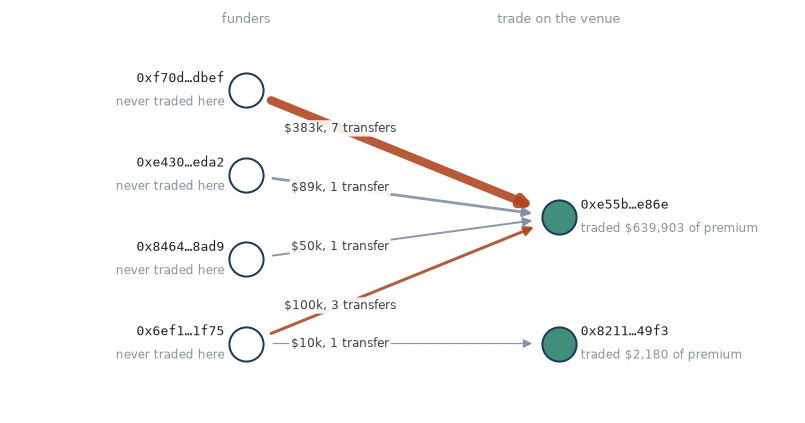

In [45]:
if LINKS:
    ch_e = collections.defaultdict(float); ch_n = collections.Counter()
    for f, t, m, l in top["component_edges"]:
        ch_e[(f, t)] += float(D(m)); ch_n[(f, t)] += 1
    ch_tr = {a: a in prem_t for a in top["members"]}
    ch_right = sorted([a for a in ch_tr if ch_tr[a]], key=lambda a: -prem_t[a])
    ch_rk = {a: i for i, a in enumerate(ch_right)}
    ch_left = sorted([a for a in ch_tr if not ch_tr[a]],
                     key=lambda a: (sum(ch_rk[t] for f, t in ch_e if f == a and t in ch_rk) / max(1, sum(1 for f, t in ch_e if f == a and t in ch_rk)),
                                    -sum(v for (f, t), v in ch_e.items() if f == a)))
    ch_xy = {a: (0, -(i - (len(ch_left) - 1) / 2)) for i, a in enumerate(ch_left)}
    for a in ch_right:
        ys = [ch_xy[f][1] for f, t in ch_e if t == a and f in ch_xy]
        ch_xy[a] = (1, sum(ys) / len(ys) if ys else 0)
    print(f"{len(ch_tr)} addresses, {len(top['component_edges'])} transfers, {len(ch_e)} directed pairs")
    fig, ax = plt.subplots(figsize=(8.4, 4.2))
    ch_mx = max(ch_e.values())
    for (f, t), amt in sorted(ch_e.items(), key=lambda kv: kv[1]):
        (x1, y1), (x2, y2) = ch_xy[f], ch_xy[t]
        ax.annotate("", (x2, y2), (x1, y1), arrowprops=dict(
            arrowstyle="-|>,head_length=.5,head_width=.25", lw=.6 + 4.5 * amt / ch_mx,
            color=WARN if amt >= 100000 else "#7d8fa3", shrinkA=16, shrinkB=16,
            connectionstyle="arc3,rad=.5" if x1 == x2 else "arc3,rad=0", alpha=.9))
        ax.text(x1 + .3 * (x2 - x1), y1 + .3 * (y2 - y1),
                f"{short_usd(amt)}, {ch_n[(f, t)]} transfer{'s' if ch_n[(f, t)] > 1 else ''}",
                fontsize=7, ha="center", va="center", color=TEXT,
                bbox=dict(boxstyle="round,pad=.15", fc="white", ec="none", alpha=.9))
    for a, (x0, y0) in ch_xy.items():
        ax.scatter([x0], [y0], s=420, zorder=3, color=HL if ch_tr[a] else "white", edgecolor=INK, lw=1.2)
        side, dx = ("right", -.07) if x0 == 0 else ("left", .07)
        sub = f"traded ${float(prem_t[a]):,.0f} of premium" if ch_tr[a] else "never traded here"
        ax.text(x0 + dx, y0 + .06, f"{a[:6]}…{a[-4:]}", ha=side, va="bottom", fontsize=8, family="monospace", color="#1f2328")
        ax.text(x0 + dx, y0 - .06, sub, ha=side, va="top", fontsize=7, color=MUTE)
    ch_h = max(len(ch_left), len(ch_right)) / 2
    ax.set_xlim(-.75, 1.75); ax.set_ylim(-ch_h - .3, ch_h + .3); ax.set_axis_off()
    ax.text(0, ch_h + .3, "funders", ha="center", fontsize=8, color=MUTE)
    ax.text(1, ch_h + .3, "trade on the venue", ha="center", fontsize=8, color=MUTE)
    plt.savefig(CHARTS / "funding-chain.png", bbox_inches="tight"); plt.show()

What that table states, and nothing more: addresses that never traded here
funded the venue's largest maker directly on HyperCore, and one of them also
funded a second address that does trade here, over HyperEVM. Common
funding is not common ownership. It is the strongest on-chain relation the two
ledgers can carry, and it is consistent both with one operator and with a desk
paying out to several clients.

### The wallet the TVL stands on

`0xe6b7faa2...` is the only contract among the watched addresses and the only
one whose HyperCore balance matches the DefiLlama TVL line. Its HyperCore
transfer history: total in, total out, and the largest senders.

In [46]:
CUSTODY = "0xe6b7faa216cabb2b38b392f577c9c826378b2240"
GATEWAY = "0x6b9e773128f453f5c2c60935ee2de2cbc5390a24"
RELAY   = "0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f"

cu = ledger(CUSTODY)
cu["accountValue"] = hl_post(
    {"type": "clearinghouseState", "user": CUSTODY}).get("marginSummary", {}).get("accountValue")
core_in, core_out = collections.defaultdict(D), collections.defaultdict(D)
for _, u, amt, _ in cu["in"]:
    core_in[u] += amt
for _, d, amt, _ in cu["out"]:
    core_out[d] += amt
tot_in, tot_out = sum(core_in.values()), sum(core_out.values())
print(f"HyperCore ledger events: {cu['events']}")
print(f"HyperCore in:  ${float(tot_in):,.2f} from {len(core_in)} addresses")
print(f"HyperCore out: ${float(tot_out):,.2f} to {len(core_out)} addresses")
print(f"bridge: +${float(cu['deposit']):,.2f} / -${float(cu['withdraw']):,.2f}")
print(f"accountValue now: ${float(cu['accountValue'] or 0):,.2f}")

CU = pd.DataFrame([{"sender": u, "amount": float(v),
                    "share": float(v / tot_in) * 100,
                    "trades on the venue": u in traders_lc}
                   for u, v in sorted(core_in.items(), key=lambda x: -x[1])])
display(CU.head(8).pipe(tbl, {"amount": "${:,.2f}", "share": "{:.2f}%"}))

gw = core_in.get(GATEWAY, D(0))
rest_c = {u: v for u, v in core_in.items() if u != GATEWAY}
print(f"\nthe gateway {GATEWAY} sent ${float(gw):,.2f}"
      f" = {float(gw / tot_in) * 100:.2f}% of everything the wallet received on Core")
print(f"the other {len(rest_c)} senders account for ${float(sum(rest_c.values())):,.2f}, "
      f"of which {sum(1 for u in rest_c if u in traders_lc)} trade on the venue")

CO = pd.DataFrame([{"receiver": d, "amount": float(v),
                    "share": float(v / tot_out) * 100 if tot_out else 0.0,
                    "trades on the venue": d in traders_lc}
                   for d, v in sorted(core_out.items(), key=lambda x: -x[1])])
display(CO.head(6).pipe(tbl, {"amount": "${:,.2f}", "share": "{:.2f}%"}))

HyperCore ledger events: 1082
HyperCore in:  $1,788,983.25 from 14 addresses
HyperCore out: $901,411.37 to 236 addresses
bridge: +$0.00 / -$0.00
accountValue now: $887,029.78


,sender,amount,share,trades on the venue
,0x6b9e773128f453f5c2c60935ee2de2cbc5390a24,"$1,773,781.96",99.15%,False
,0x48d625ba09ec6abd18a397bf75da67add9197195,"$7,027.72",0.39%,True
,0x74ec5528a0e8052fda7cf229280f9fb66cb394cd,"$5,000.00",0.28%,True
,0x3b7e9f58c807befcbc8c57ef5037d33ec6262f2a,"$2,000.00",0.11%,True
,0xb81679d357d86a1cc50880602040000aad871262,$800.00,0.04%,False
,0x17c2a33ff7177699a2bbd88020f6bff9e1c34f43,$100.00,0.01%,True
,0x43a1cc8910f57a6a6a111950b64eab6b751a9bc0,$100.00,0.01%,False
,0x96dfce1998727db5f18bfc832f9aa1cec634a6d4,$100.00,0.01%,True



the gateway 0x6b9e773128f453f5c2c60935ee2de2cbc5390a24 sent $1,773,781.96 = 99.15% of everything the wallet received on Core
the other 13 senders account for $15,201.29, of which 9 trade on the venue


,receiver,amount,share,trades on the venue
,0x4c5da265961217df97611e424d24155a9f99f040,"$400,010.00",44.38%,True
,0x2000000000000000000000000000000000000000,"$315,317.64",34.98%,False
,0x88c8df8de727854bff379745b22344957c7cc104,"$126,468.00",14.03%,True
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,"$7,989.04",0.89%,True
,0x23cb5f48fa3f4502232f3442637f90e8e3355701,"$6,029.00",0.67%,True
,0xc207ceb0709e1d2b6ff32e17989d4a4d87c91f37,"$5,000.00",0.55%,False


The gateway is the address every CCTP deposit crosses on its way from HyperEVM
to HyperCore. Money arriving through it carries no sender: the Core ledger
records the gateway, not whoever paid into it. The HyperEVM side of the same
wallet is where those names are. It is read next: the same wallet, the
other ledger.

**Read from the chain, not from an explorer.** `eth_getLogs` against a public
archive node returns every `Transfer(address,address,uint256)` log carrying the
wallet in the `from` or the `to` position. No API key is involved and no index
is trusted: the logs are the chain's own record. The scan starts at the first
block at which the wallet has code, found by binary search over `eth_getCode`:
nothing can reach a contract before it exists. It ends at the block holding the
cut, so the totals belong to the same instant as the tape. The node caps a
log query at 100,000 blocks, so the range is walked in windows of that size.
The raw logs are written to `snapshots/<run>/evm-transfers.json`.

In [47]:
CUSTODY_BLOCK = first_code_block(CUSTODY, CUT_BLOCK)
XFER, xf_meta = transfers([CUSTODY], CUSTODY_BLOCK, CUT_BLOCK, note="custody")
TOKENS = token_meta({r["token"] for r in XFER})
(SNAP / "evm-transfers.json").write_text(
    json.dumps({"meta": xf_meta, "tokens": TOKENS, "records": XFER}, indent=1))
print(f"the wallet first has code at block {CUSTODY_BLOCK:,}; scanned to "
      f"{xf_meta['to_block']:,}, the block holding the cut, "
      f"in {xf_meta['windows']} log queries")
print(f"{len(XFER):,} ERC-20 transfers, tokens: "
      + ", ".join(f"{m['symbol'] or t[:10]} ({m['decimals']} dp)"
                  for t, m in sorted(TOKENS.items())))

evm_in, evm_out = collections.defaultdict(D), collections.defaultdict(D)
for r in XFER:
    v = D(r["raw"]) / D(10 ** TOKENS[r["token"]]["decimals"])
    f_, t_ = r["from"], r["to"]
    if t_ == CUSTODY and f_ != CUSTODY:
        evm_in[f_] += v
    elif f_ == CUSTODY and t_ != CUSTODY:
        evm_out[t_] += v
tot_ein, tot_eout = sum(evm_in.values()), sum(evm_out.values())
print(f"\nHyperEVM in:  ${float(tot_ein):,.2f} from {len(evm_in)} addresses")
print(f"HyperEVM out: ${float(tot_eout):,.2f} to {len(evm_out)} addresses")
EI = pd.DataFrame([{"sender": u, "amount": float(v),
                    "share": float(v / tot_ein) * 100,
                    "trades on the venue": u in traders_lc}
                   for u, v in sorted(evm_in.items(), key=lambda x: -x[1])[:6]])
display(EI.pipe(tbl, {"amount": "${:,.2f}", "share": "{:.2f}%"}))
to_gw = evm_out.get(GATEWAY, D(0))
print(f"of what left on HyperEVM, ${float(to_gw):,.2f} = "
      f"{float(to_gw / tot_eout) * 100:.2f}% went to the gateway {GATEWAY},")
print("which is the same money the Core ledger then records arriving from the gateway.")

  custody: 208 windows, 1,970 logs


the wallet first has code at block 36,349,599; scanned to 46,717,417, the block holding the cut, in 208 log queries
1,970 ERC-20 transfers, tokens: USDC (6 dp)

HyperEVM in:  $1,949,352.50 from 439 addresses
HyperEVM out: $1,949,310.41 to 206 addresses


,sender,amount,share,trades on the venue
,0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f,"$1,409,979.98",72.33%,False
,0x6b9e773128f453f5c2c60935ee2de2cbc5390a24,"$315,317.64",16.18%,False
,0x88c8df8de727854bff379745b22344957c7cc104,"$89,662.51",4.60%,True
,0xb8537bf12d70db743e3c0ae93f3e68d4f35f9164,"$49,561.73",2.54%,True
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,"$10,025.00",0.51%,True
,0x02ac1e13708ad563fc04f0bbbdc5b6f2bb468330,"$9,529.01",0.49%,True


of what left on HyperEVM, $1,773,781.96 = 91.00% went to the gateway 0x6b9e773128f453f5c2c60935ee2de2cbc5390a24,
which is the same money the Core ledger then records arriving from the gateway.


### Whose account a deposit is credited to

The sender of a transfer is not always the account it pays for. A deposit on
HyperEVM is a call to the custody contract, `0x0e914f12(account, amount)`, and
the account is an argument: anyone can pay for anyone. The contract logs every
such call with topic `0x07ad20a3…`, carrying the credited account, the address
that called it and the token as topics and the amount as data. `eth_getLogs`
over the same blocks as the transfer scan returns all of them; they are written
to `snapshots/<run>/custody-deposits.json`.

In [48]:
DEPOSITED = "0x07ad20a3b9346d0688924ac70ee08fc04de9f80a1240899c8dc17c65b369477a"
dp_wins, dp_s = [], CUSTODY_BLOCK
while dp_s <= CUT_BLOCK:
    dp_e = min(dp_s + SPAN - 1, CUT_BLOCK)
    dp_wins.append([{"fromBlock": hex(dp_s), "toBlock": hex(dp_e),
                     "address": CUSTODY, "topics": [DEPOSITED]}])
    dp_s = dp_e + 1
EV = [{"block": int(lg["blockNumber"], 16), "tx": lg["transactionHash"],
       "logIndex": int(lg["logIndex"], 16),
       "account": "0x" + lg["topics"][1][-40:], "sender": "0x" + lg["topics"][2][-40:],
       "token": "0x" + lg["topics"][3][-40:], "raw": str(int(lg["data"][2:66], 16))}
      for res in rpc.batch("eth_getLogs", dp_wins) for lg in res]
(SNAP / "custody-deposits.json").write_text(json.dumps(EV, indent=1))
assert {e["token"] for e in EV} == {USDC}, {e["token"] for e in EV}

ev_tx, xin_tx = collections.defaultdict(D), collections.defaultdict(D)
for e in EV:
    ev_tx[e["tx"]] += D(e["raw"]) / D(10 ** 6)
for r in XFER:
    if r["to"] == CUSTODY and r["from"] != CUSTODY:
        xin_tx[r["tx"]] += D(r["raw"]) / D(10 ** TOKENS[r["token"]]["decimals"])
assert all(ev_tx[h] == xin_tx.get(h) for h in ev_tx), [h for h in ev_tx if ev_tx[h] != xin_tx.get(h)][:5]
evm_cred, evm_plain = collections.defaultdict(D), collections.defaultdict(D)
for e in EV:
    evm_cred[e["account"]] += D(e["raw"]) / D(10 ** 6)
for r in XFER:
    if r["to"] == CUSTODY and r["from"] != CUSTODY and r["tx"] not in ev_tx:
        evm_plain[r["from"]] += D(r["raw"]) / D(10 ** TOKENS[r["token"]]["decimals"])
assert sum(evm_cred.values()) + sum(evm_plain.values()) == tot_ein
print(f"deposit events: {len(EV)}, ${float(sum(evm_cred.values())):,.2f}, "
      f"credited to {len(evm_cred)} accounts")
print(f"USDC in with no deposit event: ${float(sum(evm_plain.values())):,.2f} from "
      + ", ".join(f"{a} ${float(v):,.2f}" for a, v in sorted(evm_plain.items(), key=lambda x: -x[1])))
ev_other = [e for e in EV if e["account"] != e["sender"]]
print(f"events where the caller is not the credited account: {len(ev_other)}, "
      f"${float(sum(D(e['raw']) for e in ev_other) / D(10 ** 6)):,.2f}; callers: "
      + ", ".join(f"{a} {n}" for a, n in collections.Counter(e["sender"] for e in ev_other).most_common(4)))

deposit events: 1047, $1,634,034.86, credited to 578 accounts
USDC in with no deposit event: $315,317.64 from 0x6b9e773128f453f5c2c60935ee2de2cbc5390a24 $315,317.64
events where the caller is not the credited account: 682, $1,435,532.20; callers: 0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f 349, 0xf741246d2e0add4efa7e88be0961cccf3562b502 154, 0xf5fa314f881bd93366141dead6483882490e3634 23, 0xcaab0c64ed7d9345d71ee1520cf614c7079c30d2 3


### Who is behind the bridge

Most of what reached the wallet on HyperEVM came from one caller, RelayRouterV3,
the router of the Relay bridge. The router is not the payer. Relay's public API
takes the hash of the transaction that delivered the money and returns the
request behind it: the chain it left from and the address that paid there.
`GET api.relay.link/requests/v2?hash={tx}` is called once per delivery and saved
verbatim to `snapshots/<run>/relay/`. The account the delivery was credited to
is not Relay's `recipient` field, which is where Relay's solver delivers on
HyperEVM; it is the account the custody contract logged for that transaction.

In [49]:
RELAY_API = "https://api.relay.link/requests/v2?hash={tx}"
CHAIN = {1: "Ethereum", 10: "Optimism", 56: "BNB", 137: "Polygon", 8453: "Base",
         42161: "Arbitrum", 43114: "Avalanche", 59144: "Linea", 792703809: "Solana"}
rl_txs = sorted({r["tx"] for r in XFER if r["from"] == RELAY and r["to"] == CUSTODY})
(SNAP / "relay").mkdir(exist_ok=True)
def rl_get(h):
    old = REUSE / "relay" / f"{h}.json" if REUSE else None
    if old is not None and old.exists():
        return old.read_bytes(), f"reused from {REUSE.name}", 200
    for k in range(6):
        got = get(RELAY_API.format(tx=h))
        if got[2] != "HTTP 429":
            return got
        time.sleep(10 * (k + 1))
    return got
rl_got = pmap(rl_get, rl_txs, workers=1, label="relay")
ev_by_tx = collections.defaultdict(list)
for e in EV:
    ev_by_tx[e["tx"]].append(e)
RL = []
for h, (rl_blob, rl_at, rl_status) in zip(rl_txs, rl_got):
    assert rl_blob is not None, (h, rl_status)
    write(str(SNAP / "relay" / f"{h}.json"), rl_blob)
    rq = json.loads(rl_blob)["requests"]
    assert len(rq) == 1, (h, len(rq))
    q = rq[0]; m_ = q["data"]["metadata"]; src = q["data"]["inTxs"][0]
    co = m_["currencyOut"]
    ev_ = ev_by_tx[h]
    assert len(ev_) == 1 and ev_[0]["sender"] == RELAY, (h, ev_)
    RL.append({"tx": h, "status": q["status"],
               "payer": q["user"].lower(), "recipient": q["recipient"].lower(),
               "account": ev_[0]["account"],
               "chain": CHAIN.get(src["chainId"], str(src["chainId"])),
               "origin tx": src["hash"], "sent at": int(src["timestamp"]),
               "token in": m_["currencyIn"]["currency"]["symbol"],
               "delivered": D(co["amount"]) / D(10 ** co["currency"]["decimals"])})
RLD = pd.DataFrame(RL)
rl_sum = sum(RLD.delivered)
print(f"Relay deliveries to the custody wallet: {len(RLD)}, ${float(rl_sum):,.2f}; "
      f"router on the chain: ${float(evm_in[RELAY]):,.2f}")
assert abs(rl_sum - evm_in[RELAY]) < 1
print("status:", dict(RLD.status.value_counts()), " token in:", dict(RLD["token in"].value_counts()))
assert all(D(ev_by_tx[r["tx"]][0]["raw"]) / D(10 ** 6) == r["delivered"] for r in RL)
print(f"Relay's recipient is the payer: {int((RLD.payer == RLD.recipient).sum())} of {len(RLD)}")
rl_x = RLD[RLD.payer != RLD.account]
print(f"payer is the credited account: {int((RLD.payer == RLD.account).sum())} of {len(RLD)}; "
      f"the other {len(rl_x)} carry ${float(rl_x.delivered.sum()):,.2f}")
print(f"distinct accounts: {RLD.account.nunique()}, "
      f"of which trade on the venue: {sum(a in traders_lc for a in RLD.account.unique())}")
RC = (RLD.assign(v=RLD.delivered.map(float)).groupby("chain")
      .agg(requests=("tx", "size"), delivered=("v", "sum")).sort_values("delivered", ascending=False))
display(RC.pipe(tbl, {"delivered": "${:,.2f}"}))
display(RLD.sort_values("delivered", ascending=False).head(6)
        [["account", "chain", "delivered", "origin tx"]]
        .assign(delivered=lambda x: x.delivered.map(float))
        .assign(**{"trades on the venue": lambda x: x.account.isin(traders_lc)})
        .pipe(tbl, {"delivered": "${:,.2f}"}))

  relay: 100/349
  relay: 200/349
  relay: 300/349
  relay: 349/349
Relay deliveries to the custody wallet: 349, $1,409,979.98; router on the chain: $1,409,979.98
status: {'success': np.int64(349)}  token in: {'USDC': np.int64(349)}
Relay's recipient is the payer: 349 of 349
payer is the credited account: 299 of 349; the other 50 carry $1,212,146.50
distinct accounts: 168, of which trade on the venue: 124


,requests,delivered
chain,,
Ethereum,84,"$839,687.51"
Arbitrum,200,"$554,192.13"
Base,47,"$14,570.93"
Polygon,11,"$1,236.37"
Avalanche,4,$154.68
Optimism,3,$138.34


,account,chain,delivered,origin tx,trades on the venue
,0x4c5da265961217df97611e424d24155a9f99f040,Ethereum,"$410,000.00",0xa0ab2b7c1b51363f3a1633b711854a29d4ecd2a21194...,True
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,Arbitrum,"$400,000.00",0x88c17bdff18272c6c3f66f7b402f8be7739d070dbf25...,True
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,Ethereum,"$50,000.00",0x35902fc38bc40fd82bddc72dc4933c432c388d058e9e...,True
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,Ethereum,"$40,000.00",0x79171fe13ec03632729a8b2bf0e044ff63c6322487a7...,True
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,Arbitrum,"$40,000.00",0x7316c07c178bdd2b70c49b6162140d5b5559991dacb5...,True
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,Ethereum,"$35,000.00",0x6d89df7e97ddd8c9f524f7da550ede14414216a0dfd0...,True


### Who paid in, and who was credited

The cells above hold every address that ever paid the custody wallet, on
either layer, with each HyperEVM deposit counted under the account the custody
contract credited, not under whoever paid for it.
This one holds every address the venue shows money for.
`GET /portfolio?wallet={addr}` is called once for each address on the tape. The `margin_summary.equity` it returns is what the venue
says that address is worth.

The two lists are then joined. An address that trades here, is credited with
equity, and has never sent the custody wallet a dollar on either chain did not
put that money in.

In [50]:
tape_addrs = sorted({a.lower() for a in set(df.maker) | set(df.taker)})
(SNAP / "portfolios-all").mkdir(exist_ok=True)
pf_rows, pf_failed = [], []
pf_got = pmap(lambda a: get(PORTFOLIO.format(wallet=a)), tape_addrs,
              label="portfolios")
for a, (pf_blob, pf_at, pf_status) in zip(tape_addrs, pf_got):
    if pf_blob is None:
        pf_failed.append((a, str(pf_status)))
        continue
    write(str(SNAP / "portfolios-all" / f"{a}.json"), pf_blob)
    pf_body = json.loads(pf_blob).get("data") or {}
    pf_pos = pf_body.get("positions") or []
    pf_rows.append({"address": a,
                    "equity": D(str((pf_body.get("margin_summary") or {}).get("equity") or 0)),
                    "positions": len(pf_pos),
                    "margin posted": sum(D(str(p.get("margin_posted") or 0)) for p in pf_pos)})
PFS = pd.DataFrame(pf_rows)
cred_total = PFS.equity.sum()
marg_total = PFS["margin posted"].sum()
print(f"portfolios fetched: {len(PFS)} of {len(tape_addrs)}; failed: {len(pf_failed)}")
assert not pf_failed, pf_failed[:5]
print(f"equity the venue credits across them: ${float(cred_total):,.2f}")
print(f"margin posted across {int(PFS.positions.sum())} open positions: ${float(marg_total):,.2f}")
print(f"margin posted / equity credited: {float(marg_total / cred_total):.1f}x")

  portfolios: 100/509


  portfolios: 200/509


  portfolios: 300/509


  portfolios: 400/509


  portfolios: 500/509


  portfolios: 509/509
portfolios fetched: 509 of 509; failed: 0
equity the venue credits across them: $875,095.48
margin posted across 414 open positions: $22,242,214.37
margin posted / equity credited: 25.4x


tape addresses that ever paid the custody wallet: 509 of 509
what they paid, both layers together: $1,614,994.28
tape addresses that never paid it anything: 0
equity credited to those: $0.00 = 0.00% of all equity the venue credits


,address,credited by the venue,paid into custody,open positions
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,"$586,302.63","$730,105.00",187
,0xccbbe10767414d6b8cf36dc3b563404b8a7f6600,"$69,824.65","$40,171.26",2
,0x4c5da265961217df97611e424d24155a9f99f040,"$38,972.03","$439,000.00",15
,0xa80e8e73b8d8fd6fe02c89fa6dda7793ac0aee81,"$38,451.61","$40,406.45",15
,0x74ec5528a0e8052fda7cf229280f9fb66cb394cd,"$29,079.95","$35,000.00",19
,0x758073697847d9fb661a84fd5cb51e2094e404ef,"$28,645.35","$21,649.33",29
,0xf38e807ea2b08a8eaccd05e8358f93445c071ab7,"$17,145.28","$18,661.42",8
,0x0c6657303fb609bc39174d5b198e4a7a1280d885,"$10,309.67","$12,200.00",13
,0x00a90b9130aea3a8f019f939be409eaba03088be,"$9,620.44","$9,994.00",4
,0x86f2800685ab540eb448df39d26f6acd79d780e1,"$9,566.77","$8,200.00",6


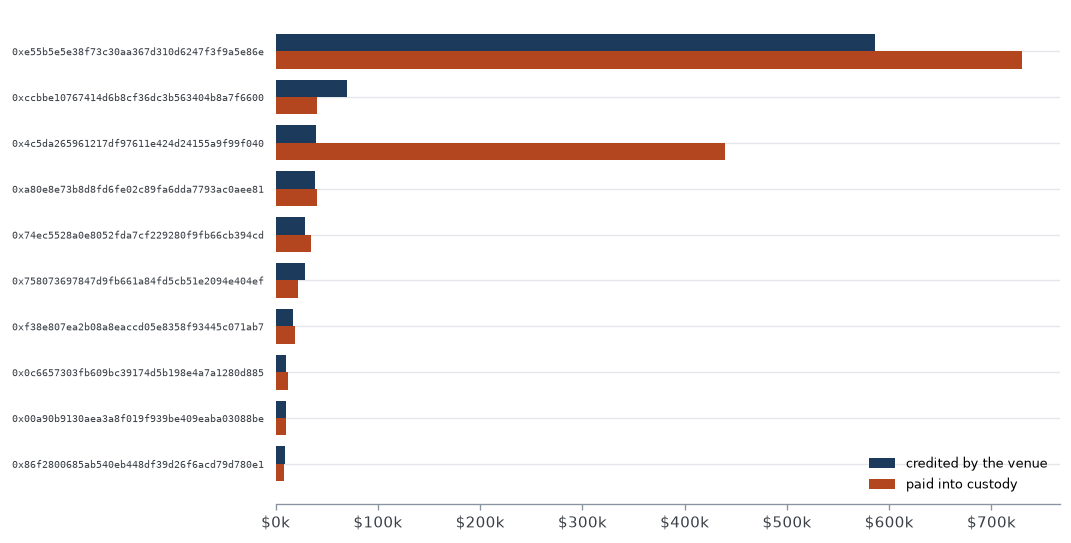

of the ten largest balances the venue credits, 0 paid it nothing
those 0 are credited $0.00


In [51]:
DEP = collections.defaultdict(D)
for u, v in core_in.items():
    DEP[u] += v
for u, v in evm_cred.items():
    DEP[u] += v
for u, v in evm_plain.items():
    DEP[u] += v
for infra in (GATEWAY, RELAY, CUSTODY):
    DEP.pop(infra, None)

dep_paid = {a: DEP[a] for a in tape_addrs if DEP.get(a, D(0)) > 0}
dep_never = [a for a in tape_addrs if a not in dep_paid]
eqv = dict(zip(PFS.address, PFS.equity))
cred_never = sum(eqv.get(a, D(0)) for a in dep_never)
print(f"tape addresses that ever paid the custody wallet: {len(dep_paid)} of {len(tape_addrs)}")
print(f"what they paid, both layers together: ${float(sum(dep_paid.values())):,.2f}")
print(f"tape addresses that never paid it anything: {len(dep_never)}")
print(f"equity credited to those: ${float(cred_never):,.2f} "
      f"= {float(cred_never / cred_total) * 100:.2f}% of all equity the venue credits")

DV = pd.DataFrame([{"address": a, "credited by the venue": float(eqv[a]),
                    "paid into custody": float(DEP.get(a, D(0))),
                    "open positions": int(PFS.set_index("address").positions.get(a, 0))}
                   for a in sorted(eqv, key=lambda x: -eqv[x])[:10]])
display(DV.pipe(tbl, {"credited by the venue": "${:,.2f}",
                      "paid into custody": "${:,.2f}"}))

D10 = DV[::-1]
y = list(range(len(D10)))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh([i + .19 for i in y], D10["credited by the venue"], height=.38,
        color=INK, label="credited by the venue")
ax.barh([i - .19 for i in y], D10["paid into custody"], height=.38,
        color=WARN, label="paid into custody")
ax.set_yticks(y); ax.set_yticklabels(D10.address, fontsize=6, family="monospace")
ax.xaxis.set_major_formatter(lambda x, p: f"${x/1000:,.0f}k")
ax.legend(loc="lower right", frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(CHARTS / "top-credited.png", dpi=170, bbox_inches="tight"); plt.show()
zero = DV[DV["paid into custody"] == 0]
print(f"of the ten largest balances the venue credits, {len(zero)} paid it nothing")
print(f"those {len(zero)} are credited ${zero["credited by the venue"].sum():,.2f}")

### Paid in under one name, credited under another

Some addresses paid the custody wallet and never traded. `GET /portfolio` is
called for each of them too, and saved to `snapshots/<run>/portfolios-outside/`.
Withdrawals are the custody wallet's payments out on either layer, leaving out
its own moves between the two: on HyperCore the system address `0x2000…0000`
that carries USDC to HyperEVM, on HyperEVM the gateway that carries it back.

For each trading address, what the venue credits it is compared with what it
brought: its deposits, plus the premium it received net of what it paid, less
what it withdrew. Settlement payouts pass between traders, so across the whole
tape they cancel, and the sum of the differences is what the trading addresses
hold that none of them brought.

In [52]:
CORE_TO_EVM = "0x2000000000000000000000000000000000000000"
tape_set = set(tape_addrs)
WD = collections.defaultdict(D)
for a, v in core_out.items():
    if a != CORE_TO_EVM:
        WD[a] += v
for a, v in evm_out.items():
    if a != GATEWAY:
        WD[a] += v
outside = sorted((a for a, v in DEP.items() if v > 0 and a not in tape_set), key=lambda a: -DEP[a])
(SNAP / "portfolios-outside").mkdir(exist_ok=True)
po_got = pmap(lambda a: get(PORTFOLIO.format(wallet=a)), outside, label="portfolios outside")
eq_out = {}
for a, (po_blob, po_at, po_status) in zip(outside, po_got):
    assert po_blob is not None, (a, po_status)
    write(str(SNAP / "portfolios-outside" / f"{a}.json"), po_blob)
    po_body = json.loads(po_blob).get("data") or {}
    eq_out[a] = D(str((po_body.get("margin_summary") or {}).get("equity") or 0))

dep_all, wd_all = sum(DEP.values()), sum(WD.values())
print(f"paid in, both layers: ${float(dep_all):,.2f}   paid out: ${float(wd_all):,.2f}   "
      f"net: ${float(dep_all - wd_all):,.2f}")
print(f"the custody wallet holds (accountValue, live): ${float(D(str(cu['accountValue']))):,.2f}")
print(f"equity the venue credits: ${float(cred_total):,.2f} to tape addresses, "
      f"${float(sum(eq_out.values())):,.2f} to the rest")

o_dep = sum(DEP[a] for a in outside)
o_wd = sum(v for a, v in WD.items() if a not in tape_set)
o_eq = sum(eq_out.values())
o_moved = o_dep - o_wd - o_eq
print(f"\n{len(outside)} addresses paid in and never traded: ${float(o_dep):,.2f} in, "
      f"${float(o_wd):,.2f} out, ${float(o_eq):,.2f} still credited to them")
print(f"left their names inside the venue: ${float(o_moved):,.2f}")

prem_net = collections.defaultdict(D)
for t in df.itertuples():
    buyer, seller = (t.taker, t.maker) if t.side == "Buy" else (t.maker, t.taker)
    prem_net[buyer.lower()] -= t.premium; prem_net[seller.lower()] += t.premium
unexpl = {a: eqv.get(a, D(0)) - DEP.get(a, D(0)) - prem_net[a] + WD.get(a, D(0)) for a in tape_addrs}
un_tot = sum(unexpl.values())
print(f"held by trading addresses beyond what they brought: ${float(un_tot):,.2f}")

  portfolios outside: 76/76
paid in, both layers: $1,649,236.14   paid out: $761,622.18   net: $887,613.97
the custody wallet holds (accountValue, live): $887,029.78
equity the venue credits: $875,095.48 to tape addresses, $10,754.60 to the rest

76 addresses paid in and never traded: $34,241.87 in, $23,703.89 out, $10,754.60 still credited to them
left their names inside the venue: $-216.62
held by trading addresses beyond what they brought: $-1,980.51


### Paid for by one address, credited to another

Each HyperEVM deposit event joined with who paid for it: for a Relay delivery,
the address that paid on the origin chain; otherwise the address that called
the custody contract. Where the two differ, one address paid and the venue
credits another.

In [53]:
rl_payer = {r["tx"]: r["payer"] for r in RL}
XP = collections.defaultdict(lambda: [0, D(0), None, None])
for e in EV:
    pay = rl_payer.get(e["tx"], e["sender"]) if e["sender"] == RELAY else e["sender"]
    if pay == e["account"]:
        continue
    x = XP[(pay, e["account"])]
    x[0] += 1; x[1] += D(e["raw"]) / D(10 ** 6)
    ts_ = next((r["sent at"] for r in RL if r["tx"] == e["tx"]), None)
    if ts_ is not None:
        x[2] = min(x[2] or ts_, ts_); x[3] = max(x[3] or ts_, ts_)
xp_tot = sum(v[1] for v in XP.values())
print(f"deposits paid by one address and credited to another: {sum(v[0] for v in XP.values())}, "
      f"${float(xp_tot):,.2f}, {len(XP)} pairs")
fmt_ts = lambda s: dt.datetime.fromtimestamp(s, dt.timezone.utc).strftime("%d %b %H:%M")
XPF = pd.DataFrame([{"paid by": p_, "credited to": a_, "deposits": n, "amount": float(v),
                     "first": fmt_ts(t0) if t0 else "", "last": fmt_ts(t1) if t1 else "",
                     "payer trades": p_ in tape_set, "credited trades": a_ in tape_set}
                    for (p_, a_), (n, v, t0, t1) in sorted(XP.items(), key=lambda x: -x[1][1])])
display(XPF.head(8).pipe(tbl, {"amount": "${:,.2f}"}))
to_maker = XPF[XPF["credited to"] == MAKER]
print(f"credited to the maker by other payers: {int(to_maker.deposits.sum())} deposits, "
      f"${to_maker.amount.sum():,.2f}, from {len(to_maker)} addresses")
print(f"the maker: credited ${float(eqv.get(MAKER, D(0))):,.2f}, paid in ${float(DEP.get(MAKER, D(0))):,.2f}, "
      f"premium net ${float(prem_net[MAKER]):+,.2f}, withdrew ${float(WD.get(MAKER, D(0))):,.2f}")
print(f"held beyond what it brought: ${float(unexpl[MAKER]):,.2f}")

rl_big = RLD[(RLD.payer != RLD.account) & (RLD.delivered >= 10000)].sort_values("sent at")
print("\nRelay payments of $10,000 or more credited to an account other than the payer, and the spreads:")
ev_ = [(r["sent at"], f"{r['payer'][:10]}… -> {r['account'][:10]}…  ${float(r['delivered']):>11,.2f} from {r['chain']}")
       for _, r in rl_big.iterrows()]
sp_ = df[(df.maker.str.lower() == MAKER) & (df.taker.str.lower() == "0xccbbe10767414d6b8cf36dc3b563404b8a7f6600")
         & (df.underlying == "SP500")]
first_sp = sp_.groupby(sp_.ts.dt.date).tms.min()
ev_ += [(int(ms) // 1000, f"first SP500 trade of the day between the maker and 0xccbbe107") for ms in first_sp]
for s, txt in sorted(ev_):
    print(f"  {fmt_ts(s)}  {txt}")

mk_first = RLD[RLD.account == MAKER].sort_values("sent at").head(3)
print()
print("the maker's first deposits:")
for _, r in mk_first.iterrows():
    print(f"  {fmt_ts(r['sent at'])}  ${float(r['delivered']):>10,.2f}  paid by {r['payer']}")
t0 = df.sort_values("trade_id").head(2)
for r in t0.itertuples():
    print(f"first trades on the tape: id {r.trade_id} {r.ts:%d %b %H:%M:%S}  maker {r.maker.lower()}  taker {r.taker.lower()}")

deposits paid by one address and credited to another: 383, $1,237,698.72, 307 pairs


,paid by,credited to,deposits,amount,first,last,payer trades,credited trades
,0xe430532a915b0132d37905dea50c9c823ad0eda2,0x4c5da265961217df97611e424d24155a9f99f040,2,"$419,000.00",17 Sep 10:27,20 Sep 02:36,False,True
,0x4c5da265961217df97611e424d24155a9f99f040,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,1,"$400,000.00",20 Sep 03:56,20 Sep 03:56,True,True
,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,15,"$249,500.00",01 Jun 20:31,25 Jun 05:25,False,True
,0x9d9a7862a8ec7d5ce04e66165a2da6ca812d7356,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,4,"$80,005.00",21 Aug 19:44,21 Aug 19:53,False,True
,0x1c2060f877acc7fa81895337956dc7489dfe5013,0xccbbe10767414d6b8cf36dc3b563404b8a7f6600,5,"$40,171.26",18 Sep 18:54,23 Sep 01:21,False,True
,0x9d9a7862a8ec7d5ce04e66165a2da6ca812d7356,0x4c5da265961217df97611e424d24155a9f99f040,1,"$20,000.00",18 Sep 17:14,18 Sep 17:14,False,True
,0x3895e2402e6b6d5098cde0a66f885da491251646,0xbd29f4151e73c73565803a5f7e61fa91254ef360,1,"$8,497.57",,,False,False
,0x869c3a2f6a6c5bcd8128e9eba380440bfd1aafcc,0xf0d6999725115e3ead3d927eb3329d63afaec09b,1,"$2,514.84",,,False,True


credited to the maker by other payers: 22 deposits, $730,105.00, from 4 addresses
the maker: credited $586,302.63, paid in $730,105.00, premium net $-34,864.76, withdrew $0.00
held beyond what it brought: $-108,937.61

Relay payments of $10,000 or more credited to an account other than the payer, and the spreads:
  01 Jun 20:43  0x6ef17a2b… -> 0xe55b5e5e…  $  20,000.00 from Ethereum
  01 Jun 20:47  0x6ef17a2b… -> 0xe55b5e5e…  $  13,000.00 from Ethereum
  11 Jun 18:02  0x6ef17a2b… -> 0xe55b5e5e…  $  10,000.00 from Ethereum
  11 Jun 18:05  0x6ef17a2b… -> 0xe55b5e5e…  $  20,000.00 from Ethereum
  11 Jun 18:41  0x6ef17a2b… -> 0xe55b5e5e…  $  23,000.00 from Ethereum
  12 Jun 04:48  0x6ef17a2b… -> 0xe55b5e5e…  $  30,000.00 from Ethereum
  12 Jun 17:23  0x6ef17a2b… -> 0xe55b5e5e…  $  50,000.00 from Ethereum
  25 Jun 05:14  0x6ef17a2b… -> 0xe55b5e5e…  $  40,000.00 from Ethereum
  25 Jun 05:25  0x6ef17a2b… -> 0xe55b5e5e…  $  40,000.00 from Arbitrum
  21 Aug 19:48  0x9d9a7862… -> 0xe55b5e5e…  $ 

### Who took money out

Withdrawals per address, set against what it paid in. An address that took
out more than it paid in was paid by someone else on the venue.

In [54]:
WDF = pd.DataFrame([{"address": a, "paid in": float(DEP.get(a, D(0))), "withdrew": float(v),
                     "net out": float(v - DEP.get(a, D(0))), "credited now": float(eqv.get(a, eq_out.get(a, D(0)))),
                     "premium net": float(prem_net.get(a, D(0))), "trades on the venue": a in tape_set}
                    for a, v in WD.items()])
wd_tape = WDF[WDF["trades on the venue"]].withdrew.sum()
print(f"withdrawn: ${float(wd_all):,.2f} to {len(WD)} addresses; "
      f"${wd_tape:,.2f} of it to {int(WDF['trades on the venue'].sum())} that trade here")
money = {"paid in": "${:,.2f}", "withdrew": "${:,.2f}", "net out": "${:,.2f}",
         "credited now": "${:,.2f}", "premium net": "${:+,.2f}"}
display(WDF.sort_values("withdrew", ascending=False).head(6).pipe(tbl, money))
wd_net = WDF[WDF["net out"] > 0]
print(f"took out more than they paid in: {len(wd_net)} addresses, ${wd_net['net out'].sum():,.2f}")
display(wd_net.sort_values("net out", ascending=False).head(4).pipe(tbl, money))

withdrawn: $761,622.18 to 427 addresses; $737,918.29 of it to 384 that trade here


,address,paid in,withdrew,net out,credited now,premium net,trades on the venue
,0x4c5da265961217df97611e424d24155a9f99f040,"$439,000.00","$400,010.00","$-38,990.00","$38,972.03",$+920.23,True
,0x88c8df8de727854bff379745b22344957c7cc104,"$90,329.01","$211,348.47","$121,019.45",$0.07,"$+133,961.38",True
,0xb8537bf12d70db743e3c0ae93f3e68d4f35f9164,"$49,561.73","$47,011.73","$-2,550.00",$0.00,"$-2,550.00",True
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,"$10,325.00","$19,404.63","$9,079.63",$0.00,"$-7,509.78",True
,0xbd9c944dcfb31cd24c81ebf1c974d950f44e42b8,"$10,000.00","$9,954.04",$-45.96,$0.00,$-589.94,True
,0x23cb5f48fa3f4502232f3442637f90e8e3355701,"$1,140.46","$6,029.00","$4,888.54",$0.00,"$-1,543.64",True


took out more than they paid in: 31 addresses, $139,245.66


,address,paid in,withdrew,net out,credited now,premium net,trades on the venue
,0x88c8df8de727854bff379745b22344957c7cc104,"$90,329.01","$211,348.47","$121,019.45",$0.07,"$+133,961.38",True
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,"$10,325.00","$19,404.63","$9,079.63",$0.00,"$-7,509.78",True
,0x23cb5f48fa3f4502232f3442637f90e8e3355701,"$1,140.46","$6,029.00","$4,888.54",$0.00,"$-1,543.64",True
,0xec5e81cc0d81c286468a4fc547da5d508747eb4f,"$1,500.00","$3,580.36","$2,080.36",$0.00,$-798.56,True


### Where the trades and the settlement happen

Hypercall's documentation says an option settles at a 30-minute TWAP of the
Hyperliquid oracle price before expiry. This cell looks for any trace of that
on chain. For each expiry date of the spreads that falls before the cut it reads every HyperEVM log
from ten minutes before expiry to an hour after, and counts the logs emitted by
the venue's published contracts and by the option token addresses that
`/markets` and `/instruments` list. The same windows hold trades from the
tape, so the count covers trading as well as settlement.

In [55]:
HC_CONTRACTS = {
    "0xe6b7faa216cabb2b38b392f577c9c826378b2240": "Exchange",
    "0xeef31f6c8f2efabba61c99d9efbef4e6429024cf": "Exchange implementation",
    "0xa8e861eae5bc47bedcf4896c7c5c676f563f5f1c": "Account implementation",
    "0x1b96d6a48d1fb34dc45953697414656d2851ca93": "Account beacon",
    "0x8654912eae1554662665c13eed4f1d8a4b028adb": "Fetcher",
    "0x6d0c7a116f9561a8de692c23c4c11682738ed206": "Option token implementation",
    "0xfb320352b25dba7f139ea9bf8966891cca12dc35": "Option token beacon",
    "0x2ceeac2e032e4ccb05ff744619bfab8cc75efe1b": "Factory",
    "0xf41ff41b6f007de851acc9f43bd2f597da741e2d": "Router",
    "0x8c8efdd5f78c25215d03c8bbd5d1f6f0f1bb0598": "Option registry",
}
st_tokens = {i["option_token_address"].lower() for g in mkt for i in g.get("instruments", [])
             if i.get("option_token_address")}
st_tokens |= {i["option_token_address"].lower()
              for i in json.loads((SNAP / "instruments.json").read_text())["result"]
              if i.get("option_token_address")}
print(f"option token addresses listed by the API: {len(st_tokens)}")
st_hour = {dt.datetime.fromtimestamp(g["expiry"], dt.timezone.utc).hour
           for g in mkt if g["underlying"] == "SP500"}
assert len(st_hour) == 1, st_hour
st_hour = st_hour.pop()
st_days = sorted(d for d in {s.split("-")[1] for s in PR.bought}
                 if dt.datetime(int(d[:4]), int(d[4:6]), int(d[6:]), st_hour,
                                tzinfo=dt.timezone.utc).timestamp() + 3600 <= CUT_TS)
print(f"SP500 expiries at {st_hour:02d}:00 UTC; spread expiry dates {st_days}")
st_head = int(rpc("eth_blockNumber", []), 16)

def st_range(lo, hi):
    """Every log in [lo, hi]; a range over the node's result cap is halved."""
    try:
        return rpc("eth_getLogs", [{"fromBlock": hex(lo), "toBlock": hex(hi)}])
    except RuntimeError as e:
        if "max results" not in str(e) or lo == hi:
            raise
        mid = (lo + hi) // 2
        return st_range(lo, mid) + st_range(mid + 1, hi)

st_rows = []
for d in st_days:
    st_exp = int(dt.datetime(int(d[:4]), int(d[4:6]), int(d[6:]), st_hour,
                             tzinfo=dt.timezone.utc).timestamp())
    st_lo = block_at(st_exp - 600, rpc)
    st_hi = min(block_at(st_exp + 3600, rpc), st_head)
    st_logs = st_range(st_lo, st_hi)
    st_hc = collections.Counter((HC_CONTRACTS[lg["address"].lower()],
                                 lg["topics"][0][:10] if lg["topics"] else "-")
                                for lg in st_logs if lg["address"].lower() in HC_CONTRACTS)
    st_tk = sum(lg["address"].lower() in st_tokens for lg in st_logs)
    st_tr = df[(df.ts >= pd.Timestamp(st_exp - 600, unit="s", tz="UTC"))
               & (df.ts <= pd.Timestamp(st_exp + 3600, unit="s", tz="UTC"))]
    st_rows.append({"expiry": d, "blocks": f"{st_lo:,} to {st_hi:,}", "logs": len(st_logs),
                    "from venue contracts": sum(st_hc.values()), "from option tokens": st_tk,
                    "tape trades": len(st_tr), "their notional": f"${float(sum(st_tr.notional)):,.2f}"})
    for (name, tp), n in st_hc.most_common():
        print(f"  {d}  {name:<28} topic0 {tp}  {n} logs")
ST = pd.DataFrame(st_rows)
display(ST.pipe(tbl, {}))
print(f"tape trades inside the windows: {ST['tape trades'].sum()}; "
      f"logs from the venue's contracts in the windows: {ST['from venue contracts'].sum()}, "
      f"from option tokens: {ST['from option tokens'].sum()}")

option token addresses listed by the API: 12410
SP500 expiries at 20:00 UTC; spread expiry dates ['20260921', '20260922', '20260923']


  20260921  Exchange                     topic0 0x07ad20a3  1 logs


,expiry,blocks,logs,from venue contracts,from option tokens,tape trades,their notional
,20260921,"46,526,487 to 46,530,757",80601,1,0,6,"$92,899,528.45"
,20260922,"46,614,327 to 46,618,597",73274,0,0,5,"$15,460.51"
,20260923,"46,702,167 to 46,706,437",66213,0,0,4,"$19,900.00"


tape trades inside the windows: 15; logs from the venue's contracts in the windows: 1, from option tokens: 0


### Ink Earn and the TVL series

`earn.hypercall.xyz/api/bootstrap` (chain, factory, assets, listed
instruments) and `/api/reward-campaign` (budget, claimed, active weight,
campaign window), then the DefiLlama series for `hypercall` with the chains its
methodology counts.

In [56]:
try:
    boot = json.loads((SNAP / "earn-bootstrap.json").read_text())
    camp = json.loads((SNAP / "earn-reward-campaign.json").read_text())
    print(f"Ink Earn: chain {boot['catalog']['chain_name']} ({boot['catalog']['chain_id']}), "
          f"factory {boot['catalog']['factory']}")
    print(f"assets: {len(boot['catalog']['assets'])} - "
          f"{[a['symbol'] for a in boot['catalog']['assets']]}")
    print(f"instruments listed: {len(boot['summaries'])}")
    print(f"reward campaign: budget {int(camp['rewardBudget'])/1e18:.3f} token, "
          f"claimed {int(camp['totalClaimed'])/1e18:.6f}, "
          f"active weight {camp['totalActiveWeight']}")
    print(f"window: {dt.datetime.fromtimestamp(camp['campaignStart'], dt.timezone.utc)} .. "
          f"{dt.datetime.fromtimestamp(camp['campaignEnd'], dt.timezone.utc)}")
except Exception as e:
    print("Earn unavailable:", e)

llama = json.loads((SNAP / "defillama-hypercall.json").read_text())
tvl = pd.DataFrame(llama["tvl"])
tvl["date"] = pd.to_datetime(tvl.date, unit="s", utc=True)
print(f"\nDefiLlama: chains {llama['chains']}, module {llama['module']}")
print(f"the methodology counts only: {list(llama.get('chainTvls', {}))}")
display(tvl.tail(6).assign(date=tvl.date.dt.strftime("%Y-%m-%d")).pipe(tbl))

Ink Earn: chain Ink Mainnet (57073), factory 0x8db61A1f0989f16478d3b1f43a3Da3561E87DFff
assets: 3 - ['NVDAX', 'AAPLX', 'WSPYX']
instruments listed: 274
reward campaign: budget 0.400 token, claimed 0.044124, active weight 28679234
window: 2026-09-04 13:45:00+00:00 .. 2026-10-30 20:00:00+00:00

DefiLlama: chains ['Hyperliquid L1'], module hypercall/index.js
the methodology counts only: ['Hyperliquid L1']


,date,totalLiquidityUSD
,2026-09-20,451470
,2026-09-21,853388
,2026-09-22,868737
,2026-09-23,869231
,2026-09-24,887438
,2026-09-24,886902


DefiLlama reads the custody account on HyperCore only. The account also holds
USDC on its HyperEVM side, so the next cell rebuilds its balance on both layers
from its own records, to the cut: the HyperCore ledger above and the HyperEVM
`Transfer` logs above. A `spotTransfer` to `0x2000...0000` is the account
moving USDC from its HyperCore side to its HyperEVM side; a transfer from
`GATEWAY` on HyperEVM is the move back.

block times: 598 reused, 0 fetched
HyperCore side at the cut, rebuilt: $887,571.88   (accountValue, read live after the cut: $887,029.78)
HyperEVM side at the cut, rebuilt:  $42.09
HyperCore -> HyperEVM: 2026-08-03 23:47 UTC, $264,525.15
HyperEVM -> HyperCore: 2026-09-17 05:47 UTC, $341,285.66
DefiLlama under $10,000 on 45 days, 2026-08-04 to 2026-09-17; both layers over the same days: $219,314.04 to $340,436.29


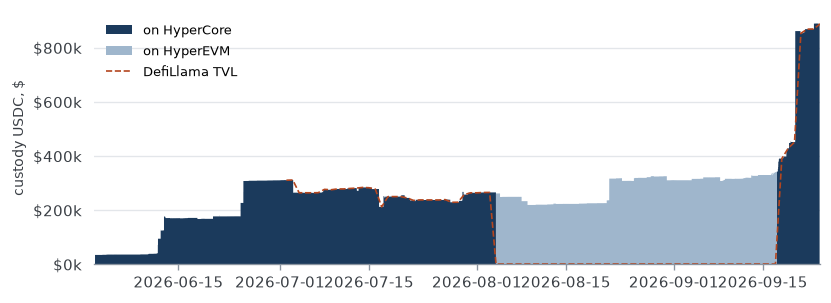

In [57]:
def signed_core(e):
    """What one HyperCore ledger event did to the custody account's USDC."""
    x = e["delta"]; t = x.get("type")
    amt = float(x.get("usdc") or x.get("usdcValue") or x.get("amount") or 0)
    u = (x.get("user") or "").lower(); d = (x.get("destination") or "").lower()
    if t == "deposit":
        return amt
    if t == "withdraw":
        return -amt
    if d == CUSTODY and u != CUSTODY:
        return amt
    if u == CUSTODY and d != CUSTODY:
        return -amt
    return 0.0

CORE_EV = sorted(_ledger_events(CUSTODY), key=lambda e: e["time"])
core_s = pd.Series([signed_core(e) for e in CORE_EV],
                   index=pd.to_datetime([e["time"] for e in CORE_EV], unit="ms", utc=True))
core_s = core_s.groupby(level=0).sum().cumsum()

cv_usdc = [t for t, m in TOKENS.items() if m["symbol"] == "USDC"][0]
cv_net = collections.defaultdict(float)
for r in XFER:
    if r["token"] != cv_usdc:
        continue
    a = int(r["raw"]) / 1e6
    cv_net[r["block"]] += a if r["to"] == CUSTODY else -a if r["from"] == CUSTODY else 0
cv_blocks = sorted(b for b, v in cv_net.items() if abs(v) >= 0.005)
bt_old = REUSE / "block-times.json" if REUSE else None
btime = ({int(k): v for k, v in json.loads(bt_old.read_text()).items()}
         if bt_old is not None and bt_old.exists() else {})
bt_need = [b for b in cv_blocks if b not in btime]
btime.update(zip(bt_need, pmap(lambda b: int(node_rpc("eth_getBlockByNumber",
                                                      [hex(b), False])["timestamp"], 16),
                               bt_need, workers=2)))
(SNAP / "block-times.json").write_text(json.dumps({str(b): btime[b] for b in cv_blocks}))
if REUSE:
    print(f"block times: {len(cv_blocks) - len(bt_need)} reused, {len(bt_need)} fetched")
evm_s = pd.Series([cv_net[b] for b in cv_blocks],
                  index=pd.to_datetime([btime[b] for b in cv_blocks], unit="s", utc=True))
evm_s = evm_s.groupby(level=0).sum().cumsum()

cv_grid = core_s.index.union(evm_s.index)
BOTH = pd.DataFrame({"HyperCore": core_s.reindex(cv_grid).ffill().fillna(0),
                     "HyperEVM": evm_s.reindex(cv_grid).ffill().fillna(0)})
BOTH["both"] = BOTH.sum(axis=1)

print(f"HyperCore side at the cut, rebuilt: ${BOTH.HyperCore.iloc[-1]:,.2f}"
      f"   (accountValue, read live after the cut: ${float(cu['accountValue'] or 0):,.2f})")
print(f"HyperEVM side at the cut, rebuilt:  ${BOTH.HyperEVM.iloc[-1]:,.2f}")
for e in CORE_EV:
    x = e["delta"]
    if (x.get("type") == "spotTransfer" and (x.get("user") or "").lower() == CUSTODY
            and float(x.get("usdcValue") or x.get("amount") or 0) >= 100_000):
        print(f"HyperCore -> HyperEVM: {pd.to_datetime(e['time'], unit='ms'):%Y-%m-%d %H:%M} UTC, "
              f"${float(x.get('usdcValue') or x.get('amount')):,.2f}")
for b in cv_blocks:
    if cv_net[b] <= -100_000:
        print(f"HyperEVM -> HyperCore: {pd.to_datetime(btime[b], unit='s'):%Y-%m-%d %H:%M} UTC, "
              f"${-cv_net[b]:,.2f}")
cv_ll = tvl[tvl.date >= "2026-07-01"]
cv_zero = cv_ll[cv_ll.totalLiquidityUSD < 10_000]
if len(cv_zero):
    lo_both = BOTH.loc[cv_zero.date.min():cv_zero.date.max(), "both"]
    print(f"DefiLlama under $10,000 on {len(cv_zero)} days, {cv_zero.date.min():%Y-%m-%d} to "
          f"{cv_zero.date.max():%Y-%m-%d}; both layers over the same days: "
          f"${lo_both.min():,.2f} to ${lo_both.max():,.2f}")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.stackplot(BOTH.index, BOTH.HyperCore, BOTH.HyperEVM, step="post",
             colors=[INK, "#9fb6cc"], labels=["on HyperCore", "on HyperEVM"])
ax.plot(tvl.date, tvl.totalLiquidityUSD, lw=1.0, color=WARN, ls="--",
        label="DefiLlama TVL")
ax.yaxis.set_major_formatter(lambda x, p: f"${x/1e3:.0f}k")
ax.set_xlim(BOTH.index.min(), BOTH.index.max())
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.set_ylabel("custody USDC, $")
plt.tight_layout(); plt.savefig(CHARTS / "tvl.png", dpi=170, bbox_inches="tight"); plt.show()

## 10. Who

### Who bought and who sold

`taker_side == "Buy"` moves contracts from the maker to the taker, so the taker
pays the premium and the maker writes the option. `"Sell"` reverses both. From
that one rule every trade has a named buyer and a named seller, and every
address has four totals: contracts bought, contracts sold, premium paid and
premium received.

Premium is zero-sum across the tape. Every dollar paid by one address is
received by another. The sum of the net column is therefore a check on the
arithmetic, not a result. What carries information is the distribution: a venue
with real two-sided flow has many addresses on each side of it, and its writers
are the net receivers.

In [58]:
buy_ct = collections.defaultdict(D); sell_ct = collections.defaultdict(D)
paid   = collections.defaultdict(D); recvd   = collections.defaultdict(D)
buy_tr = collections.Counter();      sell_tr = collections.Counter()
for r in df.itertuples():
    m, k = r.maker.lower(), r.taker.lower()
    buyer, seller = (k, m) if str(r.side).lower().startswith("b") else (m, k)
    buy_ct[buyer]  += r.size;    sell_ct[seller] += r.size
    paid[buyer]    += r.premium; recvd[seller]   += r.premium
    buy_tr[buyer]  += 1;         sell_tr[seller] += 1

everyone = sorted(set(buy_ct) | set(sell_ct))
SIDES = pd.DataFrame([{
    "address": a[:12],
    "bought": float(buy_ct[a]), "sold": float(sell_ct[a]),
    "paid": float(paid[a]), "received": float(recvd[a]),
    "net premium": float(recvd[a] - paid[a]),
    "buy trades": buy_tr[a], "sell trades": sell_tr[a],
    "sell side share": (sell_tr[a] / (buy_tr[a] + sell_tr[a])
                        if (buy_tr[a] + sell_tr[a]) else 0.0),
} for a in everyone])
SIDES["traded premium"] = SIDES["paid"] + SIDES["received"]

net_all = sum(recvd.values()) - sum(paid.values())
print(f"addresses on the tape: {len(SIDES)}")
print(f"premium paid ${float(sum(paid.values())):,.2f}, "
      f"received ${float(sum(recvd.values())):,.2f}, net ${float(net_all):,.2f}")
assert abs(net_all) < D("0.01"), net_all
print(f"net receivers of premium: {int((SIDES['net premium'] > 0).sum())}, "
      f"net payers: {int((SIDES['net premium'] < 0).sum())}")
print(f"addresses that only ever bought: {int((SIDES['sell trades'] == 0).sum())}, "
      f"that only ever sold: {int((SIDES['buy trades'] == 0).sum())}")

addresses on the tape: 509
premium paid $853,321.60, received $853,321.60, net $0.00
net receivers of premium: 42, net payers: 467
addresses that only ever bought: 68, that only ever sold: 12


The twelve addresses that trade the most premium, by side. `net premium` is
what the address ended up with: positive means it collected more premium than
it paid, which is what writing options does. The bars below are the ten busiest
of them, each drawn at its net premium.

,address,bought,sold,paid,received,net premium,buy trades,sell trades,sell side share
,0xe55b5e5e38,"66,687.5","92,869.8","$337,384","$302,519","$-34,865",4602,6586,59%
,0x88c8df8de7,"19,481.8","40,545.9","$161,797","$295,758","$133,961",2518,2877,53%
,0x0c6657303f,"2,990.4","1,485.5","$94,019","$90,474","$-3,545",764,690,47%
,0x00a90b9130,"1,229.3","1,231.3","$89,663","$86,395","$-3,268",683,686,50%
,0xccbbe10767,"30,107.8","25,161.1","$64,796","$14,627","$-50,169",112,6,5%
,0xcd4b4e9189,"5,961.5","5,861.6","$14,223","$14,492",$269,821,844,51%
,0x74ec5528a0,"4,045.2","1,133.6","$9,635","$2,730","$-6,906",234,240,51%
,0x9b21bb72db,"3,461.0",132.5,"$9,223","$1,713","$-7,510",106,25,19%
,0x02ac1e1370,"6,268.9",12.0,"$10,430",$20,"$-10,410",198,1,1%
,0xa042f85c30,"2,316.5",364.3,"$4,015","$2,275","$-1,741",316,117,27%


the single largest net receiver of premium: 0x88c8df8de7 at $133,961.38
it is 88.2% of all premium received net, across 42 net receivers


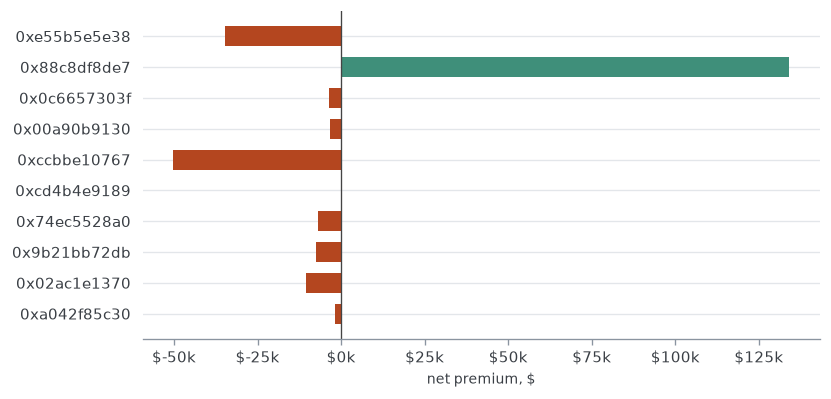

In [59]:
FMT = {"bought": "{:,.1f}", "sold": "{:,.1f}", "paid": "${:,.0f}",
       "received": "${:,.0f}", "net premium": "${:,.0f}",
       "sell side share": "{:.0%}", "traded premium": "${:,.0f}"}
TOP = SIDES.sort_values("traded premium", ascending=False).head(12)
display(TOP.drop(columns=["traded premium"]).pipe(tbl, FMT, index=False))

pos_net = SIDES[SIDES["net premium"] > 0].sort_values("net premium", ascending=False)
print(f"the single largest net receiver of premium: {pos_net.iloc[0]['address']} "
      f"at ${pos_net.iloc[0]['net premium']:,.2f}")
print(f"it is {pos_net.iloc[0]['net premium'] / pos_net['net premium'].sum() * 100:.1f}% "
      f"of all premium received net, across {len(pos_net)} net receivers")

fig, ax = plt.subplots(figsize=(7, 3.4))
sel = SIDES.sort_values("traded premium", ascending=False).head(10)[::-1]
ax.barh(sel["address"], sel["net premium"],
        color=[HL if v > 0 else WARN for v in sel["net premium"]], height=.65)
ax.axvline(0, color="#444", lw=.8)
ax.xaxis.set_major_formatter(lambda x, p: f"${x/1000:,.0f}k")
ax.set_xlabel("net premium, $")
plt.tight_layout(); plt.savefig(CHARTS / "net-premium.png", dpi=170, bbox_inches="tight"); plt.show()

### Between whom it sits

Open interest is a set of longs and a set of shorts per instrument, not a list
of pairs: the book does not record who faces whom. Matching every long against
every short in its own instrument, pro rata to size, is the assumption-free way
to split it. It is what the book would look like if positions were assigned at
random, and it introduces no threshold.

Three classes, mutually exclusive. `nonce 0` is the set derived in chapter 5
from the nodes, with no input from the tape whatever: all 82 of them, not only
the ones that also appear in the linked set below. `the linked set, signed`
is that set once its never-signed members are taken out. It starts from a
list carried in: the nineteen addresses the flat instruments, the Ink Earn
listing and the funding graph arrived at, listed in full in the cell. It is
not a ranking and no top-N reproduces it. The cell then adds every address
that paid a deposit credited to a member, or was credited one a member paid,
read from the custody contract's own events. `outside` is everyone else.

Because the two sets overlap, the cell reports them separately rather than
merging them: once on the nonce test alone, which needs nothing carried in, and
once on the linked set alone. Only the first is parameter-free, and it is the one
the headline number should be taken from.

In [60]:
CARRIED = {
    "0xe55b5e5e38", "0xccbbe10767", "0x88c8df8de7", "0x0c6657303f",
    "0x00a90b9130", "0x174ae5ba81", "0xcd4b4e9189", "0x23cb5f48fa",
    "0x9b21bb72db", "0x77864ac145", "0x02ac1e1370", "0x74ec5528a0",
    "0xa042f85c30", "0x507ad591d3", "0x8211a01728", "0xe8560fe873",
    "0x8ff0b2a352", "0x0bb2b16ecb", "0x432bbe2928",
}
assert len({a[:12] for a in traders_all}) == len(traders_all), "prefix collision"
assert CARRIED <= {a[:12] for a in traders_all}, CARRIED - {a[:12] for a in traders_all}

PAY_USD = D("500")
pay_fan = collections.Counter(p_ for p_, _ in XP)
ties = [(p_, a_) for (p_, a_), v in XP.items() if v[1] >= PAY_USD and pay_fan[p_] <= HUB_DEGREE]
grown = {a for a in traders_all if a[:12] in CARRIED}
while True:
    new_ = {x for p_, a_ in ties for x in (p_, a_) if (p_ in grown) != (a_ in grown)} - grown
    if not new_:
        break
    grown |= new_
LINKED = {a[:12] for a in grown if a in set(traders_all)}
print(f"carried in: {len(CARRIED)}; added by deposits: "
      + ", ".join(sorted(a for a in grown if a[:12] not in CARRIED and a in set(traders_all))))
print(f"linked set, addresses that trade: {len(LINKED)}; "
      f"reached but never traded: {len(grown) - len(LINKED)}")

def cls(a):
    a = a.lower()
    if a in NONCE0:        return "nonce 0"
    if a[:12] in LINKED:   return "the linked set, signed"
    return "outside"

pair = collections.defaultdict(D); holder = collections.defaultdict(D)
for s in open_syms:
    L = [(a, v) for a, v in pos[s].items() if v > 0]
    S = [(a, -v) for a, v in pos[s].items() if v < 0]
    tot_s = sum(v for _, v in S)
    if tot_s <= 0:
        continue
    for a, la in L:
        holder[a] += la
        for b, sb in S:
            pair[(cls(a), cls(b))] += la * sb / tot_s

matched = sum(pair.values())
PAIRS = pd.DataFrame([{"long side": k[0], "short side": k[1],
                       "contracts": float(v), "share": float(v / matched)}
                      for k, v in sorted(pair.items(), key=lambda x: -x[1])])
display(PAIRS.pipe(tbl, {"contracts": "{:,.2f}", "share": "{:.2%}"}, index=False))
print(f"matched {float(matched):,.2f} of {float(oi_open):,.2f} contracts open at the cut")

n0_both  = sum(v for k, v in pair.items() if k[0] == "nonce 0" and k[1] == "nonce 0")
n0_any   = sum(v for k, v in pair.items() if "nonce 0" in k)
both_out = sum(v for k, v in pair.items() if k[0] == "outside" and k[1] == "outside")
both_in  = matched - both_out

in19 = lambda a: a.lower()[:12] in LINKED
p19 = collections.defaultdict(D)
for sym in open_syms:
    L = [(a, v) for a, v in pos[sym].items() if v > 0]
    S = [(a, -v) for a, v in pos[sym].items() if v < 0]
    tot_s = sum(v for _, v in S)
    if tot_s <= 0:
        continue
    for a, la in L:
        for b, sb in S:
            p19[(in19(a), in19(b))] += la * sb / tot_s
nin_both = p19[(True, True)]
nin_none = p19[(False, False)]

print(f"both sides have never signed (nonce 0)     {float(n0_both):>9,.2f}"
      f" = {float(n0_both/matched)*100:6.2f}%")
print(f"at least one side has never signed         {float(n0_any):>9,.2f}"
      f" = {float(n0_any/matched)*100:6.2f}%")
print(f"neither side is flagged by either test     {float(both_out):>9,.2f}"
      f" = {float(both_out/matched)*100:6.2f}%")
print()
print("on the linked set alone, ignoring the nonce test:")
print(f"  both sides in the linked set             {float(nin_both):>9,.2f}"
      f" = {float(nin_both/matched)*100:6.2f}%")
print(f"  neither side in the linked set           {float(nin_none):>9,.2f}"
      f" = {float(nin_none/matched)*100:6.2f}%")

carried in: 19; added by deposits: 0x3eda819ad86d39c9c12e76144f859d02adb7237e, 0x4c5da265961217df97611e424d24155a9f99f040
linked set, addresses that trade: 21; reached but never traded: 5


,long side,short side,contracts,share
,nonce 0,nonce 0,821.32,40.45%
,"the linked set, signed",nonce 0,777.50,38.29%
,nonce 0,outside,208.49,10.27%
,nonce 0,"the linked set, signed",205.48,10.12%
,outside,nonce 0,16.92,0.83%
,"the linked set, signed","the linked set, signed",0.50,0.02%
,"the linked set, signed",outside,0.13,0.01%
,outside,outside,0.09,0.00%


matched 2,030.44 of 2,030.44 contracts open at the cut
both sides have never signed (nonce 0)        821.32 =  40.45%
at least one side has never signed          2,029.71 =  99.96%
neither side is flagged by either test          0.09 =   0.00%

on the linked set alone, ignoring the nonce test:
  both sides in the linked set              1,162.70 =  57.26%
  neither side in the linked set               10.23 =   0.50%


### The linked set against the whole tape

The set above was assembled from the relations this notebook measured, not from
a threshold. Most of it is a carried-in list: its share of the tape is a
statement about the list, not a measurement of the venue. Both sides of
a trade inside the set is the strictest reading of it.

In [61]:
mk19 = df.maker.str.lower().str[:12].isin(LINKED)
tk19 = df.taker.str.lower().str[:12].isin(LINKED)
b19 = df[mk19 & tk19]
e19 = df[mk19 | tk19]
print(f"addresses in the linked set: {len(LINKED)}")
print(f"of them never signed a HyperEVM transaction: "
      f"{sum(1 for a in traders_all if a[:12] in LINKED and a in NONCE0)}")
print("")
print(f"both sides inside: {len(b19):,} of {len(df):,} trades = {len(b19)/len(df)*100:.2f}%")
print(f"  premium  ${float(b19.premium.sum()):>14,.2f} = {float(b19.premium.sum()/prem)*100:.2f}%")
print(f"  notional ${float(b19.notional.sum()):>14,.2f} = {float(b19.notional.sum()/notl)*100:.2f}%")
print(f"at least one side inside: {len(e19):,} trades = {len(e19)/len(df)*100:.2f}%")
print(f"  premium  ${float(e19.premium.sum()):>14,.2f} = {float(e19.premium.sum()/prem)*100:.2f}%")
print(f"  notional ${float(e19.notional.sum()):>14,.2f} = {float(e19.notional.sum()/notl)*100:.2f}%")

addresses in the linked set: 21
of them never signed a HyperEVM transaction: 6

both sides inside: 10,111 of 14,205 trades = 71.18%
  premium  $    769,009.06 = 90.12%
  notional $446,591,984.73 = 98.24%
at least one side inside: 14,140 trades = 99.54%
  premium  $    852,705.16 = 99.93%
  notional $454,588,580.06 = 100.00%


### Wallet by wallet

The chapters above measure the tape by instrument and by pair. This section
measures it by address: how much each one trades, on which side, against whom,
and how long what it opens stays open.

**Closed again.** For one address and one instrument, trades are walked in time
order. A trade that goes the opposite way to what the address already holds
closes the oldest of it first, first in first out. The contracts it closes, and
the contracts that opened them, are the address's volume that closed again. The
rest either built a position still open at the cut or was never closed.

**Holding time.** For every closed contract, the time between the trade that
opened it and the trade that closed it. The median is weighted by contracts.

**Shares.** Every trade has two sides, so an address's share of the tape's
premium counts the trades it is on. Shares across addresses sum to 200%.
`credited` is `margin_summary.equity` from the venue, `paid in` is what the
address sent the custody wallet on either layer, both from chapter 9.

In [62]:
lots = collections.defaultdict(collections.deque)
w_ct = collections.defaultdict(D); w_pr = collections.defaultdict(D)
w_nt = collections.defaultdict(D); w_tr = collections.Counter()
w_mk = collections.Counter();      w_days = collections.defaultdict(set)
w_cp = collections.defaultdict(lambda: collections.defaultdict(D))
w_cpn = collections.defaultdict(collections.Counter)
w_closed = collections.defaultdict(list)
for r in df.sort_values(["ts", "trade_id"]).itertuples():
    m, k = r.maker.lower(), r.taker.lower()
    buyer, seller = (k, m) if str(r.side).lower().startswith("b") else (m, k)
    for a, sign, other in ((buyer, 1, seller), (seller, -1, buyer)):
        w_ct[a] += r.size; w_pr[a] += r.premium; w_nt[a] += r.notional
        w_tr[a] += 1; w_mk[a] += (a == m); w_days[a].add(r.ts.date())
        w_cp[a][other] += r.premium; w_cpn[a][other] += 1
        book, left = lots[(a, r.symbol)], r.size
        while left > 0 and book and (book[0][0] > 0) != (sign > 0):
            held, opened = book[0]
            use = min(abs(held), left)
            w_closed[a].append((use, (r.ts - opened).total_seconds()))
            left -= use
            if abs(held) - use > 0:
                book[0] = (held - use if held > 0 else held + use, opened)
            else:
                book.popleft()
        if left > 0:
            book.append((sign * left, r.ts))

def wmedian(xs):
    xs = sorted(xs, key=lambda z: z[1])
    half, run = sum(c for c, _ in xs) / 2, D(0)
    for c, s in xs:
        run += c
        if run >= half:
            return s
    return None

def within(xs, lim):
    tot = sum((c for c, _ in xs), D(0))
    return float(sum((c for c, s in xs if s <= lim), D(0)) / tot) if tot else None

def span(s):
    if s is None or s != s: return "-"
    if s < 120: return f"{s:.0f} s"
    if s < 7200: return f"{s / 60:.1f} min"
    if s < 172800: return f"{s / 3600:.1f} h"
    return f"{s / 86400:.1f} d"

WAL = []
for a in w_ct:
    top_cp, top_pr = max(w_cp[a].items(), key=lambda kv: kv[1])
    cl = w_closed[a]
    WAL.append({
        "address": a, "trades": w_tr[a], "days": len(w_days[a]),
        "premium": float(w_pr[a]), "premium share": float(w_pr[a] / prem),
        "notional share": float(w_nt[a] / notl),
        "maker share": w_mk[a] / w_tr[a],
        "counterparties": len(w_cp[a]),
        "main counterparty": top_cp, "with it": float(top_pr / w_pr[a]),
        "closed again": float(2 * sum((c for c, _ in cl), D(0)) / w_ct[a]),
        "median hold s": wmedian(cl) if cl else None,
        "closed in 10 min": within(cl, 600), "closed in 1 day": within(cl, 86400),
        "net premium": float(recvd[a] - paid[a]),
        "credited": float(eqv.get(a, D(0))), "paid in": float(DEP.get(a, D(0))),
        "never signed": a in NONCE0, "in the linked set": a[:12] in LINKED,
    })
WAL = pd.DataFrame(WAL).sort_values("premium", ascending=False).reset_index(drop=True)

all_cl = [z for v in w_closed.values() for z in v]
all_back = 2 * sum((c for c, _ in all_cl), D(0))
print(f"addresses {len(WAL)}; contract sides traded {float(sum(w_ct.values())):,.2f}")
print(f"closed again, first in first out: {float(all_back):,.2f} contract sides"
      f" = {float(all_back / sum(w_ct.values())) * 100:.2f}% of all volume")
print(f"median holding time of a closed contract: {span(wmedian(all_cl))}")
for lab, lim in (("one minute", 60), ("ten minutes", 600), ("one hour", 3600), ("one day", 86400)):
    print(f"  closed inside {lab:>12}: {within(all_cl, lim) * 100:5.1f}% of closed contracts")
print()
for n in (1, 5, 10, 20):
    print(f"the {n:>2} busiest addresses are on trades carrying"
          f" {float(df[df.maker.str.lower().isin(WAL.address.head(n)) | df.taker.str.lower().isin(WAL.address.head(n))].premium.sum() / prem) * 100:6.2f}% of the premium")
rest = WAL.iloc[20:]
top20 = set(WAL.address.head(20))
none20 = df[~df.maker.str.lower().isin(top20) & ~df.taker.str.lower().isin(top20)]
print(f"the other {len(rest)} addresses: median {int(rest.trades.median())} trades each,"
      f" {int((rest.trades <= 5).sum())} with five or fewer")
print(f"trades with none of the twenty on either side: {len(none20):,},"
      f" ${float(none20.premium.sum()):,.2f} = {float(none20.premium.sum() / prem) * 100:.2f}% of the premium")

addresses 509; contract sides traded 353,031.76
closed again, first in first out: 103,343.33 contract sides = 29.27% of all volume
median holding time of a closed contract: 5.0 min
  closed inside   one minute:  34.3% of closed contracts
  closed inside  ten minutes:  55.2% of closed contracts
  closed inside     one hour:  60.0% of closed contracts
  closed inside      one day:  79.6% of closed contracts

the  1 busiest addresses are on trades carrying  74.99% of the premium
the  5 busiest addresses are on trades carrying  98.27% of the premium
the 10 busiest addresses are on trades carrying  99.69% of the premium
the 20 busiest addresses are on trades carrying  99.82% of the premium
the other 489 addresses: median 2 trades each, 388 with five or fewer
trades with none of the twenty on either side: 172, $1,498.28 = 0.18% of the premium


The twenty busiest addresses by premium. Addresses are printed in full so each
row can be looked up on either chain.

In [63]:
W20 = WAL.head(20).copy()
W20["median hold"] = W20["median hold s"].map(span)
W20["main counterparty"] = W20["main counterparty"].str[:12]
cols = ["address", "trades", "days", "premium", "premium share", "notional share",
        "maker share", "counterparties", "main counterparty", "with it",
        "closed again", "median hold", "closed in 10 min", "net premium",
        "credited", "paid in", "never signed"]
pct = "{:.1%}"
display(W20[cols].pipe(tbl, {"premium": "${:,.0f}", "premium share": pct,
        "notional share": pct, "maker share": "{:.0%}", "with it": pct,
        "closed again": pct, "closed in 10 min": pct, "net premium": "${:+,.0f}",
        "credited": "${:,.0f}", "paid in": "${:,.0f}"}, index=False))

for r in WAL.head(8).to_dict("records"):
    print(f"{r['address']}  {r['trades']:>6} trades over {r['days']:>3} days"
          f"  premium ${r['premium']:,.2f} = {r['premium share'] * 100:.1f}% of the tape,"
          f" notional {r['notional share'] * 100:.1f}%")
    print(f"    maker on {r['maker share'] * 100:.0f}% of its trades; {r['counterparties']} counterparties,"
          f" {r['with it'] * 100:.1f}% of its premium with {r['main counterparty']}")
    print(f"    closed again {r['closed again'] * 100:.1f}% of its volume, median hold {span(r['median hold s'])},"
          f" {(r['closed in 10 min'] or 0) * 100:.1f}% of it inside ten minutes")
    print(f"    net premium ${r['net premium']:+,.2f}; credited ${r['credited']:,.2f}, paid in ${r['paid in']:,.2f}")

,address,trades,days,premium,premium share,notional share,maker share,counterparties,main counterparty,with it,closed again,median hold,closed in 10 min,net premium,credited,paid in,never signed
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,11188,108,"$639,903",75.0%,97.4%,97%,487,0x88c8df8de7,68.1%,25.4%,14.1 min,49.0%,"$-34,865","$586,303","$730,105",True
,0x88c8df8de727854bff379745b22344957c7cc104,5395,54,"$457,555",53.6%,9.6%,3%,23,0xe55b5e5e38,95.2%,58.9%,5.8 min,52.1%,"$+133,961",$0,"$90,329",False
,0x0c6657303fb609bc39174d5b198e4a7a1280d885,1454,18,"$184,492",21.6%,1.6%,49%,6,0x00a90b9130,93.9%,49.9%,67.3 min,0.0%,"$-3,545","$10,310","$12,200",False
,0x00a90b9130aea3a8f019f939be409eaba03088be,1369,2,"$176,057",20.6%,1.4%,50%,5,0x0c6657303f,98.4%,83.7%,67.3 min,0.0%,"$-3,268","$9,620","$9,994",True
,0xccbbe10767414d6b8cf36dc3b563404b8a7f6600,118,4,"$79,423",9.3%,84.7%,92%,3,0xe55b5e5e38,100.0%,1.3%,3.9 min,100.0%,"$-50,169","$69,825","$40,171",True
,0xcd4b4e91890548b38be04fc259c7a9ceb56966b3,1665,62,"$28,715",3.4%,0.7%,0%,71,0xe55b5e5e38,48.1%,98.8%,0 s,99.0%,$+269,$640,$485,False
,0x74ec5528a0e8052fda7cf229280f9fb66cb394cd,474,28,"$12,365",1.4%,0.2%,99%,30,0x88c8df8de7,51.3%,25.8%,6.6 min,73.3%,"$-6,906","$29,080","$35,000",True
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,131,11,"$10,936",1.3%,0.3%,1%,3,0xe55b5e5e38,97.1%,0.3%,82 s,100.0%,"$-7,510",$0,"$10,325",False
,0x02ac1e13708ad563fc04f0bbbdc5b6f2bb468330,199,3,"$10,450",1.2%,0.2%,0%,1,0xe55b5e5e38,100.0%,0.4%,15.2 h,0.0%,"$-10,410",$16,"$9,529",False
,0xa042f85c309cf929106bcedd664b1399428e48e8,433,13,"$6,290",0.7%,0.2%,10%,6,0xe55b5e5e38,62.6%,27.2%,15.1 h,32.0%,"$-1,741",$583,"$1,500",True


0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e   11188 trades over 108 days  premium $639,902.60 = 75.0% of the tape, notional 97.4%
    maker on 97% of its trades; 487 counterparties, 68.1% of its premium with 0x88c8df8de727854bff379745b22344957c7cc104
    closed again 25.4% of its volume, median hold 14.1 min, 49.0% of it inside ten minutes
    net premium $-34,864.76; credited $586,302.63, paid in $730,105.00
0x88c8df8de727854bff379745b22344957c7cc104    5395 trades over  54 days  premium $457,555.07 = 53.6% of the tape, notional 9.6%
    maker on 3% of its trades; 23 counterparties, 95.2% of its premium with 0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e
    closed again 58.9% of its volume, median hold 5.8 min, 52.1% of it inside ten minutes
    net premium $+133,961.38; credited $0.07, paid in $90,329.01
0x0c6657303fb609bc39174d5b198e4a7a1280d885    1454 trades over  18 days  premium $184,492.44 = 21.6% of the tape, notional 1.6%
    maker on 49% of its trades; 6 counterparties, 93.9% of

How long what each of the busiest addresses opens stays open. Each bar is one
address's volume: the part it closed again, split by how long it was held, and
the part it did not close.

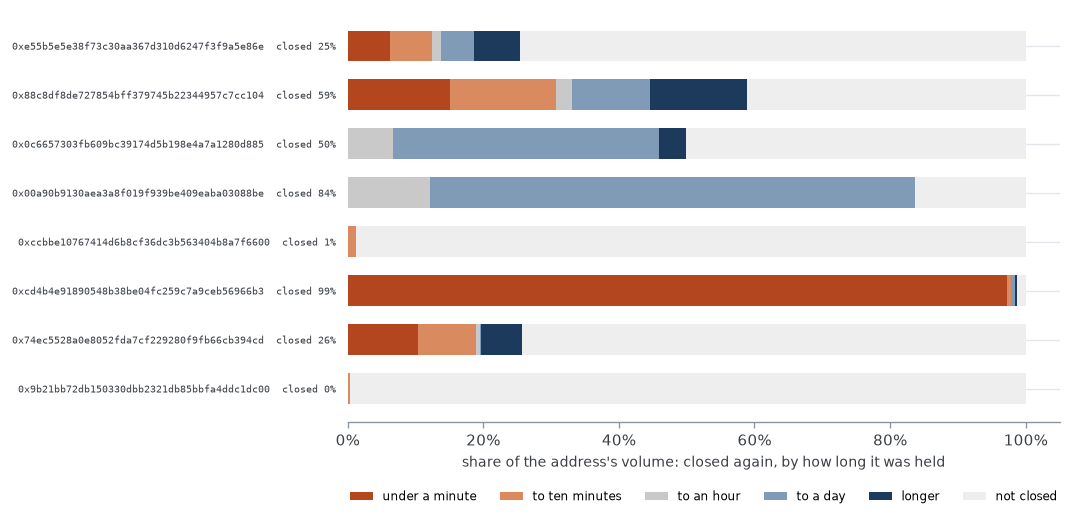

In [64]:
BANDS = [("under a minute", 60), ("to ten minutes", 600), ("to an hour", 3600),
         ("to a day", 86400), ("longer", float("inf"))]
sel = WAL.head(8)[::-1]
shares = []
for a in sel.address:
    cl = w_closed[a]; tot = sum((c for c, _ in cl), D(0)); prev = 0
    row = []
    for _, lim in BANDS:
        row.append(float(2 * sum((c for c, s in cl if prev < s <= lim or (prev == 0 and s == 0)), D(0))
                         / w_ct[a]))
        prev = lim
    row.append(1 - sum(row))
    shares.append(row)
fig, ax = plt.subplots(figsize=(9, 4.4))
left = [0.0] * len(sel)
tones = [WARN, "#d98a5f", "#c9c9c9", "#7f9bb8", INK, "#eeeeee"]
for j, (lab, _) in enumerate(BANDS + [("not closed", None)]):
    vals = [s[j] for s in shares]
    ax.barh(range(len(sel)), vals, left=left, height=.62, color=tones[j], label=lab)
    left = [l + v for l, v in zip(left, vals)]
ax.set_yticks(range(len(sel)))
ax.set_yticklabels([f"{a}  closed {c:.0%}" for a, c in zip(sel.address, sel["closed again"])],
                   fontsize=6, family="monospace")
ax.xaxis.set_major_formatter(lambda x, p: f"{x:.0%}")
ax.set_xlabel("share of the address's volume: closed again, by how long it was held")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.14), ncol=6, frameon=False, fontsize=7)
plt.tight_layout(); plt.savefig(CHARTS / "wallet-holding.png", dpi=170, bbox_inches="tight"); plt.show()

Between whom. Every pair among the busiest addresses, with the part of what
went between them that came back: for one instrument, `2 * min(out, back)`
over everything the pair traded in it, summed over instruments.

In [65]:
pp = collections.defaultdict(lambda: {"trades": 0, "premium": D(0), "notional": D(0),
                                      "ct": D(0), "first": None, "last": None})
pq = collections.defaultdict(lambda: collections.defaultdict(D))
for r in df.itertuples():
    m, k = r.maker.lower(), r.taker.lower()
    buyer, seller = (k, m) if str(r.side).lower().startswith("b") else (m, k)
    key = tuple(sorted((m, k)))
    e = pp[key]
    e["trades"] += 1; e["premium"] += r.premium; e["notional"] += r.notional; e["ct"] += r.size
    e["first"] = r.ts if e["first"] is None or r.ts < e["first"] else e["first"]
    e["last"] = r.ts if e["last"] is None or r.ts > e["last"] else e["last"]
    pq[(key, r.symbol)]["ab" if buyer == key[0] else "ba"] += r.size
back_ct = collections.defaultdict(D)
for (key, s), d in pq.items():
    back_ct[key] += 2 * min(d["ab"], d["ba"])
PAIRS = pd.DataFrame([{"a": k[0], "b": k[1], "trades": e["trades"],
                       "premium": float(e["premium"]), "premium share": float(e["premium"] / prem),
                       "notional share": float(e["notional"] / notl),
                       "came back": float(back_ct[k] / e["ct"]),
                       "first": e["first"].strftime("%Y-%m-%d"), "last": e["last"].strftime("%Y-%m-%d")}
                      for k, e in pp.items()]).sort_values("premium", ascending=False)
display(PAIRS.head(12).pipe(tbl, {"premium": "${:,.2f}", "premium share": "{:.2%}",
        "notional share": "{:.2%}", "came back": "{:.1%}"}, index=False))
print(f"pairs on the tape: {len(PAIRS):,}; the busiest one carries"
      f" {PAIRS['premium share'].iloc[0] * 100:.2f}% of the premium,"
      f" the busiest five {PAIRS['premium share'].head(5).sum() * 100:.2f}%")

,a,b,trades,premium,premium share,notional share,came back,first,last
,0x88c8df8de727854bff379745b22344957c7cc104,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,5052,"$435,515.74",51.04%,9.32%,61.1%,2026-07-02,2026-09-18
,0x00a90b9130aea3a8f019f939be409eaba03088be,0x0c6657303fb609bc39174d5b198e4a7a1280d885,1167,"$173,221.73",20.30%,1.08%,91.0%,2026-09-18,2026-09-19
,0xccbbe10767414d6b8cf36dc3b563404b8a7f6600,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,97,"$79,405.94",9.31%,84.70%,1.3%,2026-09-19,2026-09-23
,0xcd4b4e91890548b38be04fc259c7a9ceb56966b3,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,807,"$13,805.57",1.62%,0.36%,5.3%,2026-06-27,2026-09-23
,0x9b21bb72db150330dbb2321db85bbfa4ddc1dc00,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,126,"$10,615.04",1.24%,0.29%,0.1%,2026-07-09,2026-09-08
,0x02ac1e13708ad563fc04f0bbbdc5b6f2bb468330,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,199,"$10,450.32",1.22%,0.24%,0.4%,2026-06-20,2026-06-24
,0x0c6657303fb609bc39174d5b198e4a7a1280d885,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,52,"$9,679.66",1.13%,0.19%,12.5%,2026-07-29,2026-09-23
,0x74ec5528a0e8052fda7cf229280f9fb66cb394cd,0x88c8df8de727854bff379745b22344957c7cc104,65,"$6,341.54",0.74%,0.11%,22.2%,2026-07-22,2026-08-03
,0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e,0xffb57ddc67443637802015214e7267326dbfacb4,4,"$6,073.00",0.71%,0.05%,92.3%,2026-09-12,2026-09-23
,0x37c3bc0e19b034ea80d53ff0503e15eeaba9fbb1,0x88c8df8de727854bff379745b22344957c7cc104,4,"$5,516.52",0.65%,0.01%,100.0%,2026-09-03,2026-09-03


pairs on the tape: 688; the busiest one carries 51.04% of the premium, the busiest five 83.50%


## 11. What the loop buys

### The rewards programme

Rule as published at `docs.hypercall.xyz/docs/trading-rewards/`: "Your share
of eligible options premium in each role determines your daily rewards".
`PILOT_DAILY_USD = 1000` in HYPE, split 50/50 between the maker and taker
halves, window 2026-09-16 18:00 UTC to 2026-09-23 18:00 UTC.

Per address inside that window:
`reward = 500 * premium_as_maker / sum(premium_as_maker)
        + 500 * premium_as_taker / sum(premium_as_taker)`.

In [66]:
pw = windows["reward pilot to cut"]
mk = pw.groupby("maker").premium.sum()
tk = pw.groupby("taker").premium.sum()
pilot_p = pw.premium.sum()
share = pd.DataFrame({"as maker": mk, "as taker": tk}).fillna(D(0))
share["$/day"] = (share["as maker"] / mk.sum() * PILOT_DAILY_USD / 2
                  + share["as taker"] / tk.sum() * PILOT_DAILY_USD / 2).map(float)
share["maker share"] = (share["as maker"] / mk.sum()).map(lambda x: float(x)*100)
share["taker share"] = (share["as taker"] / tk.sum()).map(lambda x: float(x)*100)
share = share.sort_values("$/day", ascending=False)
print(f"pilot window: {len(pw)} trades, premium ${float(pilot_p):,.2f}, addresses {len(share)}")
top8 = share.head(8)
display(top8.assign(**{"as maker": top8["as maker"].map(float),
                       "as taker": top8["as taker"].map(float)})
        .pipe(tbl, {"as maker": "${:,.0f}", "as taker": "${:,.0f}",
                       "$/day": "${:,.0f}", "maker share": "{:.1f}%", "taker share": "{:.1f}%"}))
print(f"\nthe top three take ${share['$/day'].head(3).sum():,.0f} "
      f"of ${float(PILOT_DAILY_USD):,.0f} = {share['$/day'].head(3).sum()/float(PILOT_DAILY_USD)*100:.1f}% of the pool")

pilot window: 3013 trades, premium $269,420.46, addresses 235


,as maker,as taker,$/day,maker share,taker share
,"$88,314","$88,357",$328,32.8%,32.8%
,"$87,749","$88,308",$327,32.6%,32.8%
,"$82,299","$9,077",$170,30.5%,3.4%
,"$3,087","$54,752",$107,1.1%,20.3%
,"$3,723",$0,$7,1.4%,0.0%
,$406,"$2,934",$6,0.2%,1.1%
,"$1,730","$1,514",$6,0.6%,0.6%
,$28,"$2,344",$4,0.0%,0.9%



the top three take $824 of $1,000 = 82.4% of the pool


### What that premium was traded at

Instruments satisfying `count(trades) >= 10 and nunique(price) == 1`: their
trade count and premium, absolute and as a share of the tape. The chart puts
the two largest against the pair's trades in order: each trade's price, which
side bought, and the running premium against the running balance between them.

instruments with >=10 trades and exactly one price: 8
trades in them: 1099 = 7.7% of the tape; premium $172,061 = 20.2% of all premium


,trades,prices,premium,price
symbol,,,,
SNDK-20261002-1630-C,484,1,"$87,112",85.2370
SNDK-20261002-1640-C,484,1,"$82,715",80.9340
NVDA-20260715-185-P,38,1,$26,0.0940
SP500-20261002-7750-C,28,1,$900,34.4290
NVDA-20260921-230-C,24,1,$5,0.2162
SPCX-20260628-130-P,20,1,$28,0.0320
NVDA-20260720-165-P,11,1,"$1,054",2.7380
NVDA-20260720-205-C,10,1,$221,0.7195


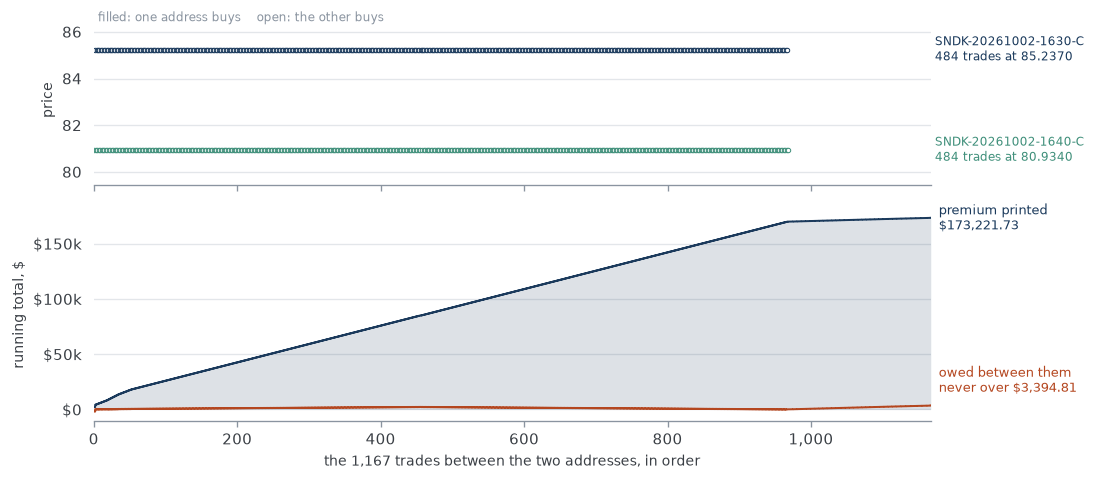

In [67]:
g = df.groupby("symbol").agg(trades=("price", "size"), prices=("price", "nunique"),
                             premium=("premium", "sum"), price=("price", "first"))
flat = g[(g.trades >= 10) & (g.prices == 1)].sort_values("trades", ascending=False)
print(f"instruments with >=10 trades and exactly one price: {len(flat)}")
print(f"trades in them: {int(flat.trades.sum())} = {flat.trades.sum()/len(df)*100:.1f}% of the tape; "
      f"premium ${float(flat.premium.sum()):,.0f} = {float(flat.premium.sum()/prem)*100:.1f}% of all premium")
display(flat.head(8).assign(premium=flat.premium.head(8).map(float),
                            price=flat.price.head(8).map(float))
        .pipe(tbl, {"premium": "${:,.0f}", "price": "{:,.4f}"}))

if len(flat):
    ch_n = pd.Series(range(1, len(lp) + 1), index=lp.index)
    ch_cum = lp.premium.map(float).cumsum()
    ch_bal = pd.Series([float(v) for v in hist], index=lp.index)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True, gridspec_kw={"height_ratios": [1, 1.25], "hspace": .12})
    ch_lo, ch_hi = [], []
    for sym, c in zip(flat.index[:2], [INK, HL]):
        s = lp[lp.symbol == sym]
        if not len(s):
            continue
        buy = s.taker.str.lower() == a_
        a1.scatter(ch_n[s.index][buy], s.price.map(float)[buy], s=7, color=c, lw=0)
        a1.scatter(ch_n[s.index][~buy], s.price.map(float)[~buy], s=7, facecolor="white", edgecolor=c, lw=.6)
        p0 = float(s.price.iloc[0]); ch_lo.append(p0); ch_hi.append(p0)
        a1.text(1.005, p0, f"{sym}\n{int(flat.loc[sym, 'trades'])} trades at {p0:.4f}",
                transform=a1.get_yaxis_transform(), va="center", fontsize=7, color=c)
    if ch_lo:
        a1.set_ylim(min(ch_lo) - 1.5, max(ch_hi) + 1.5)
    a1.set_ylabel("price")
    a1.text(.005, 1.02, "filled: one address buys    open: the other buys", transform=a1.transAxes, fontsize=7, va="top", color=MUTE)
    a2.fill_between(ch_n, 0, ch_cum, step="post", color=INK, alpha=.15, lw=0)
    a2.step(ch_n, ch_cum, where="post", color=INK, lw=1.2)
    a2.step(ch_n, ch_bal, where="post", color=WARN, lw=1.2)
    a2.text(ch_n.iloc[-1], ch_cum.iloc[-1], f"  premium printed\n  ${ch_cum.iloc[-1]:,.2f}", va="center", fontsize=7.5, color=INK)
    a2.text(ch_n.iloc[-1], ch_bal.iloc[-1] + ch_cum.iloc[-1] * .05,
            f"  owed between them\n  never over ${float(peak):,.2f}", va="bottom", fontsize=7.5, color=WARN)
    a2.yaxis.set_major_formatter(short_usd); a2.set_ylabel("running total, $")
    a2.set_xlim(0, len(lp)); a2.xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
    a2.set_xlabel(f"the {len(lp):,} trades between the two addresses, in order")
    plt.savefig(CHARTS / "flat-price.png", bbox_inches="tight"); plt.show()

### What the loop is worth

The reward pilot pays $1,000 a day, split evenly between makers and takers, by
share of premium. Premium is therefore the payout metric, and the loop above
produces it. This cell allocates the pool by the tape's own premium shares over
the pilot window. It is the rule applied to the data, not an observed payment:
no payout has been seen on chain.

pilot window 16 Sep 18:00 -> 23 Sep 18:00 UTC, pool $7,000.00
window premium $269,420.46 over 3,013 trades
premium the two loop addresses made with each other: $173,221.73 = 64.29%


,address,as maker,as taker,share of premium,implied pool $
,0x0c6657303f,"$88,313.66","$88,356.59",32.79%,"$2,295.10"
,0x00a90b9130,"$87,749.05","$88,308.30",32.67%,"$2,287.13"
,0xe55b5e5e38,"$82,298.66","$9,077.39",16.96%,"$1,187.05"
,0xccbbe10767,"$3,087.29","$54,752.34",10.73%,$751.39
,0xffb57ddc67,"$3,723.48",$0.00,0.69%,$48.37
,0x4c5da26596,$406.29,"$2,933.58",0.62%,$43.39


the two loop addresses together: $4,582.23 of $7,000.00 = 65.46% of the pool


,pilot day,trades,the two,rest of the linked set,everyone else
,16 Sep,404,$131.62,$600.54,$267.84
,17 Sep,1106,$974.91,$17.64,$7.45
,18 Sep,162,$0.00,$505.04,$494.96
,19 Sep,731,$144.24,$839.57,$16.18
,20 Sep,394,$0.00,$528.53,$471.47
,21 Sep,117,$0.00,$953.22,$46.78
,22 Sep,99,$0.00,$885.26,$114.74


day by day over 7 elapsed days, of $7,000.00 paid out:
  the two take                  $ 1,250.77 = 17.87%
  the linked set together take  $ 5,580.59 = 79.72%
  the worst single day for the two: $974.91 of $1,000.00, on 17 Sep


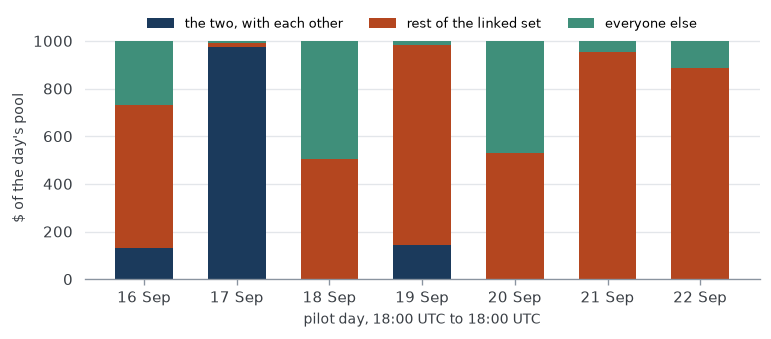

In [68]:
PILOT_S = dt.datetime(2026, 9, 16, 18, 0, tzinfo=dt.timezone.utc)
PILOT_E = dt.datetime(2026, 9, 23, 18, 0, tzinfo=dt.timezone.utc)
POOL_PER_DAY, DAYS = D("1000"), D("7")

w = df[(df.ts >= PILOT_S) & (df.ts < PILOT_E)]
mk = collections.defaultdict(D); tk = collections.defaultdict(D)
for r in w.itertuples():
    mk[r.maker.lower()] += r.premium; tk[r.taker.lower()] += r.premium
P = w.premium.sum()
pool = POOL_PER_DAY * DAYS

LOOP = sorted({a for (a, b, s, p), d in px_q.items() if min(d["ab"], d["ba"]) > 0} |
              {b for (a, b, s, p), d in px_q.items() if min(d["ab"], d["ba"]) > 0},
              key=lambda x: -(mk[x] + tk[x]))[:2]
inside = w[(w.maker.str.lower().isin(LOOP)) & (w.taker.str.lower().isin(LOOP))]
print(f"pilot window {PILOT_S:%d %b %H:%M} -> {PILOT_E:%d %b %H:%M} UTC, "
      f"pool ${float(pool):,.2f}")
print(f"window premium ${float(P):,.2f} over {len(w):,} trades")
print(f"premium the two loop addresses made with each other: "
      f"${float(inside.premium.sum()):,.2f} = {float(inside.premium.sum()/P)*100:.2f}%")

R = pd.DataFrame([{"address": a[:12],
                   "as maker": float(mk[a]), "as taker": float(tk[a]),
                   "share of premium": float((mk[a] + tk[a]) / (2 * P)),
                   "implied pool $": float(pool / 2 * (mk[a] / P) + pool / 2 * (tk[a] / P))}
                  for a in set(mk) | set(tk)])
R = R.sort_values("implied pool $", ascending=False).head(6)
display(R.pipe(tbl, {"as maker": "${:,.2f}", "as taker": "${:,.2f}",
                     "share of premium": "{:.2%}", "implied pool $": "${:,.2f}"},
               index=False))
_two = sum(pool/2*(mk[a]/P) + pool/2*(tk[a]/P) for a in LOOP)
print(f"the two loop addresses together: ${float(_two):,.2f} "
      f"of ${float(pool):,.2f} = {float(_two/pool)*100:.2f}% of the pool")

HALF = POOL_PER_DAY / 2
elapsed = max(0, -int(-(min(end, PILOT_E) - PILOT_S).total_seconds() // 86400))
days, got_pair, got_near, got_rest = [], [], [], []
for i in range(elapsed):
    d0 = PILOT_S + dt.timedelta(days=i)
    d = w[(w.ts >= d0) & (w.ts < d0 + dt.timedelta(days=1))]
    dmk = d.groupby(d.maker.str.lower()).premium.sum() if len(d) else pd.Series(dtype=object)
    dtk = d.groupby(d.taker.str.lower()).premium.sum() if len(d) else pd.Series(dtype=object)
    def cut(g, a):
        tot = g.sum() if len(g) else D(0)
        return float(HALF * g.get(a, D(0)) / tot) if tot > 0 else 0.0
    others = [a for a in set(dmk.index) | set(dtk.index)
              if a[:12] in LINKED and a not in LOOP]
    mine = sum(cut(dmk, a) + cut(dtk, a) for a in LOOP)
    near = sum(cut(dmk, a) + cut(dtk, a) for a in others)
    paid = float(POOL_PER_DAY) if len(d) else 0.0
    days.append(d0); got_pair.append(mine); got_near.append(near)
    got_rest.append(paid - mine - near)

DAILY = pd.DataFrame({"pilot day": [f"{d:%d %b}" for d in days],
                      "trades": [int(((w.ts >= d) & (w.ts < d + dt.timedelta(days=1))).sum()) for d in days],
                      "the two": got_pair, "rest of the linked set": got_near,
                      "everyone else": got_rest})
display(DAILY.pipe(tbl, {"the two": "${:,.2f}", "rest of the linked set": "${:,.2f}",
                         "everyone else": "${:,.2f}"}, index=False))
paid_tot = sum(got_pair) + sum(got_near) + sum(got_rest)
print(f"day by day over {elapsed} elapsed days, of ${paid_tot:,.2f} paid out:")
print(f"  the two take                  ${sum(got_pair):>9,.2f}"
      f" = {sum(got_pair) / max(paid_tot, 1e-9) * 100:5.2f}%")
print(f"  the linked set together take  ${sum(got_pair) + sum(got_near):>9,.2f}"
      f" = {(sum(got_pair) + sum(got_near)) / max(paid_tot, 1e-9) * 100:5.2f}%")
print(f"  the worst single day for the two: ${max(got_pair):,.2f} of "
      f"${float(POOL_PER_DAY):,.2f}, on {days[got_pair.index(max(got_pair))]:%d %b}")

fig, ax = plt.subplots(figsize=(6.5, 2.9))
x = DAILY["pilot day"]
base = [a + b for a, b in zip(got_pair, got_near)]
ax.bar(x, got_pair, color=INK, width=.62, label="the two, with each other")
ax.bar(x, got_near, bottom=got_pair, color=WARN, width=.62, label="rest of the linked set")
ax.bar(x, got_rest, bottom=base, color=HL, width=.62, label="everyone else")
ax.set_ylim(0, float(POOL_PER_DAY) * 1.02)
ax.set_ylabel("$ of the day's pool")
ax.set_xlabel("pilot day, 18:00 UTC to 18:00 UTC")
ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower center",
          bbox_to_anchor=(.5, 1.0), borderaxespad=0)
plt.tight_layout(); plt.savefig(CHARTS / "reward-pool.png", dpi=170, bbox_inches="tight"); plt.show()

## 12. Summary and claims

Everything above in one list, as computed by this run.

In [69]:
summary = {
    "cut": CUTOFF or str(end),
    "trades on the tape": len(df),
    "addresses": len(addrs),
    "premium (price x size)": usd(prem),
    "notional (strike x size)": usd(notl),
    "notional / premium": f"{float(notl/prem):,.1f}x",
    "notional over the rolling 24 hours": usd(windows["rolling 24 hours"].notional.sum()),
    "twelve trades are this much of the notional": f"{float(s10.notional.sum()/notl)*100:.1f}%",
    "and this much of the premium": f"{float(s10.premium.sum()/prem)*100:.2f}%",
    "live open interest": f"${live.oi_notional.sum():,.0f}",
    "share of it expiring on the nearest date": f"{live[live.expiry==nearest].oi_notional.sum()/live.oi_notional.sum()*100:.1f}%",
    "live instruments with one long address": f"{(live['long addresses']==1).sum()} of {len(live)}",
    "the top three of the pilot take": f"{share['$/day'].head(3).sum()/float(PILOT_DAILY_USD)*100:.1f}% of the $1,000/day pool",
    "trades on single-price instruments": f"{int(flat.trades.sum())} ({flat.trades.sum()/len(df)*100:.1f}%)",
    "weekend notional (equities and indices)": f"{float(we.notional.sum()/eq.notional.sum())*100:.1f}%",
    "trades in the US regular session": f"{len(rth)/len(eq)*100:.1f}%",
    "the two busiest address pairs are this much of the premium": f"{float(by_pair.head(2).sum()/prem)*100:.2f}%",
    "addresses with a round trip": f"{len(rt)}/{len(addrs)} ({len(rt)/len(addrs)*100:.1f}%)",
    "trades charged a non-zero fee": len(fees),
    "trades with one address on both sides": len(self_trades),
    "addresses that never signed a HyperEVM transaction": f"{len(NONCE0)} of {len(traders_all)}",
    "notional with at least one such counterparty": f"{float(AT_LEAST_ONE)*100:.2f}%",
    "notional with both sides such": f"{float(cn[2]/notl)*100:.2f}%",
    "contracts traded": f"{float(traded):,.2f}",
    "open interest the tape ever created": f"{float(oi_all):,.2f}",
    "open interest still open at the cut": f"{float(oi_open):,.2f}",
    "the venue's own open interest, same instruments": f"{float(v_tot):,.2f}",
    "venue / tape": f"{float(v_tot/t_tot):.4f}x",
    "open interest with a never-signed address on both sides": f"{float(n0_both/matched)*100:.2f}%",
    "open interest with the linked set on both sides": f"{float(nin_both/matched)*100:.2f}%",
    "open interest with neither side flagged": f"{float(both_out/matched)*100:.2f}%",
    "the largest net receiver of premium": f"{pos_net.iloc[0]['address']} ${pos_net.iloc[0]['net premium']:,.2f}",
    "net receivers of premium": f"{int((SIDES['net premium'] > 0).sum())} of {len(SIDES)}",
    "snapshot": str(SNAP.relative_to(HERE)),
}
display(pd.Series(summary).to_frame("value"))

,value
cut,2026-09-24T00:00:00Z
trades on the tape,14205
addresses,509
premium (price x size),"$853,321.60"
notional (strike x size),"$454,597,510.21"
notional / premium,532.7x
notional over the rolling 24 hours,"$199,894,185.23"
twelve trades are this much of the notional,84.4%
and this much of the premium,8.95%
live open interest,"$154,130,604"


### Every claim, and how to check it

Every number that goes into the published thread, with the endpoint it came
from. All are public; only the HyperEVM history needs a key.

In [70]:
SRC_TAPE = "GET api.hypercall.xyz/trades?limit=1000&after_trade_id={n}"
SRC_PF   = "GET api.hypercall.xyz/portfolio?wallet={addr}"
SRC_EVM  = "POST rpc.hyperliquid.xyz/evm eth_getTransactionCount|getBalance|getCode"
SRC_LOG  = ("POST rpc.purroofgroup.com eth_getLogs "
            "topic0=Transfer(address,address,uint256), address=USDC, "
            "probed addresses in topic1|topic2")
SRC_CORE = "POST api.hyperliquid.xyz/info userNonFundingLedgerUpdates|clearinghouseState"
SRC_LL   = "GET api.llama.fi/protocol/hypercall"
SRC_MKT  = "GET api.hypercall.xyz/markets"
SRC_RELAY = "GET api.relay.link/requests/v2?hash={tx}"
SRC_NONCE = "POST rpc.purroofgroup.com eth_getTransactionCount"
SRC_EXP  = ("POST rpc.purroofgroup.com eth_getLogs "
            "topic0=Transfer(address,address,uint256), custody in topic1|topic2")
SRC_DEPEV = "POST rpc.purroofgroup.com eth_getLogs address=custody topic0=0x07ad20a3…"

three = PR if len(PR) else None
CLAIMS = [
 ("notional of the whole tape (strike x size)", usd(notl), SRC_TAPE),
 ("premium of the whole tape (price x size)", usd(prem), SRC_TAPE),
 ("notional / premium", f"{float(notl/prem):,.1f}x", SRC_TAPE),
 ("notional over the rolling 24 hours", usd(windows["rolling 24 hours"].notional.sum()), SRC_TAPE),
 ("twelve trades are this much of the notional", f"{float(s10.notional.sum()/notl)*100:.1f}%", SRC_TAPE),
 ("and this much of the premium", f"{float(s10.premium.sum()/prem)*100:.2f}%", SRC_TAPE),
 (f"notional of the {len(three)} spreads" if three is not None else "notional of the spreads",
  f"${three['notional $'].sum():,.0f}" if three is not None else "-", SRC_TAPE),
 ("what was actually paid for them", f"${three['net debit $'].sum():,.2f}" if three is not None else "-", SRC_TAPE),
 ("size = debit / width of the spread", "holds" if three is not None and three["formula holds"].all() else "-", SRC_TAPE),
 ("live open interest", f"${live.oi_notional.sum():,.0f}", SRC_TAPE),
 ("share of it expiring on the nearest date", f"{live[live.expiry==nearest].oi_notional.sum()/live.oi_notional.sum()*100:.1f}%", SRC_TAPE),
 ("live instruments with one long address", f"{(live['long addresses']==1).sum()} of {len(live)}", SRC_TAPE),
 ("the top three take, out of $1,000/day", f"${share['$/day'].head(3).sum():,.0f}", SRC_TAPE),
 ("trades on single-price instruments", f"{int(flat.trades.sum())} ({flat.trades.sum()/len(df)*100:.1f}%)", SRC_TAPE),
 ("premium in them", f"{float(flat.premium.sum()/prem)*100:.1f}%", SRC_TAPE),
 ("trades charged a non-zero fee", str(len(fees)), SRC_TAPE),
 ("weekend notional (equities and indices)", f"{float(we.notional.sum()/eq.notional.sum())*100:.1f}%", SRC_TAPE),
 ("trades in the US regular session", f"{len(rth)/len(eq)*100:.1f}%", SRC_TAPE),
 ("received by the main maker in transfers", f"${float(sum(m for _,_,m,_ in tr[MAKER]['in'])):,.2f}", SRC_CORE),
 ("sent by the main maker", f"${float(sum(m for _,_,m,_ in tr[MAKER]['out'])):,.2f}", SRC_CORE),
 ("bridged in by it", f"${float(tr[MAKER]['deposit']):,.2f}", SRC_CORE),
 ("received by the custody wallet, ever", f"${float(tot_in):,.2f}", SRC_CORE),
 ("sent out of the custody wallet, ever", f"${float(sum(m for _,_,m,_ in cu['out'])):,.2f}", SRC_CORE),
 ("TVL per DefiLlama", f"${tvl.totalLiquidityUSD.iloc[-1]:,.0f}", SRC_LL),
 ("contracts that changed hands", f"{float(moved):,.0f}", SRC_TAPE),
 ("contracts that had to, to reach the same positions", f"{float(must):,.0f}", SRC_TAPE),
 ("contracts that came back", f"{float(moved-must):,.0f} ({float((moved-must)/moved)*100:.2f}%)", SRC_TAPE),
 ("contracts that came back to the address that sent them", f"{float(sq_ct):,.2f}", SRC_TAPE),
 ("premium between pairs that end square", f"${float(sq_pr):,.2f}", SRC_TAPE),
 ("premium between pairs that end square, share", f"{float(sq_pr/prem)*100:.2f}%", SRC_TAPE),
 ("contracts that came back to the address that sent them, share", f"{float(sq_ct/df['size'].sum())*100:.2f}%", SRC_TAPE),
 ("premium on the part that came back", f"{float(r_pr/prem)*100:.2f}%", SRC_TAPE),
 ("notional on the part that came back", f"{float(r_nt/notl)*100:.2f}%", SRC_TAPE),
 ("volume closed again by the address that opened it, first in first out",
  f"{float(all_back / sum(w_ct.values())) * 100:.2f}%", SRC_TAPE),
 ("median holding time of a contract closed again", span(wmedian(all_cl)), SRC_TAPE),
 ("the five busiest addresses are on trades carrying this much of the premium",
  f"{float(df[df.maker.str.lower().isin(WAL.address.head(5)) | df.taker.str.lower().isin(WAL.address.head(5))].premium.sum() / prem) * 100:.2f}%", SRC_TAPE),
 ("the busiest pair of addresses, share of premium",
  f"{PAIRS['premium share'].iloc[0] * 100:.2f}%", SRC_TAPE),
 ("instruments where every participant ends flat", f"{len(FLAT)} of {len(g_ct)}", SRC_TAPE),
 ("trades in them", f"{f_tr:,} ({f_tr/len(df)*100:.2f}%)", SRC_TAPE),
 ("premium in them", f"{float(sum(g_pr[x] for x in FLAT)/prem)*100:.2f}%", SRC_TAPE),
 ("fees charged across them", f"${float(sum(g_fe[x] for x in FLAT)):,.2f}", SRC_TAPE),
 ("of them traded by exactly two addresses", f"{len(two)} of {len(FLAT)}", SRC_TAPE),
 ("addresses that have never signed a HyperEVM transaction",
  f"{len(NONCE0)} of {len(traders_all)}", SRC_NONCE),
 ("notional with at least one never-signed counterparty",
  f"{float(AT_LEAST_ONE)*100:.2f}%", SRC_TAPE + " + " + SRC_NONCE),
 ("notional with both sides never-signed", f"{float(cn[2]/notl)*100:.2f}%",
  SRC_TAPE + " + " + SRC_NONCE),
 ("contracts that changed hands", f"{float(traded):,.2f}", SRC_TAPE),
 ("open interest the tape ever created", f"{float(oi_all):,.2f}", SRC_TAPE),
 ("open interest still open at the cut", f"{float(oi_open):,.2f}", SRC_TAPE),
 ("the venue's own open interest over the same instruments",
  f"{float(v_tot):,.2f}", SRC_MKT),
 ("venue open interest / tape open interest", f"{float(v_tot/t_tot):.4f}x",
  SRC_TAPE + " + " + SRC_MKT),
 ("instruments where the two agree exactly", f"{int((XC['abs']==0).sum())} of {len(XC)}", SRC_MKT),
 ("open interest with a never-signed address on both sides",
  f"{float(n0_both/matched)*100:.2f}%", SRC_TAPE + " + " + SRC_NONCE),
 ("open interest with the linked set on both sides",
  f"{float(nin_both/matched)*100:.2f}%", SRC_TAPE),
 ("open interest with neither side flagged",
  f"{float(both_out/matched)*100:.2f}%", SRC_TAPE + " + " + SRC_NONCE),
 (f"the net payer on all {len(PR)} spreads" if len(PR) else "the net payer on the spreads",
  ", ".join(sorted(set(PR["net payer"]))) if len(PR) else "-", SRC_TAPE),
 ("premium is zero-sum across the tape", f"net ${float(net_all):,.2f}", SRC_TAPE),
 ("the largest net receiver of premium",
  f"{pos_net.iloc[0]['address']} ${pos_net.iloc[0]['net premium']:,.2f}", SRC_TAPE),
 ("net receivers of premium", f"{int((SIDES['net premium']>0).sum())} of {len(SIDES)}", SRC_TAPE),
 ("notional over the 24 hours to the last midnight",
  usd(windows["24 hours to last midnight"].notional.sum()), SRC_TAPE),
 ("trades in that window", f"{len(windows['24 hours to last midnight']):,}", SRC_TAPE),
 ("received by the custody wallet on HyperEVM",
  f"${float(tot_ein):,.2f} from {len(evm_in)} addresses", SRC_EXP),
 ("sent by it on HyperEVM", f"${float(tot_eout):,.2f} to {len(evm_out)} addresses", SRC_EXP),
 ("share of its Core inflow arriving through the CCTP gateway",
  f"{float(gw/tot_in)*100:.2f}%", SRC_CORE),
 ("its Core inflow that is not the gateway",
  f"${float(sum(rest_c.values())):,.2f} from {len(rest_c)} addresses", SRC_CORE),
 ("tape addresses that ever paid the custody wallet, either layer",
  f"{len(dep_paid)} of {len(tape_addrs)}", SRC_CORE + " + " + SRC_EXP),
 ("what they paid", f"${float(sum(dep_paid.values())):,.2f}", SRC_CORE + " + " + SRC_EXP),
 ("tape addresses that never paid it anything", f"{len(dep_never)}", SRC_CORE + " + " + SRC_EXP),
 ("equity the venue credits across the tape", f"${float(cred_total):,.2f}", SRC_PF),
 ("of it credited to addresses that never paid",
  f"${float(cred_never):,.2f} ({float(cred_never/cred_total)*100:.2f}%)",
  SRC_PF + " + " + SRC_CORE + " + " + SRC_EXP),
 ("RelayRouterV3 deliveries into custody",
  f"{len(RL)}, ${float(RLD.delivered.sum()):,.2f}, {(RLD.payer == RLD.account).sum()} with payer = account",
  SRC_EXP + " + " + SRC_RELAY + " + " + SRC_DEPEV),
 ("deposits paid by one address, credited to another",
  f"{sum(v[0] for v in XP.values())}, ${float(xp_tot):,.2f}", SRC_DEPEV + " + " + SRC_RELAY),
 ("credited to the maker by other payers",
  f"{int(to_maker.deposits.sum())} deposits, ${to_maker.amount.sum():,.2f}, from {len(to_maker)} addresses",
  SRC_DEPEV + " + " + SRC_RELAY),
 ("of them from Ethereum / Arbitrum",
  f"${float(RLD[RLD.chain=='Ethereum'].delivered.sum()):,.2f} / ${float(RLD[RLD.chain=='Arbitrum'].delivered.sum()):,.2f}",
  SRC_RELAY),
 ("paid in, both layers, less paid out", f"${float(dep_all):,.2f} - ${float(wd_all):,.2f} = ${float(dep_all - wd_all):,.2f}",
  SRC_CORE + " + " + SRC_EXP + " + " + SRC_RELAY),
 ("addresses that paid in and never traded", f"{len(outside)}, ${float(o_dep):,.2f}",
  SRC_CORE + " + " + SRC_EXP + " + " + SRC_RELAY),
 ("of it withdrawn by them / still credited to them", f"${float(o_wd):,.2f} / ${float(o_eq):,.2f}",
  SRC_CORE + " + " + SRC_EXP + " + " + SRC_PF),
 ("left their names inside the venue", f"${float(o_moved):,.2f}", SRC_CORE + " + " + SRC_EXP + " + " + SRC_PF),
 ("held by trading addresses beyond what they brought", f"${float(un_tot):,.2f}",
  SRC_TAPE + " + " + SRC_PF + " + " + SRC_CORE + " + " + SRC_EXP),
 ("the maker, held beyond what it brought", f"${float(unexpl[MAKER]):,.2f}", SRC_TAPE + " + " + SRC_PF + " + " + SRC_CORE),
 ("withdrawn from custody", f"${float(wd_all):,.2f} to {len(WD)} addresses", SRC_CORE + " + " + SRC_EXP),
 ("took out more than they paid in", f"{len(wd_net)} addresses, ${wd_net['net out'].sum():,.2f}", SRC_CORE + " + " + SRC_EXP),
 ("largest net withdrawal", f"{wd_net.sort_values('net out').iloc[-1]['address']} ${wd_net['net out'].max():,.2f}",
  SRC_CORE + " + " + SRC_EXP),
 ("margin posted across open positions",
  f"${float(marg_total):,.2f} = {float(marg_total/cred_total):.1f}x the equity", SRC_PF),
 ("the main maker's equity per the venue", f"${float(eqv.get(MAKER, D(0))):,.2f}", SRC_PF),
 ("trades with both sides in the carried-in set",
  f"{len(b19):,} ({len(b19)/len(df)*100:.2f}%)", SRC_TAPE),
 ("premium in them", f"{float(b19.premium.sum()/prem)*100:.2f}%", SRC_TAPE),
 ("notional in them", f"{float(b19.notional.sum()/notl)*100:.2f}%", SRC_TAPE),
 ("largest funding component at the $10,000 floor",
  f"{len(top['members'])} addresses, {len(ED)} edges" if LINKS else "-",
  SRC_CORE + " + " + SRC_LOG),
]
CL = pd.DataFrame(CLAIMS, columns=["claim", "value at this cut", "source"])
display(CL.pipe(tbl))
CL.to_csv(HERE / "claims.csv", index=False)
CL.to_csv(SNAP / "claims.csv", index=False)
print(f"\nwritten claims.csv - {len(CL)} claims, beside the notebook and in the snapshot")
print(f"snapshot: {SNAP.relative_to(HERE)}")
print(f"figures: {sorted(p.name for p in CHARTS.glob('*.png'))}")

,claim,value at this cut,source
,notional of the whole tape (strike x size),"$454,597,510.21",GET api.hypercall.xyz/trades?limit=1000&after_...
,premium of the whole tape (price x size),"$853,321.60",GET api.hypercall.xyz/trades?limit=1000&after_...
,notional / premium,532.7x,GET api.hypercall.xyz/trades?limit=1000&after_...
,notional over the rolling 24 hours,"$199,894,185.23",GET api.hypercall.xyz/trades?limit=1000&after_...
,twelve trades are this much of the notional,84.4%,GET api.hypercall.xyz/trades?limit=1000&after_...
...,...,...,...
,the main maker's equity per the venue,"$586,302.63",GET api.hypercall.xyz/portfolio?wallet={addr}
,trades with both sides in the carried-in set,"10,111 (71.18%)",GET api.hypercall.xyz/trades?limit=1000&after_...
,premium in them,90.12%,GET api.hypercall.xyz/trades?limit=1000&after_...
,notional in them,98.24%,GET api.hypercall.xyz/trades?limit=1000&after_...



written claims.csv - 88 claims, beside the notebook and in the snapshot
snapshot: snapshots/nb-2026-09-24T1201Z
figures: ['flat-price.png', 'funding-chain.png', 'hours-weekday.png', 'net-premium.png', 'notional-by-day.png', 'notional-vs-paid.png', 'notional-windows.png', 'one-instrument.png', 'put-surface.png', 'reward-pool.png', 'social-card.png', 'top-credited.png', 'top-pairs.png', 'top-trades.png', 'trades-per-address.png', 'turnover.png', 'tvl.png', 'wallet-holding.png']


### Scope

This measures where the notional is concentrated, what arithmetic produces it,
who funded whom, who holds both sides of the open interest, and who collects
the rewards pool. It does not assert who owns which address.

## Appendix

Checks and side measures the write-up does not quote. They run on the same
state as everything above.

### Is the clock the venue publishes its own

Every measure below is a measure of time, so the time has to be checked first.
Each trade carries two: `timestamp`, an integer of epoch milliseconds, and
`created_at`, an ISO string. They come from different places in the venue's
stack. If the tape were written after the fact, the cheap way to do it is to
set one and forget the other, and the two would diverge or round differently.

In [71]:
dd = (df.tms / 1000) - df.ts.map(lambda x: x.timestamp())
frac = collections.Counter(len(c.rstrip("Z").split(".")[1]) if "." in c else 0
                           for c in df.created_at)
print(f"timestamp minus created_at, seconds: median {dd.median():.3f}  "
      f"p1 {dd.quantile(.01):.3f}  p99 {dd.quantile(.99):.3f}")
print(f"  timestamp earlier than created_at: {int((dd < 0).sum()):,} of {len(dd):,}")
print(f"  more than 60s apart: {int((dd.abs() > 60).sum())}")
print(f"  fractional digits in created_at: {dict(frac)}")
print("the match is stamped first and the row written a fixed moment later, "
      "which is what a live pipeline looks like")

timestamp minus created_at, seconds: median -0.036  p1 -20.103  p99 -0.016
  timestamp earlier than created_at: 14,151 of 14,205
  more than 60s apart: 9
  fractional digits in created_at: {6: 14189, 3: 16}
the match is stamped first and the row written a fixed moment later, which is what a live pipeline looks like


Who runs them, and against whom. The pair column is unordered: it counts every
trade in a flat instrument in which both addresses took part.

In [72]:
fp_t, fp_n = collections.Counter(), collections.defaultdict(D)
fs = set(FLAT)
for r in df.itertuples():
    if r.symbol in fs:
        k = tuple(sorted((r.maker.lower(), r.taker.lower())))
        fp_t[k] += 1; fp_n[k] += r.notional
display(pd.DataFrame([{"a": k[0][:12], "b": k[1][:12], "trades": c,
                       "notional": float(fp_n[k])}
                      for k, c in fp_t.most_common(8)])
          .pipe(tbl, {"notional": "${:,.2f}"}, index=False))

,a,b,trades,notional
,0x88c8df8de7,0xe55b5e5e38,3553,"$33,145,746.20"
,0x00a90b9130,0x0c6657303f,968,"$3,341,940.00"
,0xcd4b4e9189,0xe55b5e5e38,156,"$334,441.55"
,0xab7bab0e4c,0xe55b5e5e38,112,"$3,254.07"
,0x88c8df8de7,0xcd4b4e9189,74,"$295,750.10"
,0x1883da3302,0xe55b5e5e38,65,"$21,205.48"
,0x17c2a33ff7,0xe55b5e5e38,48,"$3,488.00"
,0xe55b5e5e38,0xeae9cc9bd2,40,"$12,535.18"


### A cycle no pair test can see

The pairwise measures cannot reach a triangle. This cell looks for an address
that ends an instrument at exactly zero while sitting on more than 90% of its
trades. That is a relay: it takes from one address and passes it to another,
producing two trades for every contract that actually moves.

Ending flat is not by itself the signature. A maker that quotes an instrument
to a crowd and goes home flat does exactly this, and the first rows of the
table below are that: one address against dozens of counterparties. The
signature is the last column at **2**. A relay that ends flat while facing
exactly two addresses is not distributing anything; the contracts came from
one of them and went to the other, and the middle leg is volume that did not
have to exist.

In [73]:
rel = []
for s, sub in df.groupby("symbol"):
    if len(sub) < 50 or len(g_wh[s]) < 3:
        continue
    for a, v in pos[s].items():
        on = ((sub.maker.str.lower() == a) | (sub.taker.str.lower() == a)).sum()
        if abs(v) <= DUST and on / len(sub) > 0.9:
            cp = set(sub[sub.maker.str.lower() == a].taker.str.lower()) |                  set(sub[sub.taker.str.lower() == a].maker.str.lower())
            rel.append({"instrument": s, "relay": a[:12], "trades in it": len(sub),
                        "on": int(on), "ends at": float(v),
                        "counterparties": len(cp),
                        "notional": float(g_nt[s])})
RL = pd.DataFrame(rel).sort_values("counterparties", ascending=False)
display(pd.concat([RL.head(3), RL[RL.counterparties == 2]
                   .sort_values("trades in it", ascending=False).head(5)])
          .pipe(tbl, {"notional": "${:,.2f}", "ends at": "{:,.2f}"}, index=False))
TWO = RL[RL.counterparties == 2].sort_values("trades in it", ascending=False)
print(f"relays that end flat facing exactly two addresses: {len(TWO)} instruments, "
      f"${float(TWO.notional.sum()):,.2f} of notional")
if len(TWO):
    t0 = TWO.iloc[0]
    tri = df[df.symbol == t0.instrument].sort_values("trade_id")
    ctr = collections.Counter(tuple(sorted((r.maker.lower(), r.taker.lower())))
                              for r in tri.itertuples())
    print(f"{t0.instrument}: {t0.relay} sits on {t0['on']} of {t0['trades in it']} "
          f"trades, faces {t0.counterparties} counterparties, ends at {t0['ends at']:,.2f}")
    print("  the legs it ran on")
    for k, c in ctr.most_common(4):
        print(f"  {k[0][:12]} <-> {k[1][:12]}  {c:,} trades")
    gp = sorted(tri.ts)
    print(f"  median gap between trades: "
          f"{sorted((gp[i+1]-gp[i]).total_seconds() for i in range(len(gp)-1))[len(gp)//2]:.2f}s")

,instrument,relay,trades in it,on,ends at,counterparties,notional
,NVDA-20261030-200-C,0xe55b5e5e38,286,275,0.00,108,"$63,123.85"
,NVDA-20260911-195-C,0xe55b5e5e38,140,140,0.00,70,"$28,726.56"
,NVDA-20260805-215-C,0xa042f85c30,124,112,0.00,3,"$87,461.59"
,SP500-20260731-7020-P,0x88c8df8de7,839,828,0.00,2,"$8,158,089.42"
,SP500-20260919-7680-C,0x174ae5ba81,389,386,0.00,2,"$3,002,880.00"
,SP500-20260708-7490-C,0x88c8df8de7,136,136,0.00,2,"$1,575,929.91"
,SP500-20260708-7480-C,0x88c8df8de7,71,69,0.00,2,"$788,367.87"
,NVDA-20260731-250-C,0xcd4b4e9189,52,52,0.00,2,"$218,340.61"


relays that end flat facing exactly two addresses: 6 instruments, $13,784,100.59 of notional
SP500-20260731-7020-P: 0x88c8df8de7 sits on 828 of 839 trades, faces 2 counterparties, ends at 0.00
  the legs it ran on
  0x88c8df8de7 <-> 0xe55b5e5e38  818 trades
  0xcd4b4e9189 <-> 0xe55b5e5e38  10 trades
  0x88c8df8de7 <-> 0xcd4b4e9189  10 trades
  0x28c9a0f219 <-> 0xe55b5e5e38  1 trades
  median gap between trades: 0.68s


### Cadence

The interval between consecutive trades, for the pair against everything else.
A human book produces a broad distribution; a timer produces a spike.

In [74]:
def gaps(frame):
    x = frame.sort_values("ts").ts.tolist()
    return sorted((x[i + 1] - x[i]).total_seconds() for i in range(len(x) - 1))

def cad(frame, label):
    g = gaps(frame)
    if not g:
        return None
    mode = collections.Counter(round(v) for v in g).most_common(1)[0][0]
    return {"series": label, "trades": len(frame),
            "median gap s": g[len(g) // 2], "p10 s": g[len(g) // 10],
            "p90 s": g[9 * len(g) // 10], "modal gap s": mode,
            "within 1s of mode": sum(1 for v in g if abs(v - mode) <= 1) / len(g)}

CAD = [cad(df, "the whole tape"), cad(lp, "the matched pair"),
       cad(df.drop(lp.index), "everything else")]
for sym in lp.symbol.value_counts().head(2).index:
    CAD.append(cad(lp[lp.symbol == sym], f"  {sym}"))
display(pd.DataFrame([c for c in CAD if c]).pipe(
    tbl, {"median gap s": "{:.2f}", "p10 s": "{:.2f}", "p90 s": "{:.2f}",
          "within 1s of mode": "{:.1%}"}, index=False))

,series,trades,median gap s,p10 s,p90 s,modal gap s,within 1s of mode
,the whole tape,14205,4.98,0.20,660.44,0,31.3%
,the matched pair,1167,2.04,1.85,18.00,2,58.8%
,everything else,13038,5.70,0.16,822.02,0,34.1%
,SNDK-20261002-1640-C,484,3.96,3.71,25.02,4,69.6%
,SNDK-20261002-1630-C,484,3.97,3.71,24.88,4,70.4%


### The SP500 episode into its largest expiry

The SP500 trades into the SP500 expiry that carries the most notional, taken
as one episode: its span, its taker and maker counts, and the put price against
strike. For a put traded at more than one price inside it, the spread is
`(max - min) / max`.

episode: 2026-09-23 05:12:38.744912+00:00 .. 2026-09-23 23:14:37.878150+00:00 (Wed), 4 trades, 3 takers, 2 makers


,ts,symbol,price,size,side,taker,notional
,09-23 05:12:38,SP500-20260924-7750-C,39.4685,0.0760,Buy,0xa4815c1a,$589
,09-23 22:59:24,SP500-20260924-7690-P,10.4095,0.7205,Buy,0x06899784,"$5,541"
,09-23 23:14:37,SP500-20260924-7600-P,0.2542,"10,000.0000",Buy,0xe55b5e5e,"$76,000,000"
,09-23 23:14:37,SP500-20260924-7630-P,1.9042,"10,000.0000",Sell,0xe55b5e5e,"$76,300,000"


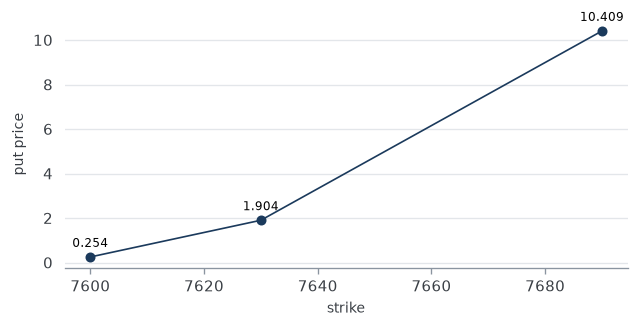


every put in the episode traded at a single price


In [75]:
spx = df[df.underlying == "SP500"]
big_exp = spx.groupby("expiry").notional.sum().sort_values().index[-1] if len(spx) else None
ep = spx[spx.expiry == big_exp].sort_values("ts")
if not len(ep):
    print("no SP500 trade on the tape, so there is no episode here to draw")
else:
    print(f"episode: {ep.ts.min()} .. {ep.ts.max()} ({names[ep.ts.min().weekday()]}), "
          f"{len(ep)} trades, {ep.taker.nunique()} takers, {ep.maker.nunique()} makers")
    view = ep[["ts","symbol","price","size","side","taker","notional"]].copy()
    view["ts"] = view.ts.dt.strftime("%m-%d %H:%M:%S"); view["taker"] = view.taker.str[:10]
    display(view.head(30).assign(price=view.price.map(float), size=view["size"].map(float),
                        notional=view.notional.map(float))
            .pipe(tbl, {"price":"{:.4f}","size":"{:,.4f}","notional":"${:,.0f}"}))
    puts = ep[ep.cp == "P"].drop_duplicates("strike", keep="last").sort_values("strike")
    fig, ax = plt.subplots(figsize=(5.4, 2.8))
    ax.plot(puts.strike.map(float), puts.price.map(float), "o-", color=INK, ms=5, lw=1)
    for r in puts.itertuples():
        ax.annotate(f"{float(r.price):.3f}", (float(r.strike), float(r.price)),
                    textcoords="offset points", xytext=(0, 6), fontsize=7, ha="center")
    ax.set_xlabel("strike"); ax.set_ylabel("put price")
    plt.tight_layout(); plt.savefig(CHARTS / "put-surface.png", dpi=170, bbox_inches="tight"); plt.show()
    dup = puts.groupby("symbol").price.agg(["nunique","min","max","size"])
    dup = dup[dup["nunique"] > 1]
    if len(dup):
        dup["spread"] = (dup["max"].map(float) - dup["min"].map(float)) / dup["max"].map(float) * 100
        print("\nthe same put at different prices inside the episode:")
        display(dup.pipe(tbl, {"min":"{:.4f}","max":"{:.4f}","spread":"{:.1f}%"}))
    else:
        print("\nevery put in the episode traded at a single price")

### The largest maker's own account

The address that makes most of this tape is credited with more than any other.
Three numbers describe it and they do not agree: what the venue says it is
worth, what its own HyperCore account holds, and what it ever received from
anyone. The first is a row in the venue's database; the other two are on chain.

In [76]:
own_perp = D(str((hl_post({"type": "clearinghouseState", "user": MAKER})
                  .get("marginSummary") or {}).get("accountValue") or 0))
own_spot = sum(D(str(bal.get("total") or 0))
               for bal in (hl_post(
                   {"type": "spotClearinghouseState", "user": MAKER}).get("balances") or [])
               if bal.get("coin") == "USDC")
m_in  = sum(m for _, _, m, _ in tr[MAKER]["in"])
m_out = sum(m for _, _, m, _ in tr[MAKER]["out"])
print(f"maker: {MAKER}")
print(f"  credited by the venue           ${float(eqv.get(MAKER, D(0))):>14,.2f}")
print(f"  paid into the custody wallet       ${float(DEP.get(MAKER, D(0))):>14,.2f}")
print(f"  received on HyperCore, to the cut     ${float(m_in):>14,.2f}"
      f"  from {len({u for _, u, _, _ in tr[MAKER]['in']})} addresses"
      f" over {tr[MAKER]['events']} ledger events")
print(f"  sent on HyperCore, to the cut         ${float(m_out):>14,.2f}")
print(f"  its own Core account: spot      ${float(own_spot):>14,.2f}")
print(f"                        perp      ${float(own_perp):>14,.2f}")
print(f"                        total     ${float(own_spot + own_perp):>14,.2f}")
ML = pd.DataFrame([{"when": when(w).strftime("%Y-%m-%d %H:%M"),
                    "from": u, "amount": float(m)}
                   for w, u, m, _ in tr[MAKER]["in"]])
display(ML.pipe(tbl, {"amount": "${:,.2f}"}))

maker: 0xe55b5e5e38f73c30aa367d310d6247f3f9a5e86e
  credited by the venue           $    586,302.63
  paid into the custody wallet       $    730,105.00
  received on HyperCore, to the cut     $    676,111.39  from 5 addresses over 30 ledger events
  sent on HyperCore, to the cut         $          0.00
  its own Core account: spot      $  1,121,253.46
                        perp      $     12,237.49
                        total     $  1,133,490.95


,when,from,amount
,2026-06-20 02:30,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,$10.00
,2026-06-20 02:49,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,$100.00
,2026-06-20 03:16,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,"$2,000.00"
,2026-06-20 03:37,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,"$20,000.00"
,2026-06-20 03:44,0x84649f8f224e23de956329bd5578c38e3a228ad9,$10.00
,2026-06-20 03:46,0x84649f8f224e23de956329bd5578c38e3a228ad9,"$49,696.04"
,2026-06-24 19:11,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,"$10,000.00"
,2026-06-24 19:32,0x6ef17a2bc5537dde7275d461c01a62a12cf81f75,"$70,000.00"
,2026-09-15 05:00,0xa1e2e61e0f9021e4e72a822e4ec0bf735afdebdf,$2.00
,2026-09-20 09:11,0xe430532a915b0132d37905dea50c9c823ad0eda2,$10.00


### Who holds the open interest

Who holds it. `long` is the address's total positive net position across the
instruments still open at the cut.

In [77]:
HOLD = pd.DataFrame([{"address": a[:12], "class": cls(a), "nonce": NONCE.get(a),
                      "long contracts": float(v), "share": float(v / oi_open)}
                     for a, v in holder.items()]).sort_values("long contracts", ascending=False)
display(HOLD.head(10).pipe(tbl, {"long contracts": "{:,.2f}", "share": "{:.2%}"}, index=False))
print(f"addresses holding any open long: {len(HOLD)} of {len(traders_all)}")
print(f"the top two hold {HOLD['share'].head(2).sum() * 100:.1f}% of all open long interest")
print(f"addresses outside the linked set hold "
      f"{HOLD[HOLD['class'] == 'outside']['share'].sum() * 100:.1f}% of it")

,address,class,nonce,long contracts,share
,0x0c6657303f,"the linked set, signed",13,772.08,38.03%
,0xe55b5e5e38,nonce 0,0,750.18,36.95%
,0x174ae5ba81,nonce 0,0,121.49,5.98%
,0x1d11779e66,nonce 0,0,106.64,5.25%
,0xc6396dd2f2,nonce 0,0,95.68,4.71%
,0xf98e462297,nonce 0,0,78.63,3.87%
,0x74ec5528a0,nonce 0,0,29.71,1.46%
,0x01f3867e55,nonce 0,0,20.99,1.03%
,0xbab89a16d4,outside,8,9.42,0.46%
,0x83b62613bc,nonce 0,0,9.13,0.45%


addresses holding any open long: 41 of 509
the top two hold 75.0% of all open long interest
addresses outside the linked set hold 0.8% of it
